# 1 - Caracterização da Amostra

In [1]:
import json
import csv
from collections import defaultdict

# Caminho dos arquivos
MODULOS_PATH = "relacao_assunto_questoes/estrutura_completa.json"
QUESTIONS_PATH = "questions_D_M.csv"
MISCONCEPTIONS_PATH = "misconceptions_detailed_por_usuario.csv"

def carregar_estrutura_completa():
    """Carrega o arquivo JSON com a estrutura completa das provas"""
    with open(MODULOS_PATH, 'r', encoding='utf-8') as f:
        return json.load(f)

def contar_questoes_totais(estrutura):
    """Conta o número total de questões únicas"""
    questoes = set()
    
    for disciplina, provas in estrutura.get('mapeamento_provas', {}).items():
        for prova_nome, prova_data in provas.items():
            for turma_id, turma_info in prova_data.items():
                if 'info' in turma_info and 'exercises' in turma_info['info']:
                    for exercicio, questoes_lista in turma_info['info']['exercises'].items():
                        questoes.update(questoes_lista)
    
    return len(questoes)

def contar_turmas(estrutura):
    """Conta o número de turmas considerando período e exclusões"""
    turmas = set()
    exclusoes = ['2020-ERE', '2020/1', '2020/2']
    
    for disciplina, provas in estrutura.get('mapeamento_provas', {}).items():
        for prova_nome, prova_data in provas.items():
            for turma_id, turma_info in prova_data.items():
                if 'info' in turma_info:
                    info = turma_info['info']
                    start_date = info.get('start', '')
                    
                    # Extrai ano e semestre da data
                    if start_date:
                        ano = int(start_date.split('-')[0])
                        mes = int(start_date.split('-')[1])
                        semestre = 1 if mes <= 6 else 2
                        periodo = f"{ano}/{semestre}"
                        
                        # Verifica se está no período válido (2016/1 a 2024/1)
                        if ano < 2016 or (ano == 2016 and semestre < 1):
                            continue
                        if ano > 2024 or (ano == 2024 and semestre > 1):
                            continue
                        
                        # Verifica exclusões
                        if periodo in exclusoes or '2020-ERE' in start_date:
                            continue
                        
                        turmas.add((info.get('class_number'), periodo))
    
    return len(turmas)

def contar_questoes_16_mais_respostas():
    """
    Conta questões com 16 ou mais respostas
    
    COMO FUNCIONA:
    - Lê o arquivo questions_D_M.csv que contém questões com 16+ respostas
    - Conta o número de linhas (cada linha = uma questão)
    - Retorna o total de questões
    """
    questoes_validas = 0
    
    try:
        with open(QUESTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            
            for linha in reader:
                questoes_validas += 1
        
        return questoes_validas
    except FileNotFoundError:
        print(f"Arquivo {QUESTIONS_PATH} não encontrado")
        return 0

def contar_estudantes():
    """Conta o número de estudantes únicos"""
    estudantes = set()
    
    try:
        with open(MISCONCEPTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            
            for linha in reader:
                if 'usuario' in linha and linha['usuario']:
                    estudantes.add(linha['usuario'])
        
        return len(estudantes)
    except FileNotFoundError:
        print(f"Arquivo {MISCONCEPTIONS_PATH} não encontrado")
        return 0

def contar_codigos_analisados():
    """
    Conta o número total de códigos analisados
    
    COMO FUNCIONA:
    - Lê o arquivo questions_D_M.csv
    - Para cada questão, pega a coluna 'respostas'
    - Essa coluna já contém o número de respostas para aquela questão
    - Soma todos os valores para obter o total de códigos individuais analisados
    
    EXEMPLO:
    respostas: 42
    -> 42 códigos analisados para essa questão
    """
    total_codigos = 0
    
    try:
        with open(QUESTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            
            for linha in reader:
                if 'respostas' in linha and linha['respostas']:
                    try:
                        num_respostas = int(linha['respostas'])
                        total_codigos += num_respostas
                    except ValueError:
                        # Ignora se não for um número válido
                        continue
        
        return total_codigos
    except FileNotFoundError:
        print(f"Arquivo {QUESTIONS_PATH} não encontrado")
        return 0

def main():
    print("=" * 70)
    print("LEVANTAMENTO DE INFORMAÇÕES")
    print("=" * 70)
    
    # Período
    print("\n PERÍODO DO LEVANTAMENTO:")
    print("   • Ano/Semestre Inicial: 2016/1")
    print("   • Ano/Semestre Final: 2024/1")
    print("   • Exclusões: 2020-ERE, 2020/1, 2020/2")
    
    # Carrega estrutura
    try:
        estrutura = carregar_estrutura_completa()
        
        # Número de turmas
        num_turmas = contar_turmas(estrutura)
        print(f"\n NÚMERO DE TURMAS: {num_turmas}")
        
        # Número de questões totais
        num_questoes_total = contar_questoes_totais(estrutura)
        print(f"\n NÚMERO DE QUESTÕES DE PROGRAMAÇÃO:")
        print(f"   • Total: {num_questoes_total}")
        
    except FileNotFoundError:
        print(f"\n Arquivo {MODULOS_PATH} não encontrado")
        num_turmas = 0
        num_questoes_total = 0
    
    # Questões com 16+ respostas
    num_questoes_16_mais = contar_questoes_16_mais_respostas()
    print(f"   • Respondidas por 16 ou mais estudantes: {num_questoes_16_mais}")
    
    # Número de estudantes
    num_estudantes = contar_estudantes()
    print(f"\n NÚMERO DE ESTUDANTES: {num_estudantes}")
    
    # Número de códigos analisados
    num_codigos = contar_codigos_analisados()
    print(f"\n NÚMERO DE CÓDIGOS ANALISADOS: {num_codigos}")
    
    print("\n" + "=" * 70)

if __name__ == "__main__":
    main()

LEVANTAMENTO DE INFORMAÇÕES

 PERÍODO DO LEVANTAMENTO:
   • Ano/Semestre Inicial: 2016/1
   • Ano/Semestre Final: 2024/1
   • Exclusões: 2020-ERE, 2020/1, 2020/2

 NÚMERO DE TURMAS: 172

 NÚMERO DE QUESTÕES DE PROGRAMAÇÃO:
   • Total: 1333
   • Respondidas por 16 ou mais estudantes: 829

 NÚMERO DE ESTUDANTES: 2836

 NÚMERO DE CÓDIGOS ANALISADOS: 32615



# 2 - Análise dos PC³

INICIANDO ANÁLISE DE PC³s
⚠️ PC³s vazios removidos da análise de correlação: B6, C4
ℹ️ Selecionando os Top 10 PC³s mais frequentes.

📊 Gerando gráfico de frequências de PC³s...


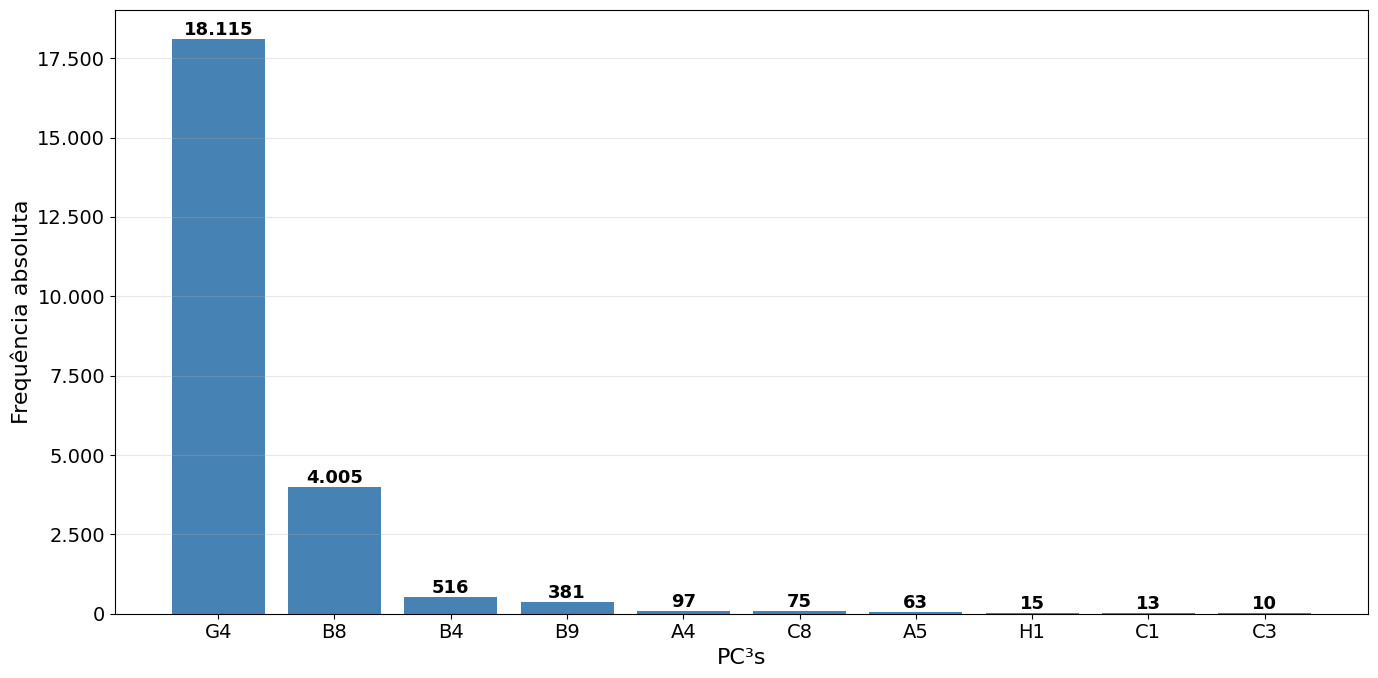


📊 Gerando gráfico de misconception por questão...
⚠️ Coluna 'misconception' não encontrada no dataset.

🔥 Gerando mapa de calor de correlações entre PC³s...


/tmp/ipykernel_1100/1145558579.py:196: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = corr_df.applymap(lambda x: formatar_decimal(x))


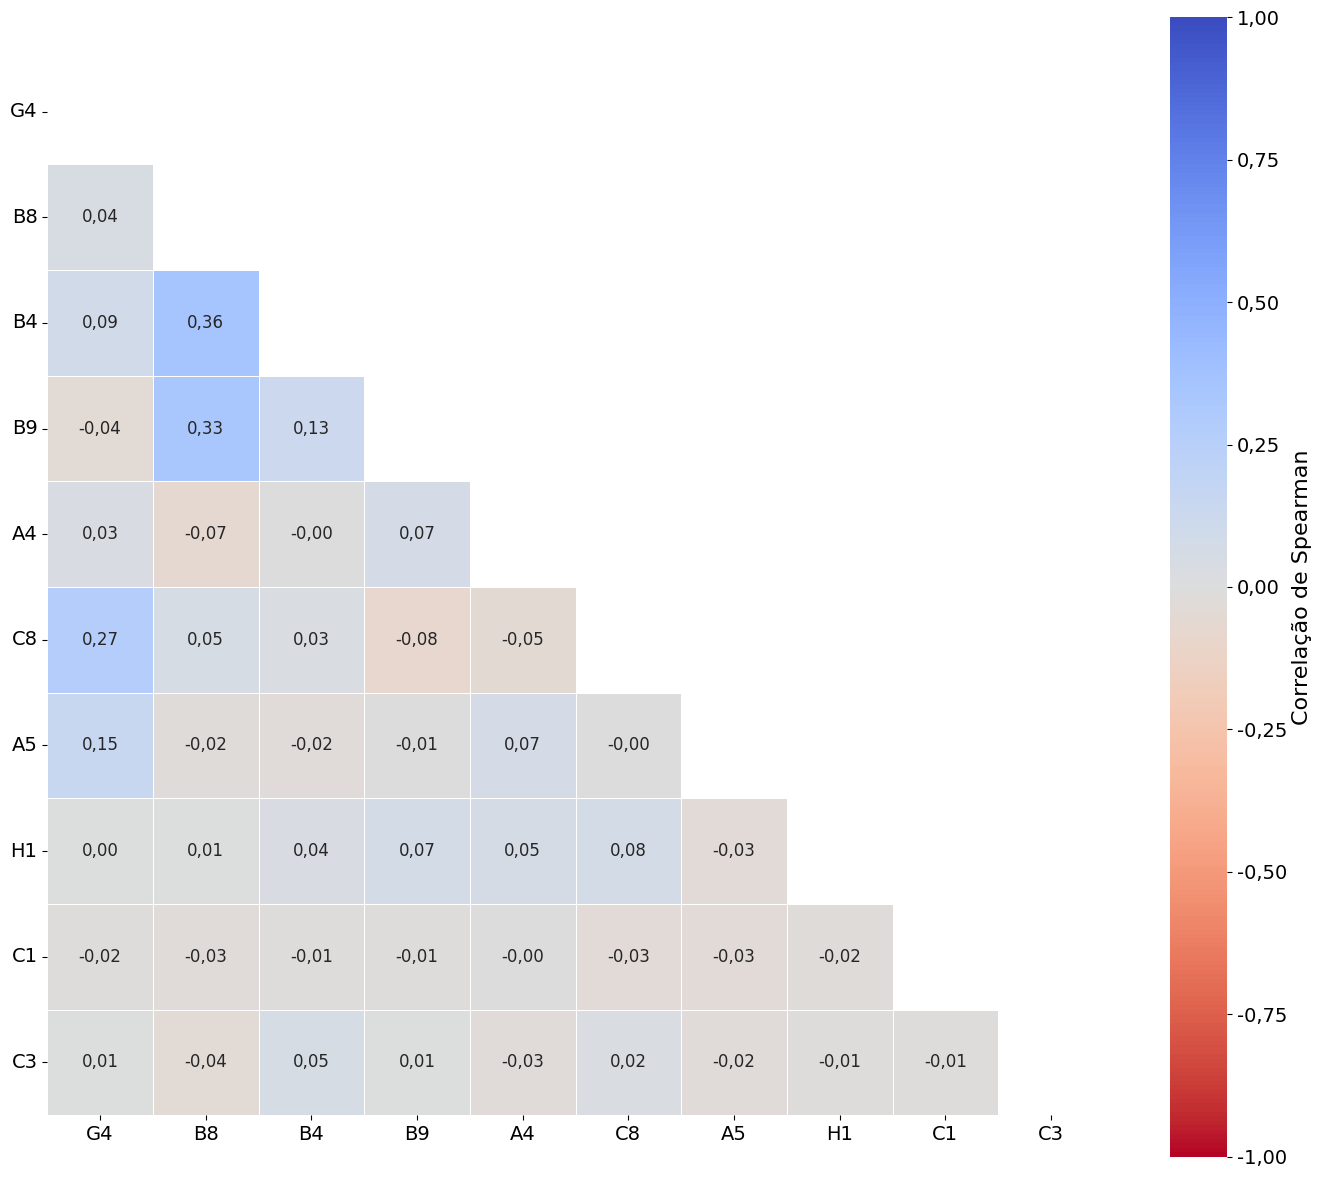


✓ Matriz de correlação gerada com sucesso!


,G4,B8,B4,B9,A4,C8,A5,H1,C1,C3
G4,1.000000,0.044565,0.086715,-0.040354,0.034619,0.266517,0.154210,0.003425,-0.015083,0.006401
B8,0.044565,1.000000,0.355863,0.330469,-0.067281,0.052704,-0.021080,0.005002,-0.028637,-0.041508
B4,0.086715,0.355863,1.000000,0.131298,-0.001936,0.031095,-0.023990,0.036724,-0.008387,0.052779
B9,-0.040354,0.330469,0.131298,1.000000,0.067580,-0.084650,-0.007020,0.074544,-0.009559,0.007797
A4,0.034619,-0.067281,-0.001936,0.067580,1.000000,-0.047682,0.065702,0.054934,-0.002272,-0.030653
C8,0.266517,0.052704,0.031095,-0.084650,-0.047682,1.000000,-0.003654,0.075379,-0.032970,0.023536
A5,0.154210,-0.021080,-0.023990,-0.007020,0.065702,-0.003654,1.000000,-0.034013,-0.031625,-0.024733
H1,0.003425,0.005002,0.036724,0.074544,0.054934,0.075379,-0.034013,1.000000,-0.017134,-0.013400
C1,-0.015083,-0.028637,-0.008387,-0.009559,-0.002272,-0.032970,-0.031625,-0.017134,1.000000,-0.012459
C3,0.006401,-0.041508,0.052779,0.007797,-0.030653,0.023536,-0.024733,-0.013400,-0.012459,1.000000


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import numpy as np
import locale

# Configurar locale para formatação brasileira
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except:
    pass

# --- CONFIGURAÇÕES GERAIS ---
QUESTIONS_PATH = "questions_D_M.csv"

# Configurações de fonte global
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Mapeamento de Colunas para Nomes Legíveis
PC3_MAP = {
    'A4': 'A4', 'A5': 'A5', 'B4': 'B4', 'B6': 'B6',
    'B8': 'B8', 'B9': 'B9', 'B12': 'B12', 'C1': 'C1',
    'C2': 'C2', 'C3': 'C3', 'C4': 'C4', 'C8': 'C8',
    'D4': 'D4', 'E2': 'E2', 'G4': 'G4', 'G5': 'G5',
    'H1': 'H1'
}

# Lista base (será filtrada dinamicamente)
PC3_COLUNAS_BASE = list(PC3_MAP.keys())

def formatar_numero(valor):
    """Formata número com separador de milhares (.) e decimais com vírgula"""
    if valor >= 1000:
        return f"{int(valor):,}".replace(',', '.')
    return str(int(valor))

def formatar_decimal(valor):
    """Formata decimal com vírgula"""
    return f"{valor:.2f}".replace('.', ',')

def carregar_dados():
    """Carrega os dados do CSV e trata colunas inexistentes"""
    try:
        df = pd.read_csv(QUESTIONS_PATH)
        # Garante que todas as colunas de interesse existam no DF (preenche com 0 se faltar)
        for col in PC3_COLUNAS_BASE:
            if col not in df.columns:
                df[col] = 0
        return df
    except FileNotFoundError:
        print(f"❌ Erro: Arquivo '{QUESTIONS_PATH}' não encontrado.")
        return None

def obter_colunas_ordenadas(df, top_n=None):
    """
    1. Calcula a frequência total.
    2. Remove colunas zeradas (ex: A4, H1).
    3. Ordena do mais frequente para o menos frequente.
    4. Retorna a lista de colunas cortada pelo top_n.
    """
    totais = {}
    
    # Calcula totais
    for col in PC3_COLUNAS_BASE:
        soma = df[col].sum()
        totais[col] = soma

    # Filtra quem tem 0 ocorrências (Remove A4 e H1 automaticamente se estiverem vazios)
    totais_ativos = {k: v for k, v in totais.items() if v > 0}
    
    # Identifica quem foi removido
    removidos = set(PC3_COLUNAS_BASE) - set(totais_ativos.keys())
    if removidos:
        nomes_removidos = [PC3_MAP[c] for c in removidos]
        print(f"⚠️ PC³s vazios removidos da análise de correlação: {', '.join(nomes_removidos)}")

    # Ordena dicionário por valor (decrescente)
    ordenados = sorted(totais_ativos.items(), key=lambda x: x[1], reverse=True)
    
    # Pega apenas as chaves (nomes das colunas)
    colunas_ordenadas = [item[0] for item in ordenados]
    
    # Aplica o corte top_n se solicitado
    if top_n and top_n < len(colunas_ordenadas):
        print(f"ℹ️ Selecionando os Top {top_n} PC³s mais frequentes.")
        colunas_ordenadas = colunas_ordenadas[:top_n]
    else:
        print(f"ℹ️ Analisando todos os {len(colunas_ordenadas)} PC³s com ocorrências.")
        
    return colunas_ordenadas, totais

def plotar_frequencia(totais, colunas_ordenadas):
    """Plota gráfico de barras seguindo a ordem definida"""
    
    nomes = [PC3_MAP[col] for col in colunas_ordenadas]
    valores = [totais[col] for col in colunas_ordenadas]
    
    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.bar(nomes, valores, color='steelblue')
    
    # Adiciona valores no topo com formatação brasileira
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                formatar_numero(height),
                ha='center', va='bottom', fontsize=13, fontweight='bold')
    
    ax.set_xlabel('PC³s', fontsize=16)
    ax.set_ylabel('Frequência absoluta', fontsize=16)
    #ax.set_title('PC³s mais frequentes', fontsize=18, fontweight='bold')
    plt.xticks(rotation=0, ha='center')  # Nomes retos e centralizados
    
    # Formata eixo Y com separador de milhares
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_numero(x)))
    
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plotar_misconception(df, colunas_ordenadas):
    """Plota gráfico de misconception por questão (em azul)"""
    
    # Verifica se a coluna 'misconception' existe
    if 'misconception' not in df.columns:
        print("⚠️ Coluna 'misconception' não encontrada no dataset.")
        return
    
    # Agrupa por questão e soma misconceptions
    if 'questao' in df.columns:
        misc_por_questao = df.groupby('questao')['misconception'].sum().sort_values(ascending=False)
    elif 'id' in df.columns:
        misc_por_questao = df.groupby('id')['misconception'].sum().sort_values(ascending=False)
    else:
        print("⚠️ Coluna 'questao' ou 'id' não encontrada.")
        return
    
    # Limita aos top 15 para melhor visualização
    top_questoes = misc_por_questao.head(15)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.bar(range(len(top_questoes)), top_questoes.values, color='steelblue')
    
    # Adiciona valores no topo
    for i, (bar, val) in enumerate(zip(bars, top_questoes.values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                formatar_numero(val),
                ha='center', va='bottom', fontsize=13, fontweight='bold')
    
    ax.set_xlabel('questão', fontsize=16)
    ax.set_ylabel('frequência de misconception', fontsize=16)
    ax.set_title('misconception por questão', fontsize=18, fontweight='bold')
    ax.set_xticks(range(len(top_questoes)))
    plt.xticks(range(len(top_questoes)), top_questoes.index, rotation=0, ha='center')
    
    # Formata eixo Y com separador de milhares
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_numero(x)))
    
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def calcular_e_plotar_correlacao(df, colunas_ordenadas):
    """
    Calcula correlação apenas para as colunas selecionadas e ordenadas.
    """
    # Filtra apenas questões relevantes (respostas >= 16, se coluna existir)
    if 'respostas' in df.columns:
        df_corr = df[df['respostas'] >= 16].copy()
    else:
        df_corr = df.copy()

    # Seleciona subconjunto de dados JÁ ORDENADO por frequência
    df_subset = df_corr[colunas_ordenadas]
    
    # Renomeia para nomes curtos (C1, B4...) para o gráfico ficar bonito
    df_subset.columns = [PC3_MAP[col] for col in colunas_ordenadas]
    
    # Calcula Spearman
    corr_df = df_subset.corr(method='spearman')
    
    # Plotagem com fonte maior
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Máscara para triângulo superior
    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    
    # Cria anotações formatadas com vírgula
    annot_data = corr_df.applymap(lambda x: formatar_decimal(x))
    
    # MUDANÇA: inverte o colormap - agora azul é positivo e vermelho é negativo
    heatmap = sns.heatmap(
        corr_df,
        mask=mask,
        annot=annot_data,
        fmt='',
        cmap='coolwarm_r',  # INVERTIDO: adiciona _r para reverter as cores
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlação de Spearman'},
        ax=ax,
        annot_kws={'fontsize': 12}
    )
    
    # Formata a barra de cores com vírgula nos decimais
    from matplotlib.ticker import FuncFormatter
    colorbar = heatmap.collections[0].colorbar
    colorbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_decimal(x)))
    
    #ax.set_title('matriz de correlação de PC³s (ordenada por frequência)',              fontsize=18, fontweight='bold', pad=20)
    
    # Ajusta labels para ficarem retos e centralizados
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0, va='center')
    
    plt.tight_layout()
    plt.show()
    
    return corr_df

def gerar_relatorio(top_n=None):
    """
    Função Principal de Controle.
    
    Parâmetros:
      top_n (int ou None): Número de PC³s a analisar. 
                           Ex: 10 para os top 10, None para todos.
    """
    print("=" * 60)
    print("INICIANDO ANÁLISE DE PC³s")
    print("=" * 60)
    
    df = carregar_dados()
    if df is None: return

    # 1. Processamento e Ordenação
    colunas_finais, totais_brutos = obter_colunas_ordenadas(df, top_n=top_n)
    
    if not colunas_finais:
        print("Nenhum dado encontrado para gerar relatórios.")
        return

    # 2. Plotar Frequências de PC³s (Barras)
    print("\n📊 Gerando gráfico de frequências de PC³s...")
    plotar_frequencia(totais_brutos, colunas_finais)
    
    # 3. Plotar Misconception por Questão (Barras Azuis)
    print("\n📊 Gerando gráfico de misconception por questão...")
    plotar_misconception(df, colunas_finais)
    
    # 4. Correlação (Heatmap)
    print("\n🔥 Gerando mapa de calor de correlações entre PC³s...")
    corr_df = calcular_e_plotar_correlacao(df, colunas_finais)
    
    # 5. Exibir informação
    print("\n✓ Matriz de correlação gerada com sucesso!")
    print("=" * 60)
    
    return corr_df


# VERSÃO NOTEBOOK - Chama a função diretamente
gerar_relatorio(top_n=10)  # top_n para a quantidade de PC³s a analisar

# 3 - Análise das métricas de dificuldade

ANÁLISE DAS MÉTRICAS DE DIFICULDADE

1. Carregando dados...
   Total de questões no arquivo: 829

2. Métricas de dificuldade identificadas: 13
   MD1: taxa_acerto → taxa de acerto
   MD2: num_submissoes → submissões
   MD3: taxa_aceitacao → taxa de aceitação
   MD4: num_testes → testes
   MD5: num_consultas → consultas
   MD6: num_erros_lgcs → erros lógicos
   MD7: num_errors_stx → erros sintaxe
   MD8: num_erros → erros totais
   MD9: num_eventos → eventos totais
   MD10: num_eventos_del → eventos deleção
   MD11: tempo_implementacao → tempo implementação
   MD12: qtd_alteracoes_codigo → alterações código
   MD13: discriminacao → discriminação

3. Filtrando questões com 16 ou mais respostas...
   Questões com 16+ respostas: 597
   Questões excluídas: 232

4. Calculando estatísticas descritivas...

TABELA: Medidas de tendência central e dispersão das métricas de dificuldade
Questões com 16 ou mais respostas
            Métrica   n Média Desvio-padrão    Min Mediana   Max
     taxa de a

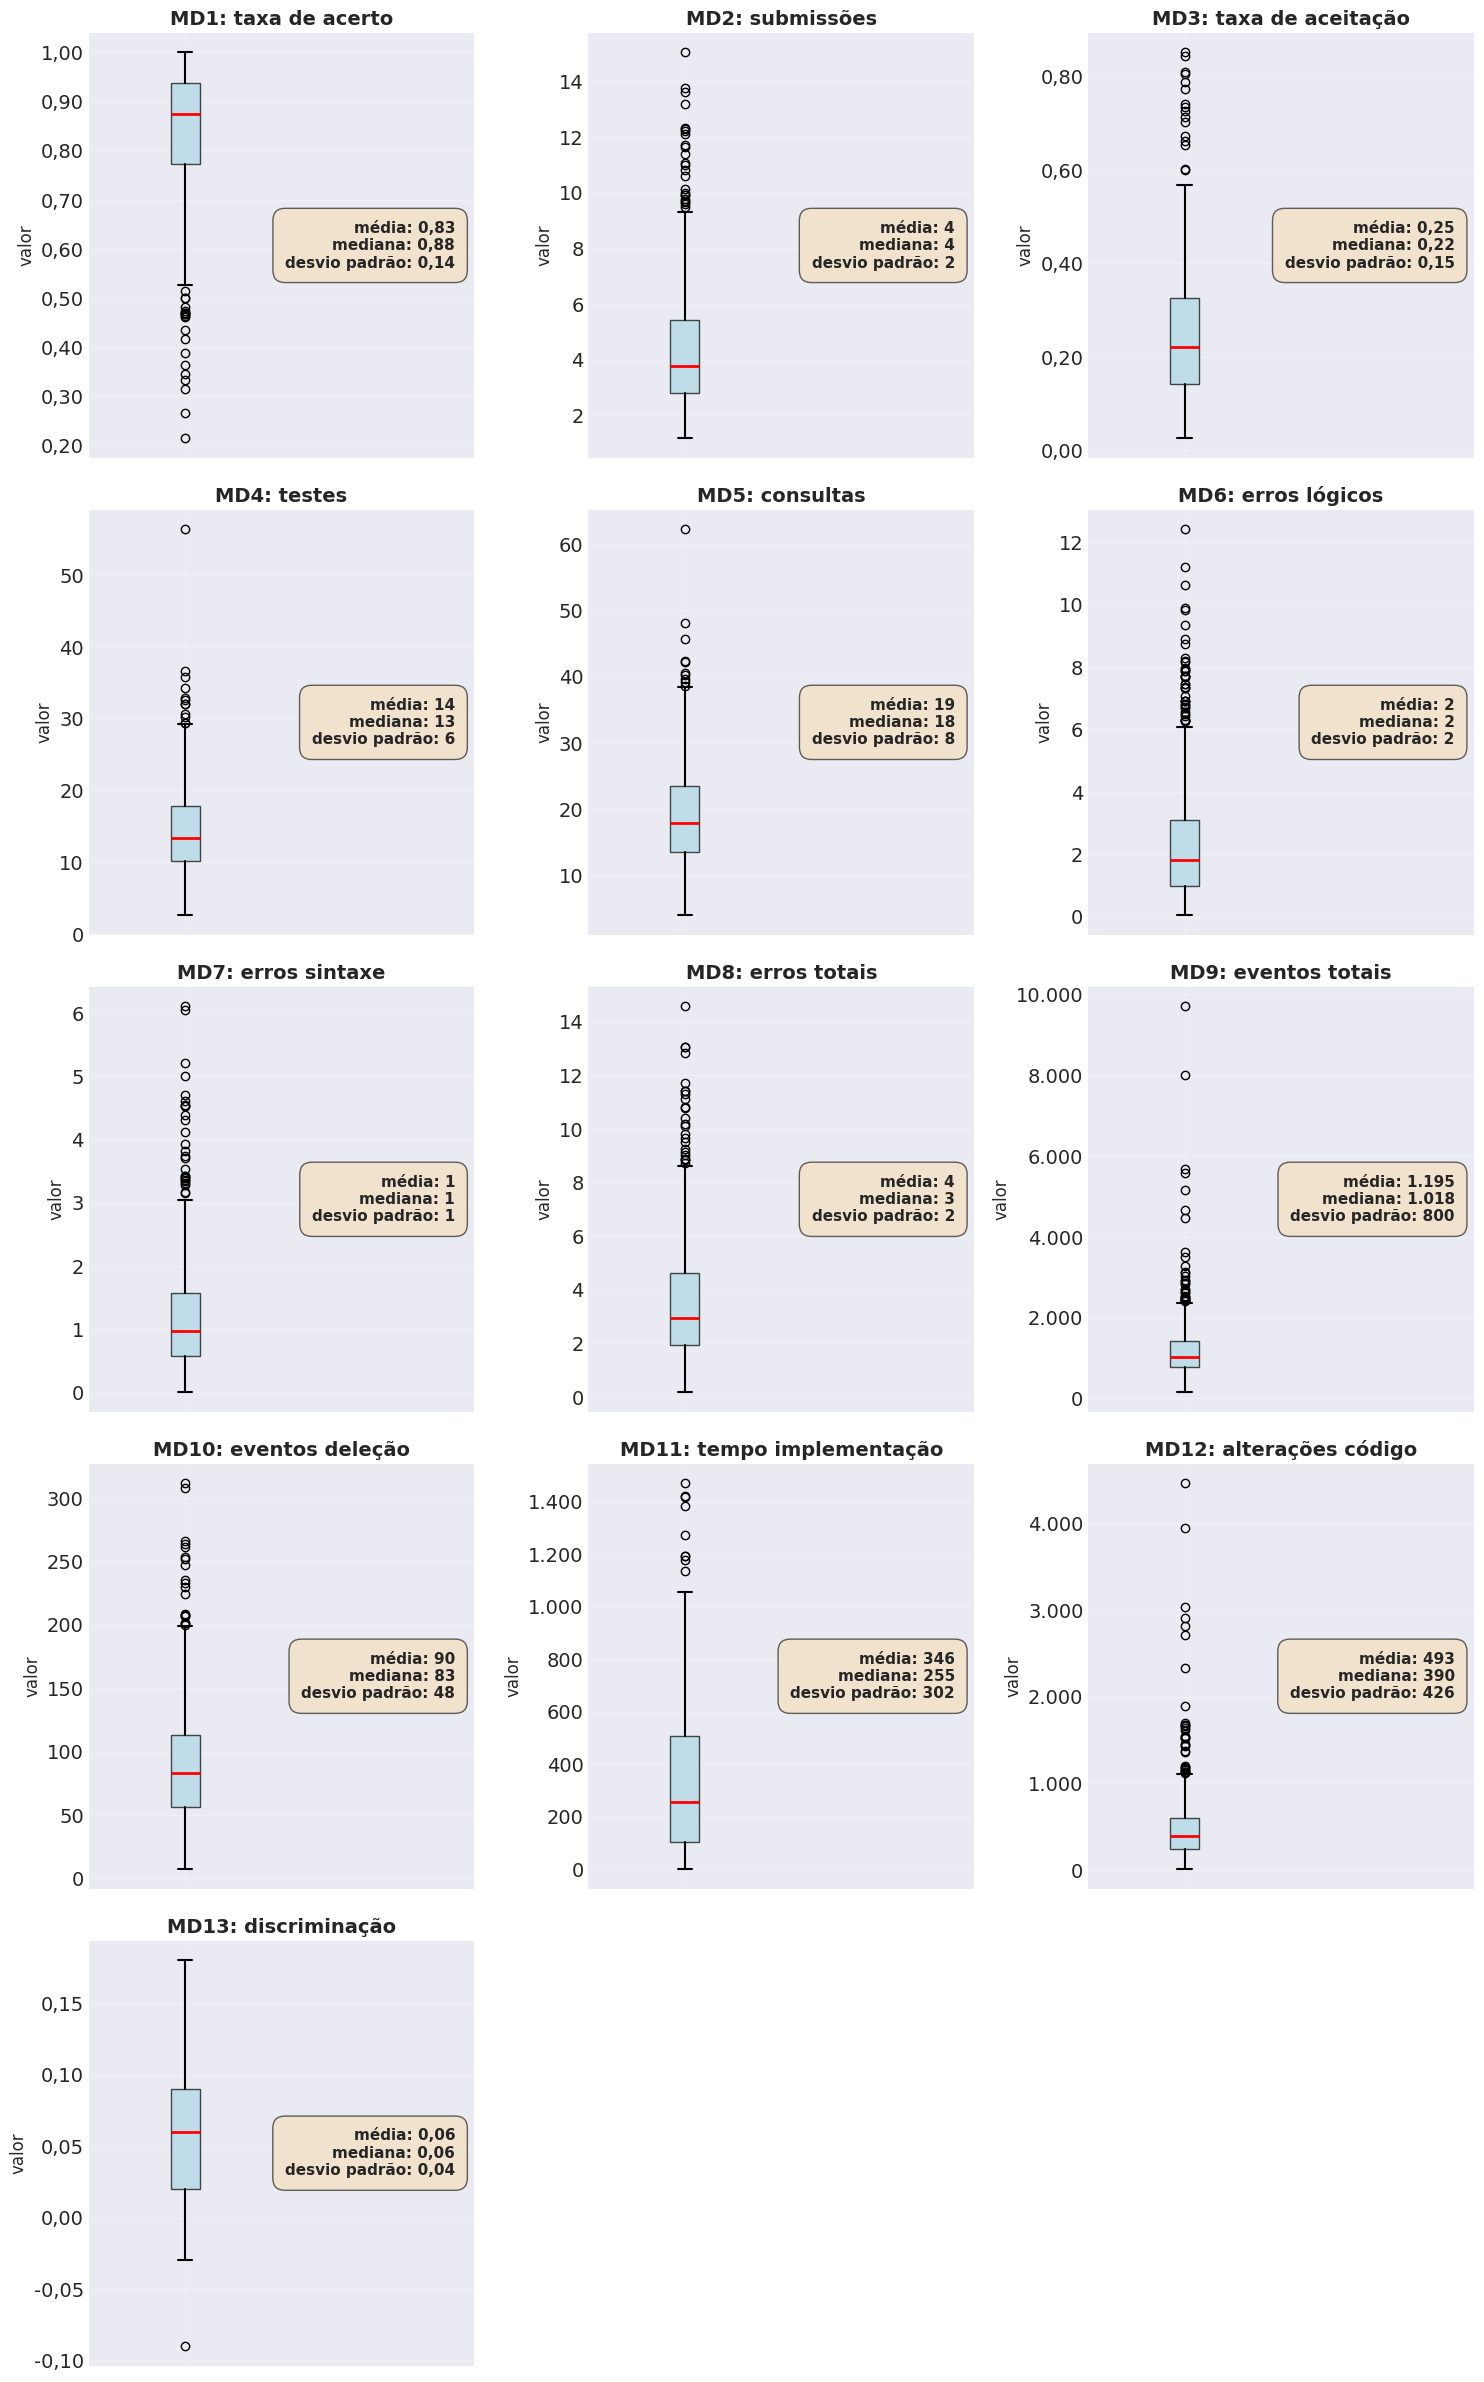

✓ Boxplots com dados originais exibidos

5b. Gerando boxplots com z-score (dados normalizados, mesma escala)...
   Escala global do eixo Y: [-5,26, 11,39]


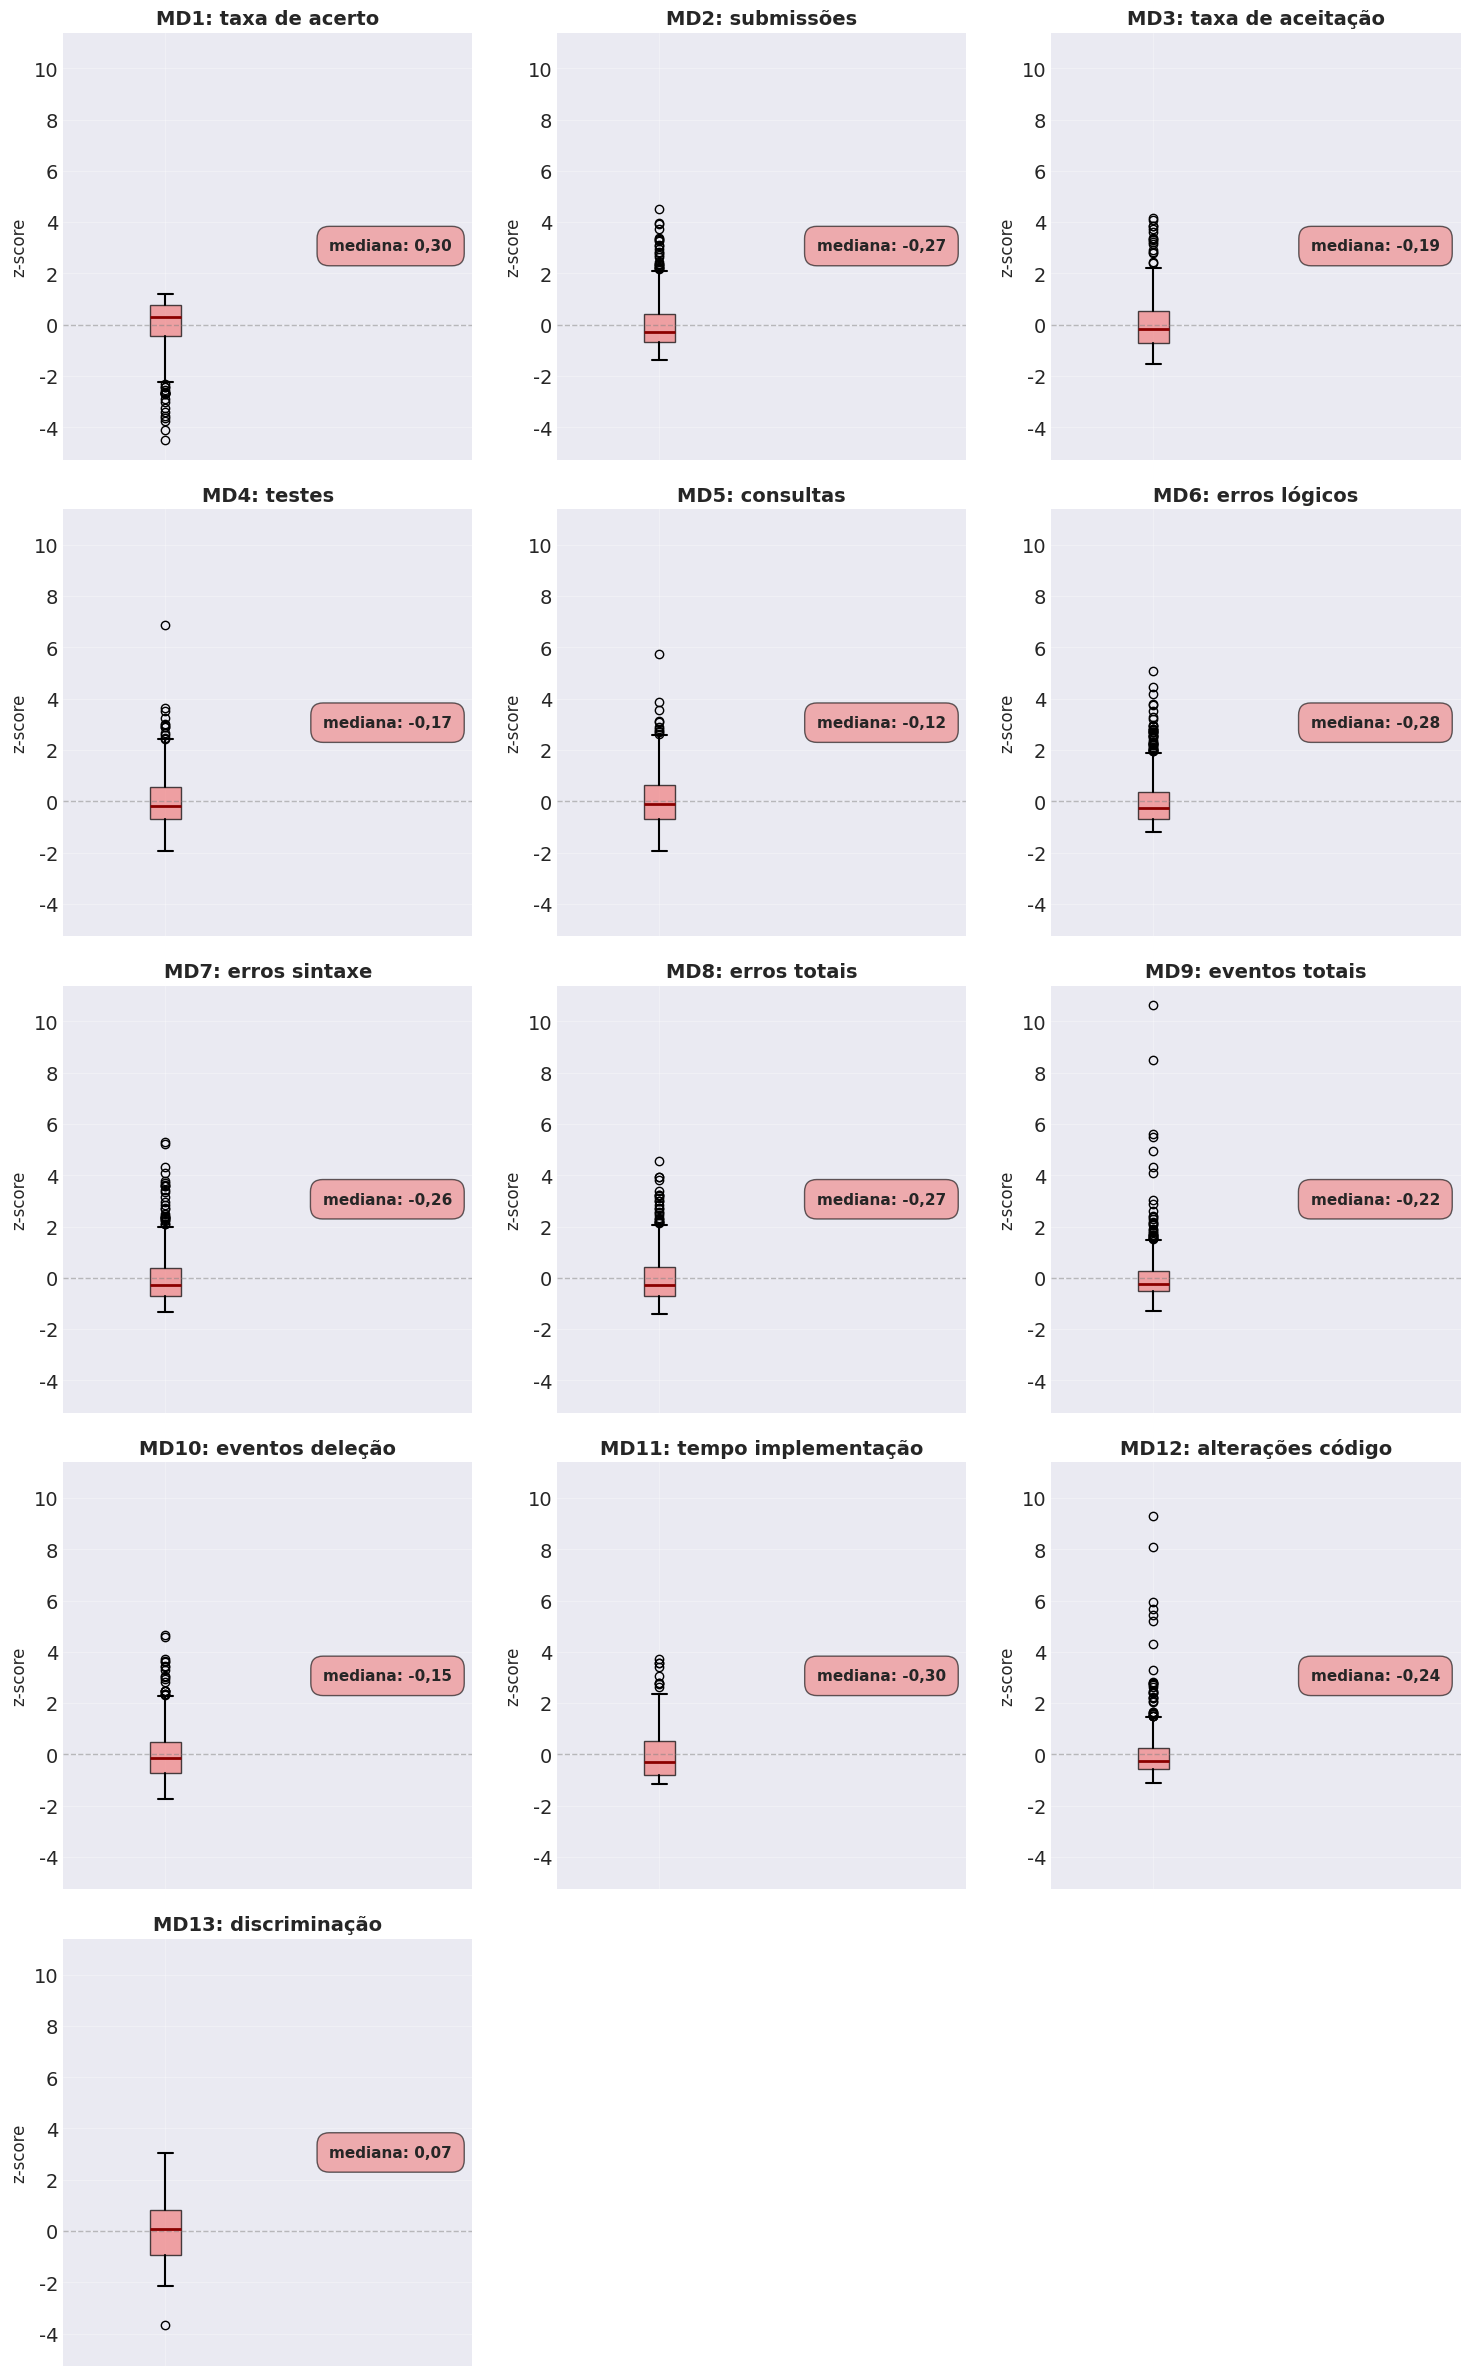

✓ Boxplots com z-score exibidos (escala unificada)

6. Calculando correlação de Spearman entre métricas...

MATRIZ DE CORRELAÇÃO DE SPEARMAN (forma de escada - TEXTO)

Métrica                    taxa de acer    submissões  taxa de acei        testes     consultas  erros lógico  erros sintax  erros totais  eventos tota  eventos dele  tempo implem  alterações c  discriminaçã
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
taxa de acerto                     1,00                                                                                                                                                                        
submissões                        -0,54          1,00                                                                                                                                                          


/tmp/ipykernel_1100/507627524.py:316: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = corr_df.applymap(lambda x: formatar_decimal(x, 2))


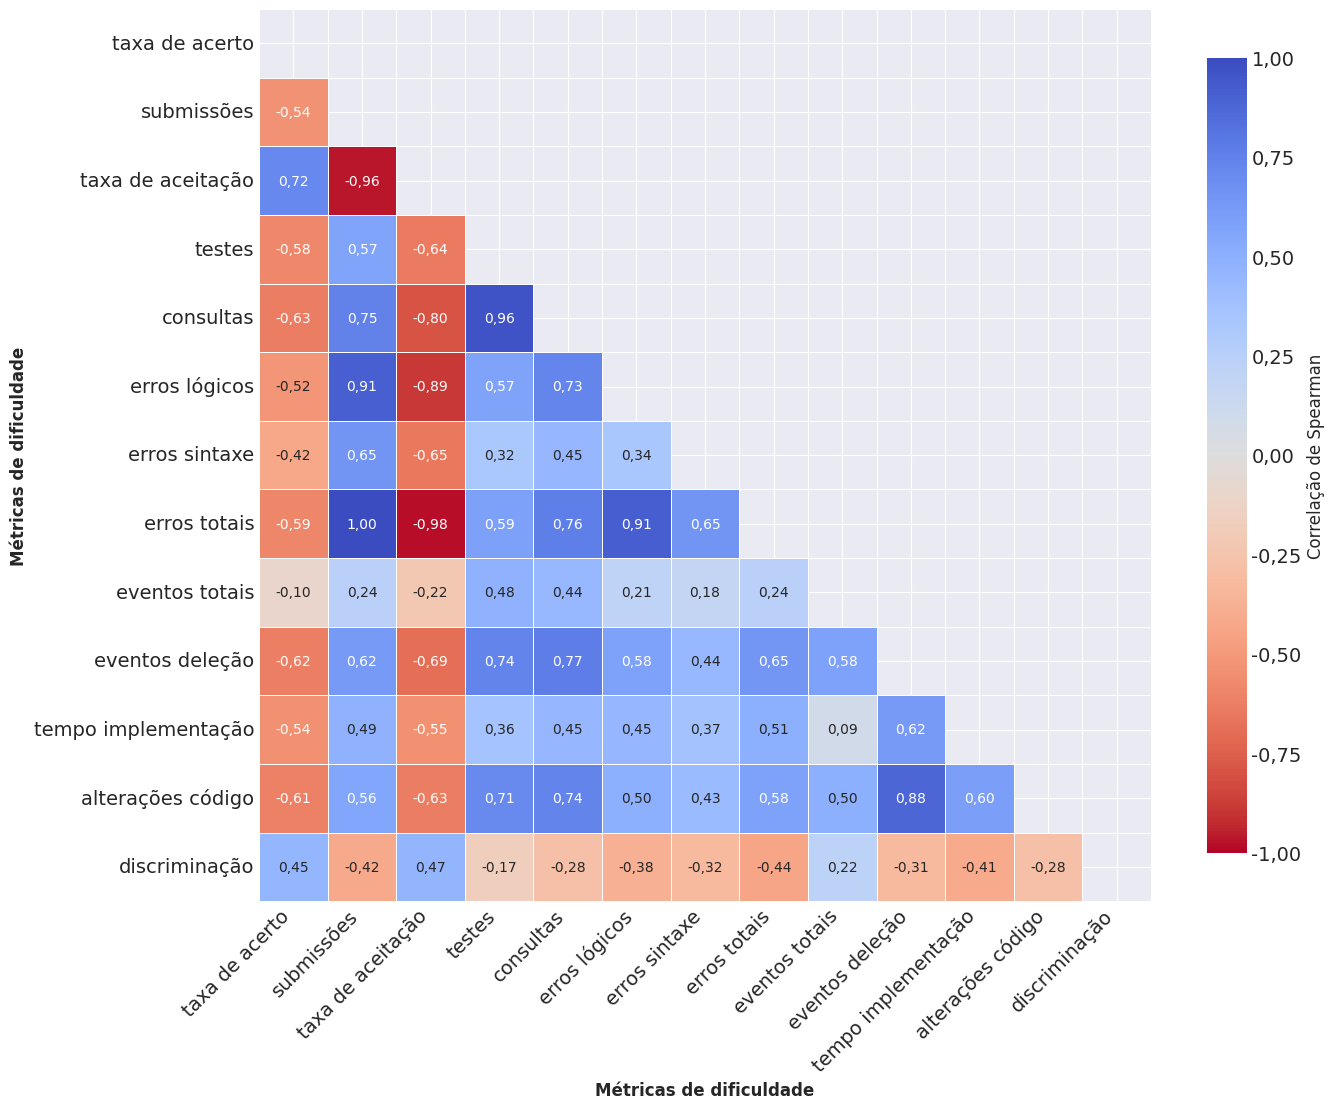

✓ Heatmap exibido

8. Análise de correlações fortes...

PARES DE MÉTRICAS COM CORRELAÇÃO FORTE (|ρ| > 0,7)
        Métrica 1         Métrica 2     ρ
taxa de aceitação    taxa de acerto  0,72
taxa de aceitação        submissões -0,96
        consultas        submissões  0,75
        consultas taxa de aceitação -0,80
        consultas            testes  0,96
    erros lógicos        submissões  0,91
    erros lógicos taxa de aceitação -0,89
    erros lógicos         consultas  0,73
     erros totais        submissões  1,00
     erros totais taxa de aceitação -0,98
     erros totais         consultas  0,76
     erros totais     erros lógicos  0,91
  eventos deleção            testes  0,74
  eventos deleção         consultas  0,77
alterações código            testes  0,71
alterações código         consultas  0,74
alterações código   eventos deleção  0,88

PARES DE MÉTRICAS COM CORRELAÇÃO MODERADA (0,5 < |ρ| ≤ 0,7)
          Métrica 1           Métrica 2     ρ
         submissões      taxa 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configurações
QUESTIONS_PATH = "questions_D_M.csv"

# Configurações de fonte global
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Mapeamento de Colunas para Nomes Legíveis
PC3_MAP = {
    'A4': 'A4', 'A5': 'A5', 'B4': 'B4', 'B6': 'B6',
    'B8': 'B8', 'B9': 'B9', 'B12': 'B12', 'C1': 'C1',
    'C2': 'C2', 'C3': 'C3', 'C4': 'C4', 'C8': 'C8',
    'D4': 'D4', 'E2': 'E2', 'G4': 'G4', 'G5': 'G5',
    'H1': 'H1'
}

# ============================================================================
# MAPEAMENTO DAS MÉTRICAS DE DIFICULDADE
# Colunas reais do CSV → nomes legíveis
# 'dificuldade' é ignorada conforme instrução
# ============================================================================
# M1:  taxa_acerto           = num_correct / num_students_interactions
# M2:  num_submissoes        = num_submissions / num_students_interactions
# M3:  taxa_aceitacao        = num_correct / num_submissions
# M4:  num_testes            = num_tests / num_students_interactions
# M5:  num_consultas         = (num_submissions + num_tests) / num_students_interactions
# M6:  num_erros_lgcs        = num_logic_errors / num_students_interactions
# M7:  num_errors_stx        = num_syntax_errors / num_students_interactions
# M8:  num_erros             = num_errors / num_students_interactions
# M9:  num_eventos           = num_events / num_students_interactions
# M10: num_eventos_del       = num_deletes / num_students_interactions
# M11: tempo_implementacao   = code_time / num_correct
# M12: qtd_alteracoes_codigo = amount_of_change / num_students_interactions
# M13: discriminacao         (fórmula própria - já calculada)

traducao_metricas = {
    'taxa_acerto':           'taxa de acerto',       # M1
    'num_submissoes':        'submissões',            # M2
    'taxa_aceitacao':        'taxa de aceitação',     # M3
    'num_testes':            'testes',                # M4
    'num_consultas':         'consultas',             # M5
    'num_erros_lgcs':        'erros lógicos',         # M6
    'num_errors_stx':        'erros sintaxe',         # M7
    'num_erros':             'erros totais',          # M8
    'num_eventos':           'eventos totais',        # M9
    'num_eventos_del':       'eventos deleção',       # M10
    'tempo_implementacao':   'tempo implementação',   # M11
    'qtd_alteracoes_codigo': 'alterações código',     # M12
    'discriminacao':         'discriminação',         # M13
    # 'dificuldade' IGNORADA intencionalmente
}

# Métricas onde valores menores = questão mais difícil (positivas invertidas)
# Usadas apenas para referência semântica
METRICAS_POSITIVAS = {'taxa_acerto', 'taxa_aceitacao', 'discriminacao'}

# Métricas com casas decimais (as demais são exibidas como inteiros)
METRICAS_DECIMAIS = {'taxa_acerto', 'taxa_aceitacao', 'discriminacao'}

def formatar_numero(valor):
    """Formata número com separador de milhares (.) e sem decimais"""
    if pd.isna(valor):
        return 'N/A'
    try:
        v = float(valor)
        if v >= 1000 or v <= -1000:
            return f"{int(round(v)):,}".replace(',', '.')
        return str(int(round(v)))
    except:
        return 'N/A'

def formatar_decimal(valor, casas=3):
    """Formata decimal com vírgula como separador"""
    if pd.isna(valor):
        return 'N/A'
    try:
        formato = f"{{:.{casas}f}}"
        return formato.format(float(valor)).replace('.', ',')
    except:
        return 'N/A'

def formatar_metrica(valor, nome_coluna, casas=2):
    """Formata valor de acordo com o tipo da métrica"""
    if pd.isna(valor):
        return 'N/A'
    if nome_coluna in METRICAS_DECIMAIS:
        return formatar_decimal(valor, casas)
    else:
        return formatar_numero(valor)

# Configuração de estilo para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("ANÁLISE DAS MÉTRICAS DE DIFICULDADE")
print("=" * 80)

# 1. CARREGAR DADOS
print("\n1. Carregando dados...")
df = pd.read_csv(QUESTIONS_PATH)
print(f"   Total de questões no arquivo: {formatar_numero(len(df))}")

# 2. IDENTIFICAR MÉTRICAS DE DIFICULDADE DISPONÍVEIS NO CSV
# Apenas as colunas que existem no arquivo E estão no dicionário de tradução
difficulty_metrics = [col for col in traducao_metricas.keys() if col in df.columns]

print(f"\n2. Métricas de dificuldade identificadas: {len(difficulty_metrics)}")
for i, metric in enumerate(difficulty_metrics, 1):
    print(f"   MD{i}: {metric} → {traducao_metricas[metric]}")

# 3. FILTRAR QUESTÕES COM 16+ RESPOSTAS
print("\n3. Filtrando questões com 16 ou mais respostas...")
pc3_columns = [col for col in list(PC3_MAP.keys()) if col in df.columns]
df['total_responses'] = df[pc3_columns].sum(axis=1)
df_filtered = df[df['total_responses'] >= 16].copy()
print(f"   Questões com 16+ respostas: {formatar_numero(len(df_filtered))}")
print(f"   Questões excluídas: {formatar_numero(len(df) - len(df_filtered))}")

# Converter métricas para numérico
for metric in difficulty_metrics:
    df_filtered[metric] = pd.to_numeric(df_filtered[metric], errors='coerce')

# 4. CALCULAR ESTATÍSTICAS DESCRITIVAS
print("\n4. Calculando estatísticas descritivas...")
print("\n" + "=" * 80)
print("TABELA: Medidas de tendência central e dispersão das métricas de dificuldade")
print("Questões com 16 ou mais respostas")
print("=" * 80)

stats_list = []
valid_metrics = []

for metric in difficulty_metrics:
    values = df_filtered[metric].dropna()
    if len(values) > 0:
        stats = {
            'Métrica': traducao_metricas.get(metric, metric),
            'n': formatar_numero(len(values)),
            'Média': formatar_metrica(values.mean(), metric, casas=3),
            'Desvio-padrão': formatar_metrica(values.std(), metric, casas=3),
            'Min': formatar_metrica(values.min(), metric, casas=3),
            'Mediana': formatar_metrica(values.median(), metric, casas=3),
            'Max': formatar_metrica(values.max(), metric, casas=3),
        }
        stats_list.append(stats)
        valid_metrics.append(metric)
    else:
        print(f"   ⚠️  Métrica '{metric}' sem valores válidos. Ignorando.")

stats_df = pd.DataFrame(stats_list)
print(stats_df.to_string(index=False))

difficulty_metrics = valid_metrics

# 5. PLOTAR BOXPLOTS - DADOS ORIGINAIS
print("\n5. Gerando boxplots com dados originais...")

n_metrics = len(difficulty_metrics)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.8 * n_rows))
plt.subplots_adjust(top=0.92, hspace=0.6, bottom=0.08)

if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

for idx, metric in enumerate(difficulty_metrics):
    ax = axes_flat[idx]
    data = df_filtered[metric].dropna()

    bp = ax.boxplot([data], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))

    ax.set_xlim(0.5, 2.5)
    ax.set_title(f'MD{idx+1}: {traducao_metricas.get(metric, metric)}', fontweight='bold')
    ax.set_ylabel('valor')
    ax.set_xticklabels([''])
    ax.grid(True, alpha=0.3)

    # Formatar eixo Y de acordo com o tipo da métrica
    if metric in METRICAS_DECIMAIS:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_decimal(x, 2)))
    else:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_numero(x)))

    # Texto com estatísticas
    media_fmt   = formatar_metrica(data.mean(),   metric, casas=2)
    mediana_fmt = formatar_metrica(data.median(), metric, casas=2)
    std_fmt     = formatar_metrica(data.std(),    metric, casas=2)
    stats_text = f'média: {media_fmt}\nmediana: {mediana_fmt}\ndesvio padrão: {std_fmt}'

    ax.text(0.95, 0.5, stats_text, transform=ax.transAxes,
            verticalalignment='center', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='wheat', alpha=0.6),
            fontsize=11, fontweight='bold')

for idx in range(n_metrics, len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()
print("✓ Boxplots com dados originais exibidos")

# 5b. PLOTAR BOXPLOTS - Z-SCORE (MESMA ESCALA NO EIXO Y)
print("\n5b. Gerando boxplots com z-score (dados normalizados, mesma escala)...")

# Calcular todos os z-scores primeiro para determinar escala global
all_zscores = []
zscores_por_metrica = {}
for metric in difficulty_metrics:
    data = df_filtered[metric].dropna()
    std = data.std()
    z = (data - data.mean()) / std if std != 0 else data * 0
    zscores_por_metrica[metric] = z
    all_zscores.append(z)

# Determinar min e max globais com margem de 5%
z_global_min = min(z.min() for z in all_zscores)
z_global_max = max(z.max() for z in all_zscores)
margem = (z_global_max - z_global_min) * 0.05
y_min = z_global_min - margem
y_max = z_global_max + margem

print(f"   Escala global do eixo Y: [{formatar_decimal(y_min, 2)}, {formatar_decimal(y_max, 2)}]")

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(15, 4.8 * n_rows))
plt.subplots_adjust(top=0.92, hspace=0.6, bottom=0.08)

if n_rows == 1:
    axes2 = axes2.reshape(1, -1)
axes2_flat = axes2.flatten()

def format_zscore(x, p):
    return str(int(x)) if x == int(x) else formatar_decimal(x, 1)

for idx, metric in enumerate(difficulty_metrics):
    ax = axes2_flat[idx]
    z_score = zscores_por_metrica[metric]

    bp = ax.boxplot([z_score], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                    medianprops=dict(color='darkred', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))

    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(y_min, y_max)   # ← mesma escala em todos os subplots
    ax.set_title(f'MD{idx+1}: {traducao_metricas.get(metric, metric)}', fontweight='bold')
    ax.set_ylabel('z-score')
    ax.set_xticklabels([''])
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FuncFormatter(format_zscore))
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    stats_text = f'mediana: {formatar_decimal(z_score.median(), 2)}'
    ax.text(0.95, 0.5, stats_text, transform=ax.transAxes,
            verticalalignment='center', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='lightcoral', alpha=0.6),
            fontsize=11, fontweight='bold')

for idx in range(n_metrics, len(axes2_flat)):
    fig2.delaxes(axes2_flat[idx])

plt.tight_layout()
plt.show()
print("✓ Boxplots com z-score exibidos (escala unificada)")

# 6. CORRELAÇÃO DE SPEARMAN
print("\n6. Calculando correlação de Spearman entre métricas...")

df_metrics = df_filtered[difficulty_metrics].copy()
corr_df = df_metrics.corr(method='spearman')
corr_matrix = corr_df.values
n_metrics = len(difficulty_metrics)
translated_metrics = [traducao_metricas.get(m, m) for m in difficulty_metrics]

# 7. MATRIZ EM ESCADA (TEXTO)
print("\n" + "=" * 80)
print("MATRIZ DE CORRELAÇÃO DE SPEARMAN (forma de escada - TEXTO)")
print("=" * 80)
print()

header = f"{'Métrica':<25}"
for metric in translated_metrics:
    header += f"{metric[:12]:>14}"
print(header)
print("-" * (25 + 14 * n_metrics))

for i, metric_i in enumerate(translated_metrics):
    line = f"{metric_i:<25}"
    for j in range(n_metrics):
        if j <= i:
            val = corr_matrix[i, j]
            line += f"{formatar_decimal(val, 2) if not np.isnan(val) else 'N/A':>14}"
        else:
            line += f"{'':>14}"
    print(line)

# 8. HEATMAP TRIANGULAR
print("\n7. Gerando heatmap da matriz de correlação...")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
annot_data = corr_df.applymap(lambda x: formatar_decimal(x, 2))

fig, ax = plt.subplots(figsize=(14, 12))
heatmap = sns.heatmap(corr_df,
            mask=mask,
            annot=annot_data,
            fmt='',
            cmap='coolwarm_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlação de Spearman"},
            xticklabels=translated_metrics,
            yticklabels=translated_metrics,
            vmin=-1, vmax=1,
            ax=ax,
            annot_kws={'fontsize': 10})

colorbar = heatmap.collections[0].colorbar
colorbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_decimal(x, 2)))

ax.set_xlabel('Métricas de dificuldade', fontsize=12, fontweight='bold')
ax.set_ylabel('Métricas de dificuldade', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("✓ Heatmap exibido")

# 9. CORRELAÇÕES FORTES
print("\n8. Análise de correlações fortes...")
print("\n" + "=" * 80)
print("PARES DE MÉTRICAS COM CORRELAÇÃO FORTE (|ρ| > 0,7)")
print("=" * 80)

strong_corr = []
for i in range(n_metrics):
    for j in range(i):
        val = corr_matrix[i, j]
        if not np.isnan(val) and abs(val) > 0.7:
            strong_corr.append({
                'Métrica 1': traducao_metricas.get(difficulty_metrics[i], difficulty_metrics[i]),
                'Métrica 2': traducao_metricas.get(difficulty_metrics[j], difficulty_metrics[j]),
                'ρ': formatar_decimal(val, 2),
            })

if strong_corr:
    print(pd.DataFrame(strong_corr).to_string(index=False))
else:
    print("Nenhuma correlação forte encontrada (|ρ| > 0,7)")

# 10. CORRELAÇÕES MODERADAS
print("\n" + "=" * 80)
print("PARES DE MÉTRICAS COM CORRELAÇÃO MODERADA (0,5 < |ρ| ≤ 0,7)")
print("=" * 80)

moderate_corr = []
for i in range(n_metrics):
    for j in range(i):
        val = corr_matrix[i, j]
        if not np.isnan(val) and 0.5 < abs(val) <= 0.7:
            moderate_corr.append({
                'Métrica 1': traducao_metricas.get(difficulty_metrics[i], difficulty_metrics[i]),
                'Métrica 2': traducao_metricas.get(difficulty_metrics[j], difficulty_metrics[j]),
                'ρ': formatar_decimal(val, 2),
            })

if moderate_corr:
    print(pd.DataFrame(moderate_corr).to_string(index=False))
else:
    print("Nenhuma correlação moderada encontrada")

# 11. RESUMO FINAL
print("\n" + "=" * 80)
print("RESUMO DA ANÁLISE")
print("=" * 80)
print(f"✓ Total de questões analisadas: {formatar_numero(len(df_filtered))}")
print(f"✓ Número de métricas de dificuldade válidas: {len(difficulty_metrics)}")
print(f"✓ Métricas analisadas:")
for i, metric in enumerate(difficulty_metrics, 1):
    print(f"   MD{i}: {metric} → {traducao_metricas[metric]}")
print(f"\n⚠️  Métrica 'dificuldade' ignorada conforme configuração.")
print("\n" + "=" * 80)
print("ANÁLISE CONCLUÍDA COM SUCESSO!")
print("=" * 80)

# 4 - Correlação entre PC³ e métricas de dificuldade



💡 USO: analisar_correlacao_pc3_metricas(top_n=10)
   - top_n=10   : Analisa os 10 PC³ mais frequentes (padrão)
   - top_n=None : Analisa todos os PC³ ativos


ANÁLISE DE CORRELAÇÃO: PC³ vs MÉTRICAS DE DIFICULDADE

1. Carregando dados...
   Total de questões no arquivo: 829

2. Filtrando questões com 16+ respostas...
   Questões com 16+ respostas: 597
   Questões excluídas: 232

3. Identificando PC³ ativos...
   ⚠️ PC³ removidos (sem ocorrências): B6, C4
   ✓ PC³ ativos totais: 15

4. Identificando métricas de dificuldade válidas...
   ✓ Métricas válidas para análise: 13
     MD1: taxa_acerto → taxa de acerto
     MD2: num_submissoes → submissões
     MD3: taxa_aceitacao → taxa de aceitação
     MD4: num_testes → testes
     MD5: num_consultas → consultas
     MD6: num_erros_lgcs → erros lógicos
     MD7: num_errors_stx → erros sintaxe
     MD8: num_erros → erros totais
     MD9: num_eventos → eventos totais
     MD10: num_eventos_del → eventos deleção
     MD11: tempo_implementacao →

/tmp/ipykernel_1100/2427688264.py:189: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = corr_df.applymap(lambda x: formatar_decimal(x, 2))


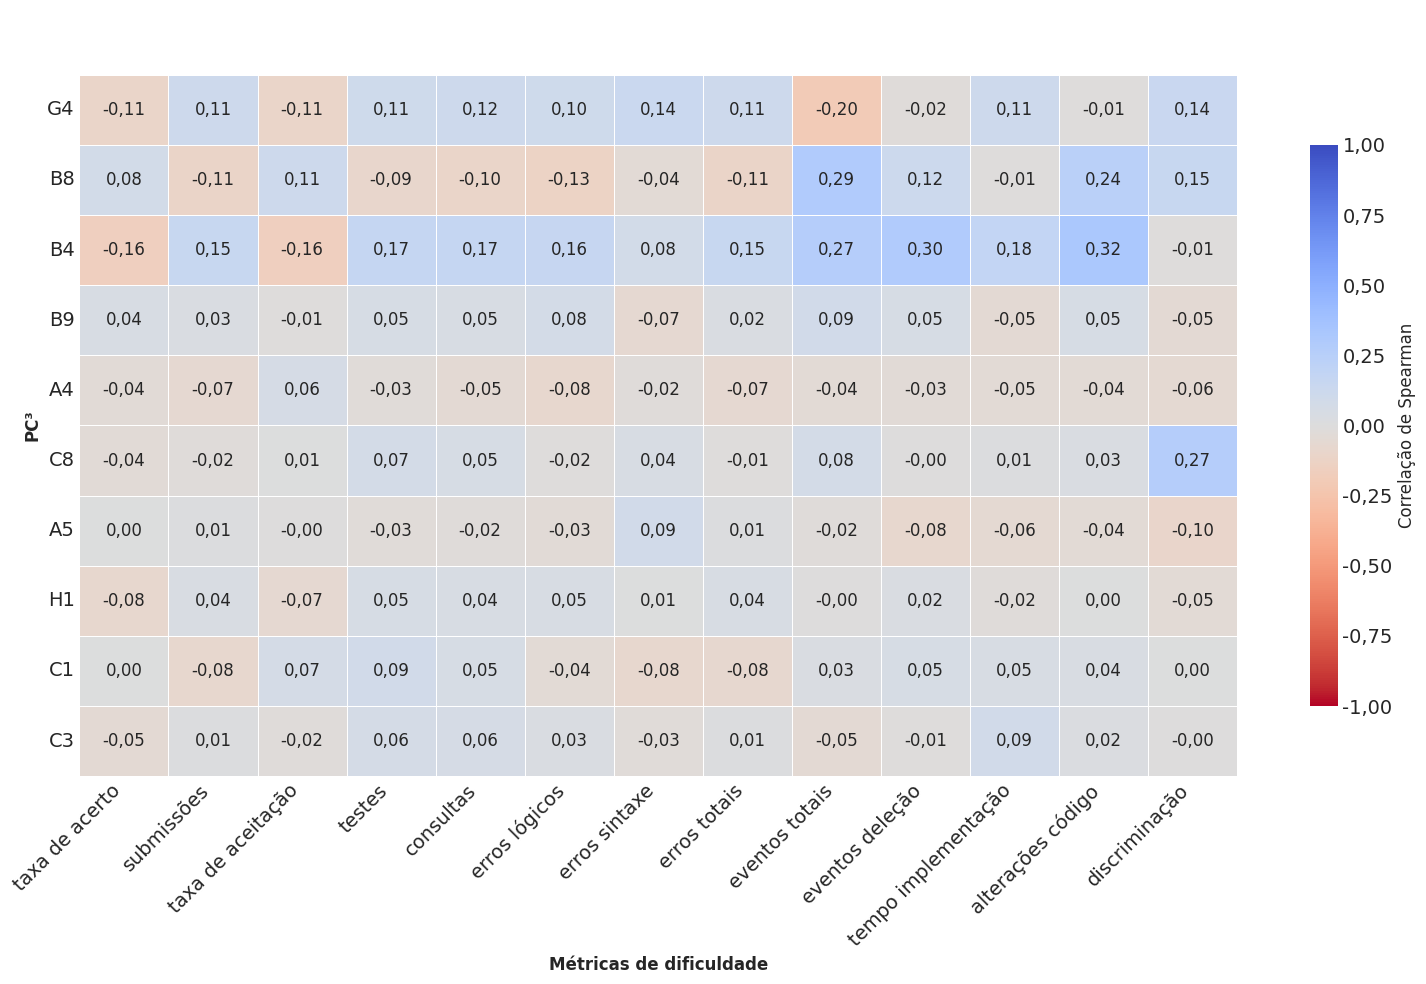

✓ Heatmap exibido

8. Analisando correlações PC³ ↔ Métricas...

CORRELAÇÕES FORTES ENTRE PC³ E MÉTRICAS (|ρ| > 0,7)
Nenhuma correlação forte encontrada entre PC³ e Métricas.

CORRELAÇÕES MODERADAS ENTRE PC³ E MÉTRICAS (0,5 < |ρ| ≤ 0,7)
Nenhuma correlação moderada encontrada.

RESUMO DA ANÁLISE
✓ Total de questões analisadas: 597
✓ PC³ analisados: 10 (Top 10)
✓ Métricas de dificuldade analisadas: 13
✓ Dimensão da matriz: 10 PC³ × 13 Métricas
✓ Correlações fortes  (|ρ| > 0,7): 0
✓ Correlações moderadas (0,5 < |ρ| ≤ 0,7): 0

⚠️  Métrica 'dificuldade' ignorada conforme configuração.

ANÁLISE CONCLUÍDA COM SUCESSO!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configurações
QUESTIONS_PATH = "questions_D_M.csv"

# Mapeamento de Colunas PC³
PC3_MAP = {
    'A4': 'A4', 'A5': 'A5', 'B4': 'B4', 'B6': 'B6',
    'B8': 'B8', 'B9': 'B9', 'B12': 'B12', 'C1': 'C1',
    'C2': 'C2', 'C3': 'C3', 'C4': 'C4', 'C8': 'C8',
    'D4': 'D4', 'E2': 'E2', 'G4': 'G4', 'G5': 'G5',
    'H1': 'H1'
}

# ============================================================================
# MAPEAMENTO DAS MÉTRICAS DE DIFICULDADE
# Colunas reais do CSV → nomes legíveis
# 'dificuldade' é ignorada intencionalmente
# M1:  taxa_acerto           = num_correct / num_students_interactions
# M2:  num_submissoes        = num_submissions / num_students_interactions
# M3:  taxa_aceitacao        = num_correct / num_submissions
# M4:  num_testes            = num_tests / num_students_interactions
# M5:  num_consultas         = (num_submissions + num_tests) / num_students_interactions
# M6:  num_erros_lgcs        = num_logic_errors / num_students_interactions
# M7:  num_errors_stx        = num_syntax_errors / num_students_interactions
# M8:  num_erros             = num_errors / num_students_interactions
# M9:  num_eventos           = num_events / num_students_interactions
# M10: num_eventos_del       = num_deletes / num_students_interactions
# M11: tempo_implementacao   = code_time / num_correct
# M12: qtd_alteracoes_codigo = amount_of_change / num_students_interactions
# M13: discriminacao         (fórmula própria - já calculada)
# ============================================================================
traducao_metricas = {
    'taxa_acerto':           'taxa de acerto',      # M1
    'num_submissoes':        'submissões',           # M2
    'taxa_aceitacao':        'taxa de aceitação',    # M3
    'num_testes':            'testes',               # M4
    'num_consultas':         'consultas',            # M5
    'num_erros_lgcs':        'erros lógicos',        # M6
    'num_errors_stx':        'erros sintaxe',        # M7
    'num_erros':             'erros totais',         # M8
    'num_eventos':           'eventos totais',       # M9
    'num_eventos_del':       'eventos deleção',      # M10
    'tempo_implementacao':   'tempo implementação',  # M11
    'qtd_alteracoes_codigo': 'alterações código',    # M12
    'discriminacao':         'discriminação',        # M13
}

def formatar_decimal(valor, casas=2):
    """Formata decimal com vírgula"""
    if pd.isna(valor) or np.isnan(valor):
        return 'N/A'
    formato = f"{{:.{casas}f}}"
    return formato.format(valor).replace('.', ',')

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def analisar_correlacao_pc3_metricas(top_n=10):
    """
    Analisa correlação entre PC³ e Métricas de Dificuldade

    Parâmetros:
        top_n (int): Número de PC³ mais frequentes a analisar. Default: 10
                     Use None para analisar todos os PC³ ativos.
    """

    print("=" * 80)
    print("ANÁLISE DE CORRELAÇÃO: PC³ vs MÉTRICAS DE DIFICULDADE")
    print("=" * 80)

    # 1. CARREGAR DADOS
    print("\n1. Carregando dados...")
    df = pd.read_csv(QUESTIONS_PATH)
    print(f"   Total de questões no arquivo: {len(df)}")

    # 2. FILTRAR QUESTÕES COM 16+ RESPOSTAS
    print("\n2. Filtrando questões com 16+ respostas...")
    pc3_columns = [col for col in list(PC3_MAP.keys()) if col in df.columns]
    df['total_responses'] = df[pc3_columns].sum(axis=1)
    df_filtered = df[df['total_responses'] >= 16].copy()
    print(f"   Questões com 16+ respostas: {len(df_filtered)}")
    print(f"   Questões excluídas: {len(df) - len(df_filtered)}")

    # 3. IDENTIFICAR COLUNAS PC³ ATIVAS (não vazias)
    print("\n3. Identificando PC³ ativos...")
    pc3_active = []
    pc3_removed = []

    for col in pc3_columns:
        if df_filtered[col].sum() > 0:
            pc3_active.append(col)
        else:
            pc3_removed.append(PC3_MAP[col])

    if pc3_removed:
        print(f"   ⚠️ PC³ removidos (sem ocorrências): {', '.join(pc3_removed)}")
    print(f"   ✓ PC³ ativos totais: {len(pc3_active)}")

    # 4. IDENTIFICAR MÉTRICAS DE DIFICULDADE DISPONÍVEIS NO CSV
    print("\n4. Identificando métricas de dificuldade válidas...")
    difficulty_metrics = []

    for metric in traducao_metricas.keys():
        if metric in df_filtered.columns:
            try:
                df_filtered[metric] = pd.to_numeric(df_filtered[metric], errors='coerce')
                if df_filtered[metric].dropna().shape[0] > 0:
                    difficulty_metrics.append(metric)
            except:
                pass
        else:
            print(f"   ⚠️ Coluna '{metric}' não encontrada no CSV. Ignorando.")

    print(f"   ✓ Métricas válidas para análise: {len(difficulty_metrics)}")
    for i, m in enumerate(difficulty_metrics, 1):
        print(f"     MD{i}: {m} → {traducao_metricas[m]}")

    # 5. ORDENAR PC³ POR FREQUÊNCIA E APLICAR TOP_N
    print("\n5. Ordenando PC³ por frequência...")
    pc3_totals = {col: df_filtered[col].sum() for col in pc3_active}
    pc3_sorted = sorted(pc3_totals.items(), key=lambda x: x[1], reverse=True)

    if top_n is not None and top_n < len(pc3_sorted):
        pc3_sorted = pc3_sorted[:top_n]
        print(f"   ℹ️ Selecionando os Top {top_n} PC³ mais frequentes")
    else:
        print(f"   ℹ️ Analisando todos os {len(pc3_sorted)} PC³ ativos")

    pc3_ordered = [col for col, _ in pc3_sorted]

    print("   Ordem (decrescente por frequência):")
    display_limit = min(10, len(pc3_ordered))
    for i, col in enumerate(pc3_ordered[:display_limit], 1):
        print(f"      {i}. {PC3_MAP[col]}: {int(pc3_totals[col])} ocorrências")
    if len(pc3_ordered) > display_limit:
        print(f"      ... e mais {len(pc3_ordered) - display_limit} PC³")

    # 6. CALCULAR CORRELAÇÃO ENTRE PC³ E MÉTRICAS
    print("\n6. Calculando correlação de Spearman (PC³ vs Métricas)...")

    n_pc3 = len(pc3_ordered)
    n_metrics = len(difficulty_metrics)

    corr_cross = np.zeros((n_pc3, n_metrics))

    for i, pc3_col in enumerate(pc3_ordered):
        for j, metric_col in enumerate(difficulty_metrics):
            valid_mask = df_filtered[pc3_col].notna() & df_filtered[metric_col].notna()
            if valid_mask.sum() > 1:
                corr_val = df_filtered.loc[valid_mask, [pc3_col, metric_col]].corr(method='spearman').iloc[0, 1]
                corr_cross[i, j] = corr_val
            else:
                corr_cross[i, j] = np.nan

    pc3_names = [PC3_MAP[col] for col in pc3_ordered]
    metric_names = [traducao_metricas[m] for m in difficulty_metrics]

    # 7. EXIBIR MATRIZ (TEXTO)
    print("\n" + "=" * 80)
    print("MATRIZ DE CORRELAÇÃO: PC³ (linhas) vs MÉTRICAS (colunas)")
    print("=" * 80)
    print()

    header = f"{'PC³':<20}"
    for name in metric_names:
        header += f"{name[:12]:>14}"
    print(header)
    print("-" * (20 + 14 * n_metrics))

    for i, pc3_name in enumerate(pc3_names):
        line = f"{pc3_name:<20}"
        for j in range(n_metrics):
            val = corr_cross[i, j]
            line += f"{'N/A':>14}" if np.isnan(val) else f"{formatar_decimal(val, 2):>14}"
        print(line)

    # 8. HEATMAP COMPLETO
    print("\n7. Gerando heatmap...")

    plt.figure(figsize=(max(14, n_metrics * 1.2), max(10, n_pc3 * 0.6)))

    corr_df = pd.DataFrame(corr_cross, index=pc3_names, columns=metric_names)
    annot_data = corr_df.applymap(lambda x: formatar_decimal(x, 2))

    sns.heatmap(corr_df,
                annot=annot_data,
                fmt='',
                cmap='coolwarm_r',
                center=0,
                vmin=-1,
                vmax=1,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8, "label": "Correlação de Spearman"})

    plt.title('\n', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Métricas de dificuldade', fontsize=12, fontweight='bold')
    plt.ylabel('PC³', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    ax = plt.gca()
    colorbar = ax.collections[0].colorbar
    colorbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_decimal(x, 2)))

    plt.tight_layout()
    plt.show()
    print("✓ Heatmap exibido")

    # 9. CORRELAÇÕES FORTES
    print("\n8. Analisando correlações PC³ ↔ Métricas...")
    print("\n" + "=" * 80)
    print("CORRELAÇÕES FORTES ENTRE PC³ E MÉTRICAS (|ρ| > 0,7)")
    print("=" * 80)

    strong_cross = []
    for i in range(n_pc3):
        for j in range(n_metrics):
            val = corr_cross[i, j]
            if not np.isnan(val) and abs(val) > 0.7:
                strong_cross.append({
                    'PC³': pc3_names[i],
                    'Métrica': metric_names[j],
                    'ρ': formatar_decimal(val, 2)
                })

    if strong_cross:
        print(pd.DataFrame(strong_cross).to_string(index=False))
    else:
        print("Nenhuma correlação forte encontrada entre PC³ e Métricas.")

    # 10. CORRELAÇÕES MODERADAS
    print("\n" + "=" * 80)
    print("CORRELAÇÕES MODERADAS ENTRE PC³ E MÉTRICAS (0,5 < |ρ| ≤ 0,7)")
    print("=" * 80)

    moderate_cross = []
    for i in range(n_pc3):
        for j in range(n_metrics):
            val = corr_cross[i, j]
            if not np.isnan(val) and 0.5 < abs(val) <= 0.7:
                moderate_cross.append({
                    'PC³': pc3_names[i],
                    'Métrica': metric_names[j],
                    'ρ': formatar_decimal(val, 2)
                })

    if moderate_cross:
        print(pd.DataFrame(moderate_cross).to_string(index=False))
    else:
        print("Nenhuma correlação moderada encontrada.")

    # 11. RESUMO FINAL
    print("\n" + "=" * 80)
    print("RESUMO DA ANÁLISE")
    print("=" * 80)
    print(f"✓ Total de questões analisadas: {len(df_filtered)}")
    print(f"✓ PC³ analisados: {n_pc3} {'(Top ' + str(top_n) + ')' if top_n else '(Todos)'}")
    print(f"✓ Métricas de dificuldade analisadas: {n_metrics}")
    print(f"✓ Dimensão da matriz: {n_pc3} PC³ × {n_metrics} Métricas")
    print(f"✓ Correlações fortes  (|ρ| > 0,7): {len(strong_cross)}")
    print(f"✓ Correlações moderadas (0,5 < |ρ| ≤ 0,7): {len(moderate_cross)}")
    print(f"\n⚠️  Métrica 'dificuldade' ignorada conforme configuração.")
    print("\n" + "=" * 80)
    print("ANÁLISE CONCLUÍDA COM SUCESSO!")
    print("=" * 80)


# EXECUTAR ANÁLISE
print("\n")
print("💡 USO: analisar_correlacao_pc3_metricas(top_n=10)")
print("   - top_n=10   : Analisa os 10 PC³ mais frequentes (padrão)")
print("   - top_n=None : Analisa todos os PC³ ativos")
print("=" * 80)
print("\n")

analisar_correlacao_pc3_metricas(top_n=10)

# 5 - Comparação entre PC³ e métricas de dificuldade

⚠️ Não foi possível configurar locale brasileiro.


🔬 ANÁLISE MANN-WHITNEY U: PC³ vs MÉTRICAS DE DIFICULDADE
1. Seleciona os TOP 10 PC³ mais frequentes
2. Partição com threshold adaptativo (5% dos estudantes)
3. Normalização z-score das métricas (preserva índice)
4. Teste Mann-Whitney U (p < 0,05 → diferença significativa)
5. r de Cohen (tamanho do efeito para casos significativos)
6. Heatmap dicotômico (verde/vermelho)
7. Tabelas completas por PC³

📌 FORMATAÇÃO: vírgula para decimais, ponto para milhares (padrão BR)


ANÁLISE MANN-WHITNEY U: PC³ vs MÉTRICAS DE DIFICULDADE

1. Carregando dados...
   Total de questões no arquivo: 829

2. Filtrando questões com 16+ respostas...
   Questões com 16+ respostas: 597
   Questões excluídas: 232

3. Identificando PC³ ativos...
   ✓ Total de PC³ ativos: 15
   ✓ Selecionando os TOP 10 mais frequentes

PC3  Questões  Total_Ocorrencias  Prevalência
 G4       597              15670    26.247906
 B8       339               3887     6.510888
 B4      

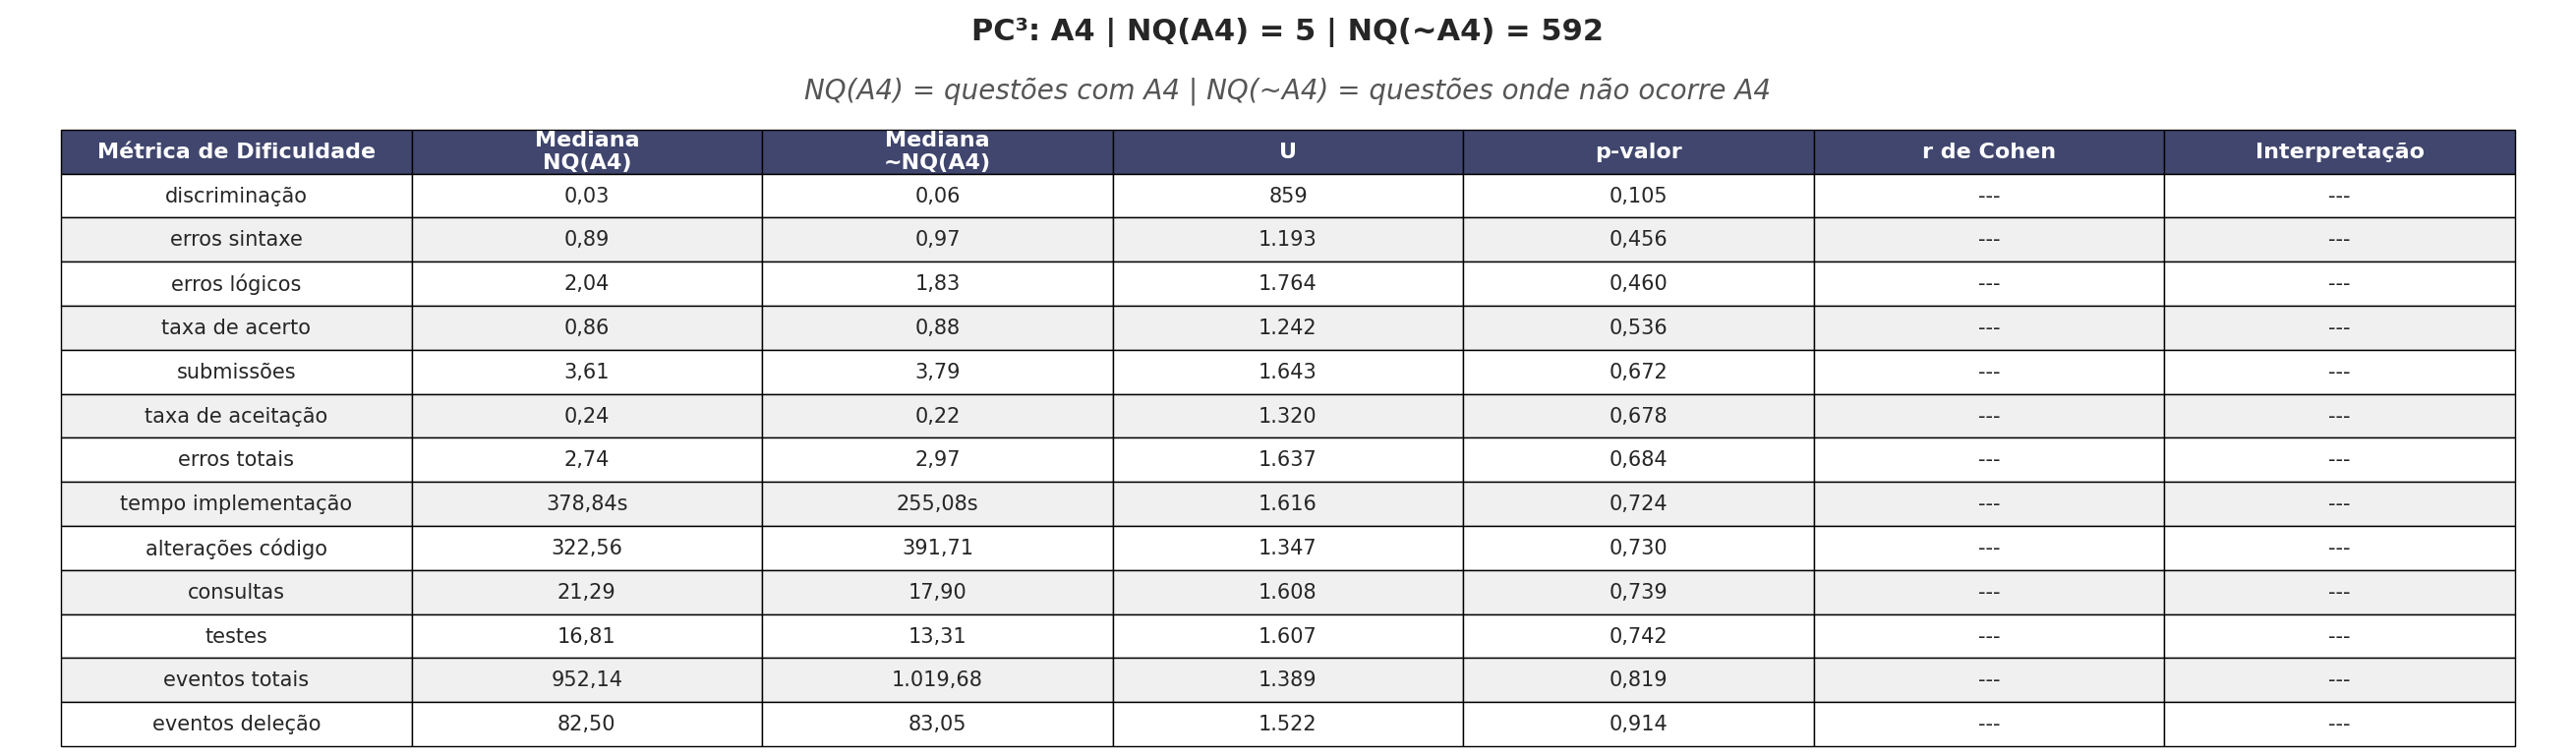

   ✓ Tabela para A4 exibida (0/13 significativas)


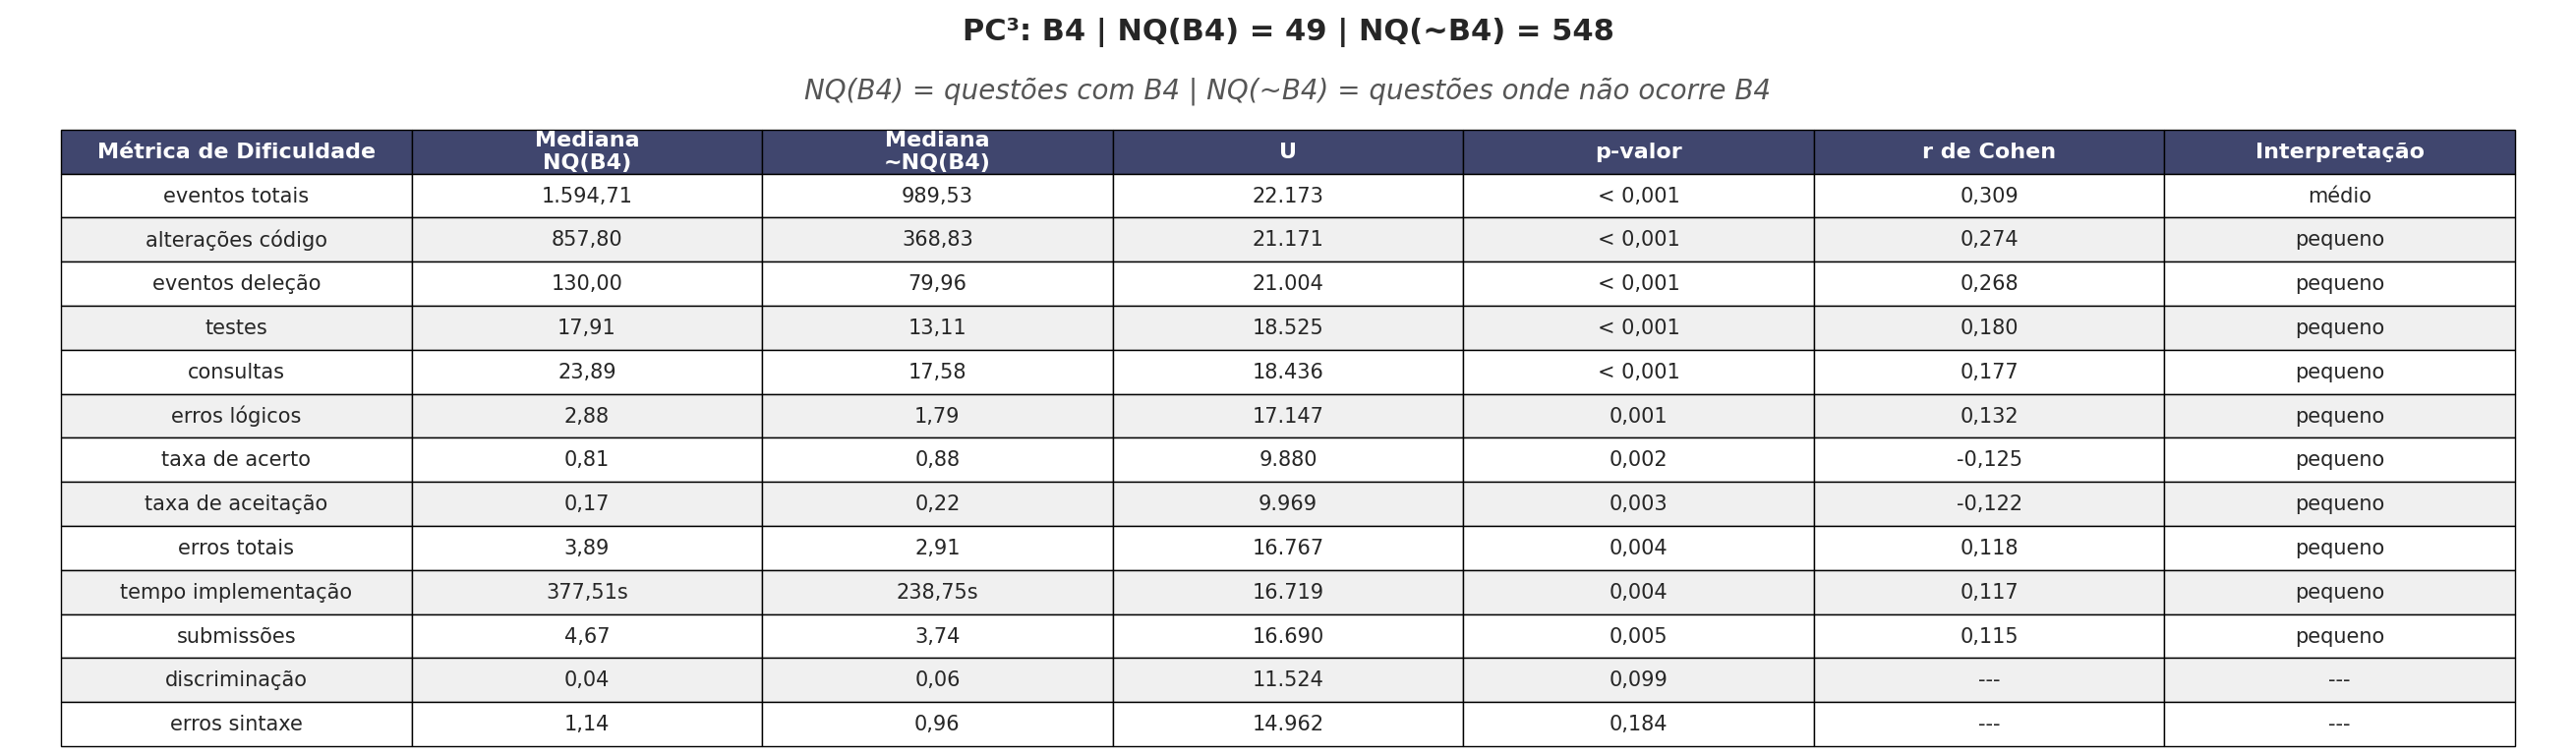

   ✓ Tabela para B4 exibida (11/13 significativas)


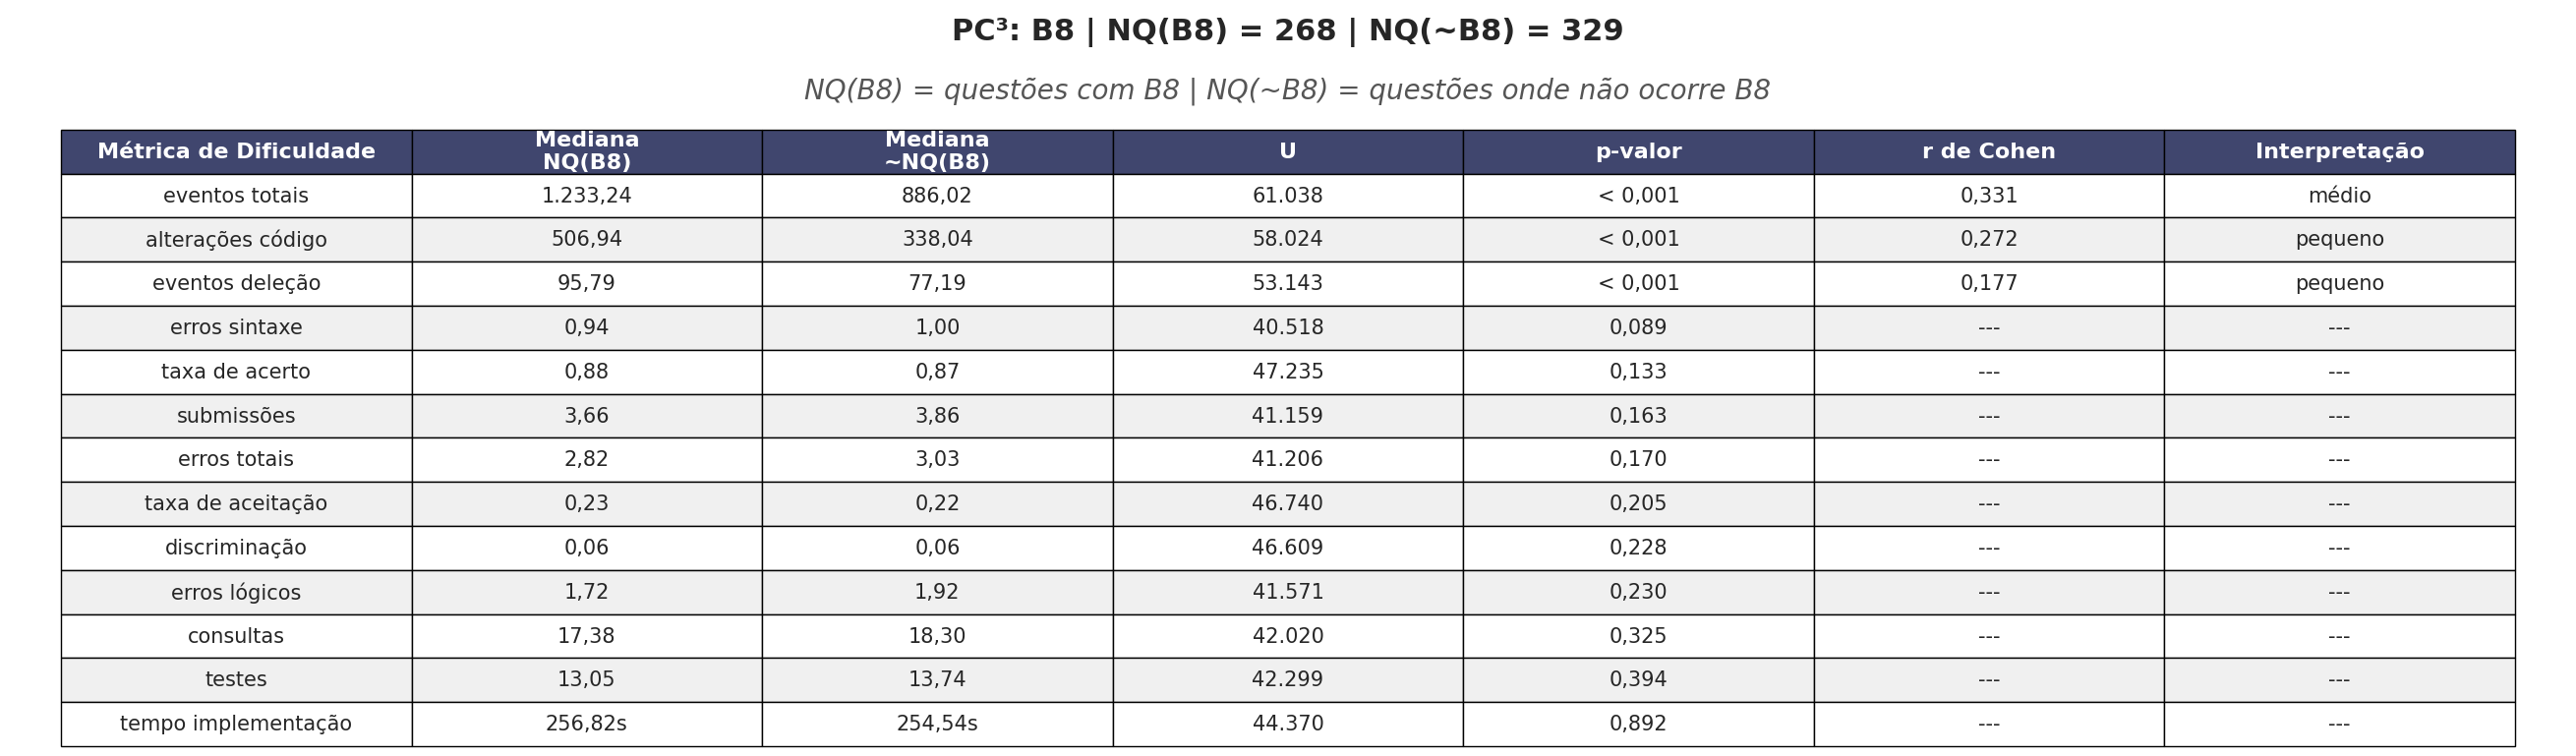

   ✓ Tabela para B8 exibida (3/13 significativas)


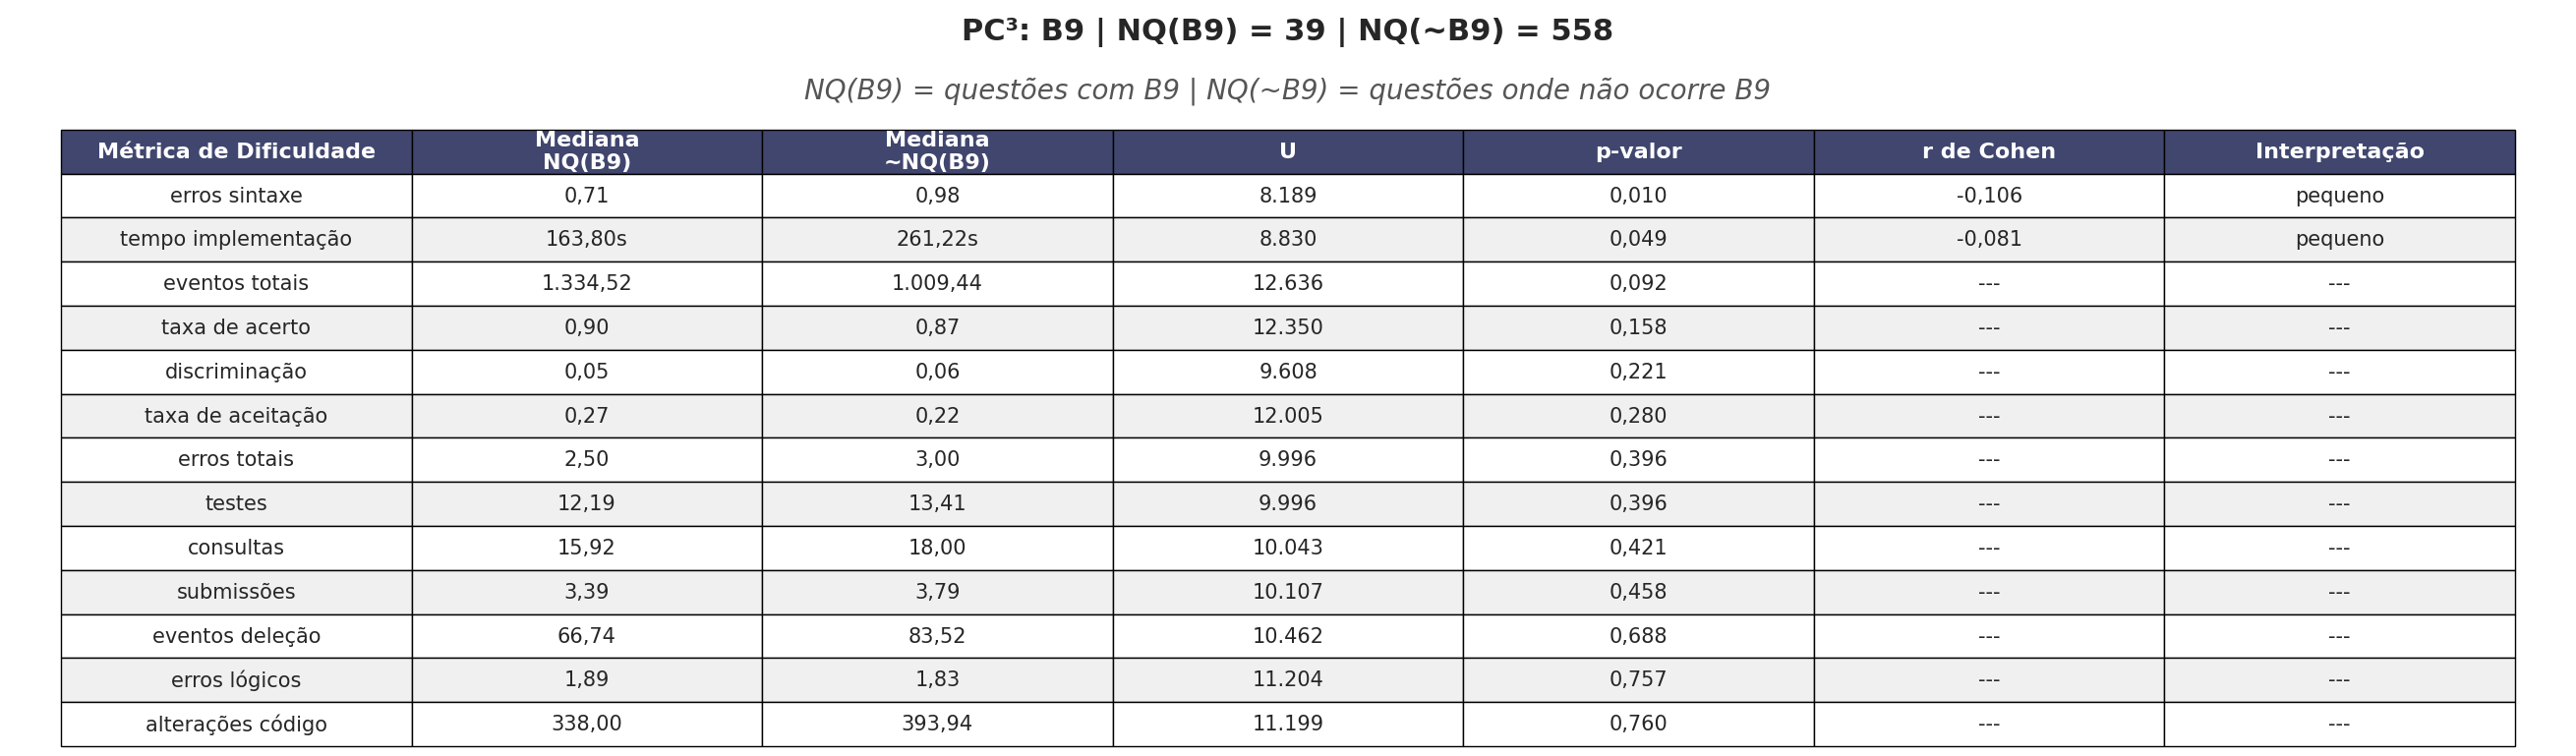

   ✓ Tabela para B9 exibida (2/13 significativas)


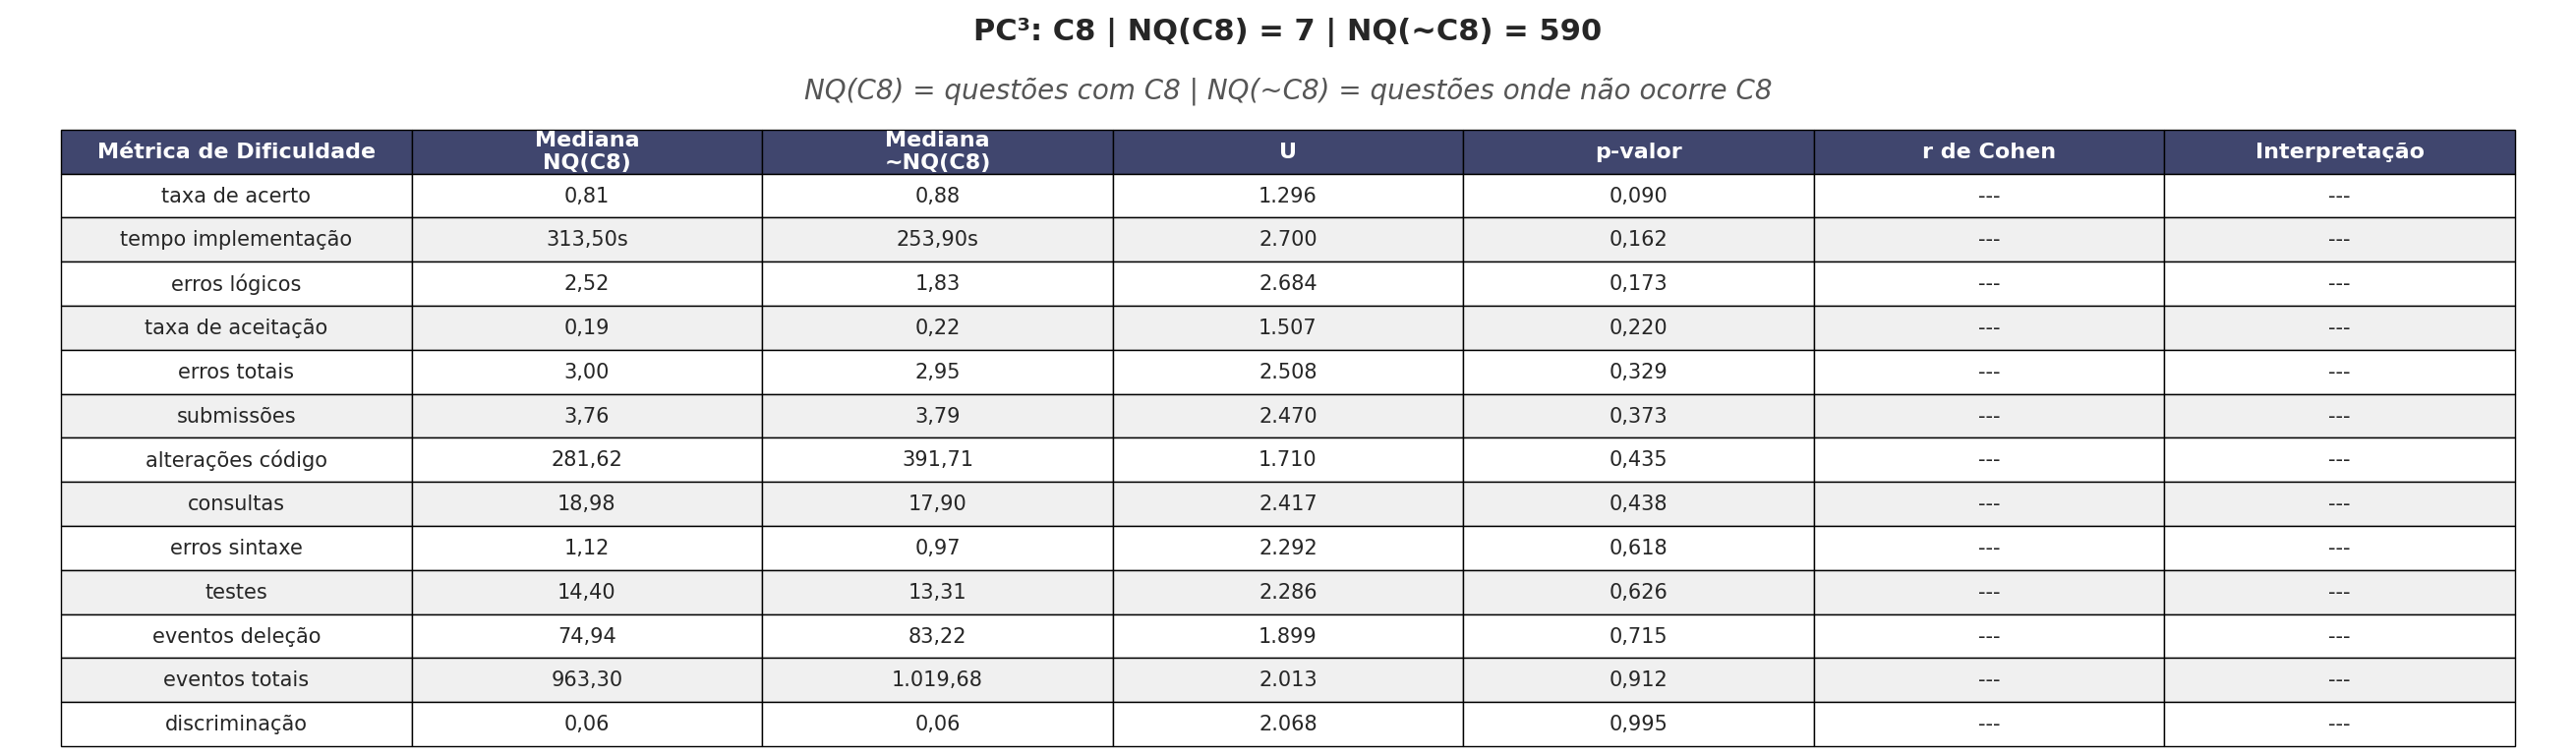

   ✓ Tabela para C8 exibida (0/13 significativas)

📊 LEGENDA r DE COHEN: |r| < 0,3 pequeno | < 0,5 médio | ≥ 0,5 grande | --- não calculado

HEATMAP DICOTÔMICO DE SIGNIFICÂNCIA


/tmp/ipykernel_1100/1136371549.py:535: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matriz_p_fmt = matriz_p_df.applymap(lambda x: formatar_numero_br(x, 2) if not pd.isna(x) else '')


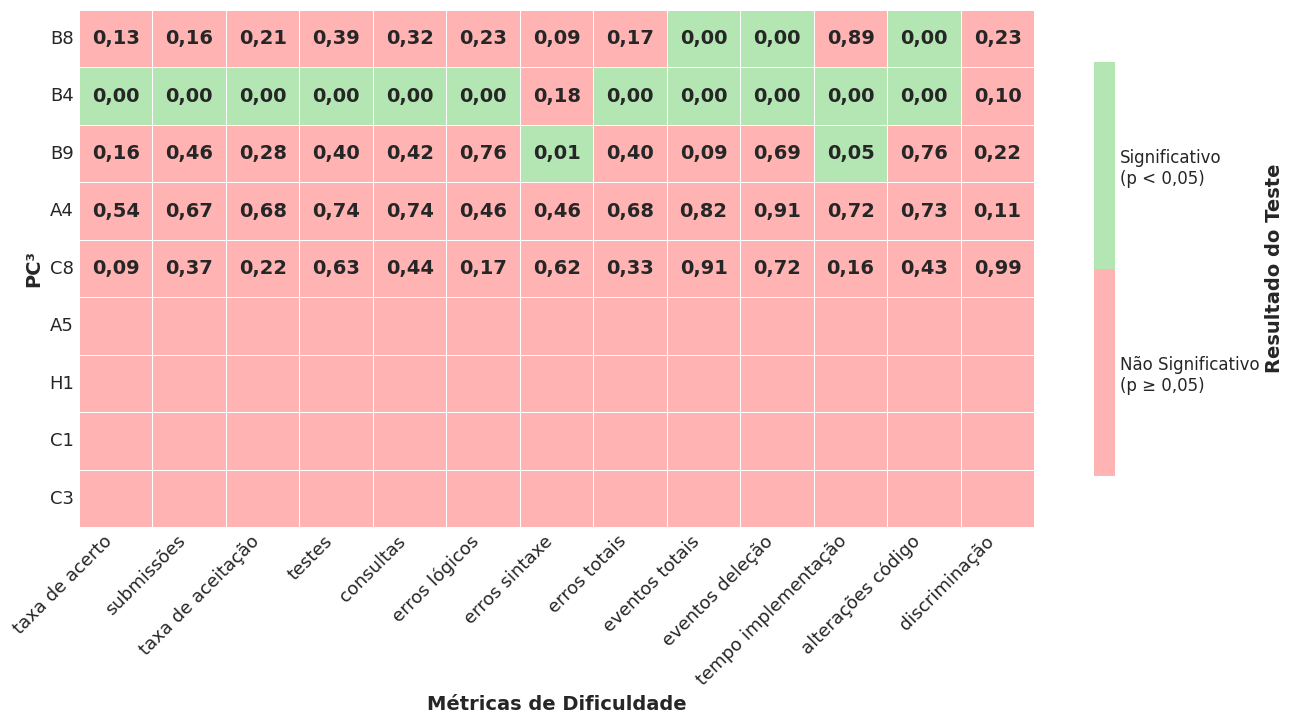

   ✓ Heatmap dicotômico exibido

NOTA SOBRE PC³ EXCLUÍDOS DO HEATMAP (MISCONCEPTIONS UNIVERSAIS)

• G4: Mi=597 questões, ~Mi=0 questões | prevalência média=26,2

ASSOCIAÇÕES COM EFEITO GRANDE (|r| ≥ 0,5)

Nenhuma associação com efeito grande encontrada.

RESUMO DA ANÁLISE
✓ Questões analisadas: 597
✓ PC³ identificados: 10 (TOP 10 mais frequentes)
✓ PC³ com partição viável analisados: 9
✓ PC³ excluídos (universais): 1
✓ Métricas de dificuldade: 13
✓ Threshold: 5.0% dos estudantes
✓ Total de testes realizados: 65
✓ Associações significativas: 16 (24,6%)
✓ Associações com efeito grande: 0

⚠️  Métrica 'dificuldade' ignorada conforme configuração.

ANÁLISE CONCLUÍDA COM SUCESSO!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import locale

# Configurar locale para formatação brasileira
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except:
    try:
        locale.setlocale(locale.LC_ALL, 'Portuguese_Brazil.1252')
    except:
        print("⚠️ Não foi possível configurar locale brasileiro.")

import matplotlib
matplotlib.rcParams['axes.formatter.use_locale'] = True

# ============================================================================
# CONFIGURAÇÕES
# ============================================================================
QUESTIONS_PATH = "questions_D_M.csv"

TOP_N_PC3 = 10
THRESHOLD_PERCENTUAL = 0.05
ALPHA = 0.05

# ============================================================================
# Mapeamento de PC³
# ============================================================================
PC3_MAP = {
    'A4': 'A4', 'A5': 'A5', 'B4': 'B4', 'B6': 'B6',
    'B8': 'B8', 'B9': 'B9', 'B12': 'B12', 'C1': 'C1',
    'C2': 'C2', 'C3': 'C3', 'C4': 'C4', 'C8': 'C8',
    'D4': 'D4', 'E2': 'E2', 'G4': 'G4', 'G5': 'G5',
    'H1': 'H1'
}

# ============================================================================
# MAPEAMENTO DAS MÉTRICAS DE DIFICULDADE
# Colunas reais do CSV → nomes legíveis
# 'dificuldade' é ignorada intencionalmente
# M1:  taxa_acerto           = num_correct / num_students_interactions
# M2:  num_submissoes        = num_submissions / num_students_interactions
# M3:  taxa_aceitacao        = num_correct / num_submissions
# M4:  num_testes            = num_tests / num_students_interactions
# M5:  num_consultas         = (num_submissions + num_tests) / num_students_interactions
# M6:  num_erros_lgcs        = num_logic_errors / num_students_interactions
# M7:  num_errors_stx        = num_syntax_errors / num_students_interactions
# M8:  num_erros             = num_errors / num_students_interactions
# M9:  num_eventos           = num_events / num_students_interactions
# M10: num_eventos_del       = num_deletes / num_students_interactions
# M11: tempo_implementacao   = code_time / num_correct
# M12: qtd_alteracoes_codigo = amount_of_change / num_students_interactions
# M13: discriminacao         (fórmula própria - já calculada)
# ============================================================================
traducao_metricas = {
    'taxa_acerto':           'taxa de acerto',      # M1
    'num_submissoes':        'submissões',           # M2
    'taxa_aceitacao':        'taxa de aceitação',    # M3
    'num_testes':            'testes',               # M4
    'num_consultas':         'consultas',            # M5
    'num_erros_lgcs':        'erros lógicos',        # M6
    'num_errors_stx':        'erros sintaxe',        # M7
    'num_erros':             'erros totais',         # M8
    'num_eventos':           'eventos totais',       # M9
    'num_eventos_del':       'eventos deleção',      # M10
    'tempo_implementacao':   'tempo implementação',  # M11
    'qtd_alteracoes_codigo': 'alterações código',    # M12
    'discriminacao':         'discriminação',        # M13
}

# Métricas com casas decimais na formatação
METRICAS_DECIMAIS = {'taxa_acerto', 'taxa_aceitacao', 'discriminacao'}

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# FUNÇÕES AUXILIARES DE FORMATAÇÃO
# ============================================================================
def formatar_numero_br(valor, decimais=2):
    """Formata número no padrão brasileiro (vírgula decimal, ponto milhar)"""
    if pd.isna(valor) or valor == '' or valor is None:
        return ''
    try:
        valor_float = float(valor)
        if np.isnan(valor_float) or np.isinf(valor_float):
            return '---'
        formato = f'%.{decimais}f'
        texto = formato % valor_float
        texto = texto.replace('.', ',')
        partes = texto.split(',')
        parte_inteira = partes[0]
        if len(parte_inteira) > 3:
            nova_parte = ''
            for i, digito in enumerate(reversed(parte_inteira)):
                if i > 0 and i % 3 == 0:
                    nova_parte = '.' + nova_parte
                nova_parte = digito + nova_parte
            parte_inteira = nova_parte
        if len(partes) > 1:
            return parte_inteira + ',' + partes[1]
        else:
            return parte_inteira
    except:
        return str(valor)

def formatar_inteiro_br(valor):
    """Formata inteiro no padrão brasileiro (ponto para milhares)"""
    try:
        valor_int = int(valor)
        texto = str(valor_int)
        if len(texto) > 3:
            nova_texto = ''
            for i, digito in enumerate(reversed(texto)):
                if i > 0 and i % 3 == 0:
                    nova_texto = '.' + nova_texto
                nova_texto = digito + nova_texto
            return nova_texto
        return texto
    except:
        return str(valor)

def formatar_mediana_valor(valor, nome_coluna):
    """
    Formata mediana para exibição nas colunas de mediana das figuras/tabelas.
    TODAS as métricas são exibidas com exatamente 2 casas decimais (0,00).
    tempo_implementacao recebe sufixo 's'.
    """
    if pd.isna(valor):
        return '---'
    if nome_coluna == 'tempo_implementacao':
        return formatar_numero_br(valor, 2) + 's'
    else:
        return formatar_numero_br(valor, 2)

# ============================================================================
# FUNÇÕES AUXILIARES
# ============================================================================
def calcular_threshold(respostas, percentual):
    return percentual * respostas

def particionar_grupos(df, mi, threshold_col='threshold'):
    grupo_mi = df[df[mi] > df[threshold_col]].copy()
    grupo_nao_mi = df[df[mi] <= df[threshold_col]].copy()
    return grupo_mi, grupo_nao_mi

def cohen_r(u_statistic, n1, n2):
    N = n1 + n2
    if N == 0:
        return np.nan
    mean_u = (n1 * n2) / 2
    std_u = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
    if std_u == 0:
        return np.nan
    z = (u_statistic - mean_u) / std_u
    return z / np.sqrt(N)

def interpretar_cohen_r(r):
    if np.isnan(r):
        return "---"
    r_abs = abs(r)
    if r_abs < 0.3:
        return "pequeno"
    elif r_abs < 0.5:
        return "médio"
    else:
        return "grande"

def criar_tabela_matplotlib(df, titulo, subtitulo=None, figsize=(14, None), col_colors=None, header_color='#40466e'):
    if figsize[1] is None:
        altura = max(3, len(df) * 0.45 + 1.8)
        figsize = (figsize[0], altura)

    fig = plt.figure(figsize=figsize)

    ax_title = fig.add_axes([0, 0.90, 1, 0.10])
    ax_title.axis('off')
    if titulo:
        ax_title.text(0.5, 0.7, titulo, ha='center', va='center',
                     fontsize=22, fontweight='bold', transform=ax_title.transAxes)
    if subtitulo:
        ax_title.text(0.5, 0.1, subtitulo, ha='center', va='top',
                     fontsize=20, style='italic', color='#555555', transform=ax_title.transAxes)

    ax = fig.add_axes([0.02, 0.02, 0.96, 0.82])
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=df.values, colLabels=df.columns,
                    cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(15)
    table.scale(1, 2.4)

    for j in range(len(df.columns)):
        cell = table[(0, j)]
        cell.set_facecolor(header_color)
        cell.set_text_props(weight='bold', color='white', fontsize=16)

    for i in range(1, len(df) + 1):
        for j in range(len(df.columns)):
            cell = table[(i, j)]
            cell.set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')

    return fig

def formatar_p_valor(p):
    if p >= 0.001:
        return formatar_numero_br(p, 3)
    elif p > 1e-16:
        return '< 0,001'
    else:
        return '<< 0,001'

def cor_p_valor(p):
    if isinstance(p, str):
        if '<' in p:
            return '#90ee90'
        try:
            p = float(str(p).replace(',', '.'))
        except:
            return None
    try:
        p_float = float(p)
        if p_float < 0.01:
            return '#90ee90'
        elif p_float < 0.05:
            return '#ffff99'
        else:
            return '#ffcccb'
    except:
        return None

def cor_cohen_r(r):
    if r == '---':
        return '#f0f0f0'
    try:
        r_float = float(str(r).replace(',', '.').replace('+', ''))
        intensidade = min(abs(r_float) / 0.5, 1.0)
        if r_float > 0:
            return plt.cm.Greens(0.3 + intensidade * 0.5)
        else:
            return plt.cm.Reds(0.3 + intensidade * 0.5)
    except:
        return None

# ============================================================================
# ANÁLISE PRINCIPAL
# ============================================================================
def analisar_mann_whitney_pc3_metricas():
    """Análise Mann-Whitney U: PC³ vs Métricas de Dificuldade"""

    print("=" * 80)
    print("ANÁLISE MANN-WHITNEY U: PC³ vs MÉTRICAS DE DIFICULDADE")
    print("=" * 80)

    # 1. CARREGAR DADOS
    print("\n1. Carregando dados...")
    df = pd.read_csv(QUESTIONS_PATH)
    print(f"   Total de questões no arquivo: {len(df)}")

    # 2. FILTRAR QUESTÕES COM 16+ RESPOSTAS
    print("\n2. Filtrando questões com 16+ respostas...")
    pc3_columns = [col for col in list(PC3_MAP.keys()) if col in df.columns]
    df['total_responses'] = df[pc3_columns].sum(axis=1)
    df_filtered = df[df['total_responses'] >= 16].copy()
    print(f"   Questões com 16+ respostas: {len(df_filtered)}")
    print(f"   Questões excluídas: {len(df) - len(df_filtered)}")

    # 3. IDENTIFICAR PC³ ATIVOS E SELECIONAR TOP N
    print("\n3. Identificando PC³ ativos...")
    pc3_all = []
    for pc3 in pc3_columns:
        if pc3 not in df_filtered.columns:
            continue
        total_ocorrencias = df_filtered[pc3].sum()
        if total_ocorrencias > 0:
            pc3_all.append({
                'pc3_code': pc3,
                'PC3': PC3_MAP[pc3],
                'Questões': (df_filtered[pc3] > 0).sum(),
                'Total_Ocorrencias': int(total_ocorrencias),
                'Prevalência': df_filtered[pc3].mean()
            })

    pc3_all_sorted = sorted(pc3_all, key=lambda x: x['Total_Ocorrencias'], reverse=True)

    if TOP_N_PC3 is not None and TOP_N_PC3 < len(pc3_all_sorted):
        pc3_selected = pc3_all_sorted[:TOP_N_PC3]
        print(f"   ✓ Total de PC³ ativos: {len(pc3_all_sorted)}")
        print(f"   ✓ Selecionando os TOP {TOP_N_PC3} mais frequentes")
    else:
        pc3_selected = pc3_all_sorted
        print(f"   ✓ Analisando TODOS os {len(pc3_all_sorted)} PC³ ativos")

    pc3_frequentes = [item['pc3_code'] for item in pc3_selected]

    if pc3_selected:
        print("\n" + pd.DataFrame(pc3_selected)[['PC3', 'Questões', 'Total_Ocorrencias', 'Prevalência']].to_string(index=False))

    if len(pc3_frequentes) == 0:
        print("\n   ⚠️ Nenhum PC³ ativo encontrado!")
        return

    # 4. IDENTIFICAR MÉTRICAS DE DIFICULDADE VÁLIDAS
    print("\n4. Identificando métricas de dificuldade válidas...")
    difficulty_metrics = []
    for metric in traducao_metricas.keys():
        if metric in df_filtered.columns:
            try:
                df_filtered[metric] = pd.to_numeric(df_filtered[metric], errors='coerce')
                if df_filtered[metric].dropna().shape[0] > 5:
                    difficulty_metrics.append(metric)
            except:
                pass
        else:
            print(f"   ⚠️ Coluna '{metric}' não encontrada no CSV. Ignorando.")

    print(f"   ✓ Métricas válidas: {len(difficulty_metrics)}")
    for i, metric in enumerate(difficulty_metrics, 1):
        print(f"     MD{i}: {traducao_metricas[metric]}")

    # 5. CALCULAR THRESHOLDS
    print("\n5. Calculando thresholds adaptativos...")
    print(f"   Threshold: {THRESHOLD_PERCENTUAL*100}% do número de estudantes por questão")
    df_filtered['threshold'] = df_filtered['respostas'].apply(
        lambda x: calcular_threshold(x, THRESHOLD_PERCENTUAL)
    )
    print(f"   Threshold médio: {formatar_numero_br(df_filtered['threshold'].mean())} estudantes")
    print(f"   Threshold mínimo: {formatar_numero_br(df_filtered['threshold'].min())} estudantes")
    print(f"   Threshold máximo: {formatar_numero_br(df_filtered['threshold'].max())} estudantes")

    # 6. NORMALIZAR MÉTRICAS (Z-SCORE) — cálculo manual para preservar índice e NaNs
    print("\n6. Normalizando métricas (z-score)...")
    for metric in difficulty_metrics:
        col = df_filtered[metric]
        media = col.mean()
        desvio = col.std()
        df_filtered[f'{metric}_zscore'] = (col - media) / desvio if desvio != 0 else col * 0
    print("   ✓ Normalização concluída")

    # 7. ANÁLISE MANN-WHITNEY U
    print("\n7. Executando testes Mann-Whitney U...")

    pc3_viaveis = []
    pc3_excluidos = []

    for mi in pc3_frequentes:
        grupo_mi, grupo_nao_mi = particionar_grupos(df_filtered, mi)
        if len(grupo_nao_mi) >= 5:
            pc3_viaveis.append(mi)
        else:
            pc3_excluidos.append({
                'pc3': mi,
                'nome': PC3_MAP[mi],
                'n_mi': len(grupo_mi),
                'n_nao_mi': len(grupo_nao_mi),
                'prevalencia': df_filtered[mi].mean()
            })

    print(f"   PC³ com partição viável (grupo ~Mi ≥ 5): {len(pc3_viaveis)}")
    print(f"   PC³ excluídos (grupo ~Mi < 5): {len(pc3_excluidos)}")

    if pc3_excluidos:
        print("\n   PC³ EXCLUÍDOS DA ANÁLISE MANN-WHITNEY:")
        for item in pc3_excluidos:
            print(f"     - {item['nome']}: Mi={item['n_mi']}, ~Mi={item['n_nao_mi']} "
                  f"(prevalência={formatar_numero_br(item['prevalencia'], 1)})")
        print("\n   ⚠️ Esses PC³ aparecem em praticamente TODAS as questões (>5% estudantes)")
        print("   ⚠️ São considerados MISCONCEPTIONS UNIVERSAIS")

    if len(pc3_viaveis) == 0:
        print("\n   ⚠️ Nenhum PC³ com partição viável encontrado!")
        return

    print(f"\n   Total de testes: {len(pc3_viaveis)} PC³ × {len(difficulty_metrics)} métricas "
          f"= {len(pc3_viaveis) * len(difficulty_metrics)}")

    resultados = []

    for mi in pc3_viaveis:
        print(f"\n   {'='*70}")
        print(f"   PC³: {PC3_MAP[mi]}")
        print(f"   {'='*70}")

        grupo_mi, grupo_nao_mi = particionar_grupos(df_filtered, mi)
        n_mi, n_nao_mi = len(grupo_mi), len(grupo_nao_mi)
        pct_mi = (n_mi / len(df_filtered)) * 100
        pct_nao_mi = (n_nao_mi / len(df_filtered)) * 100
        razao = max(n_mi, n_nao_mi) / min(n_mi, n_nao_mi) if min(n_mi, n_nao_mi) > 0 else np.inf

        print(f"   Grupos:")
        print(f"     - Mi  (>{THRESHOLD_PERCENTUAL*100}% estudantes): {n_mi} questões ({formatar_numero_br(pct_mi, 1)}%)")
        print(f"     - ~Mi (≤{THRESHOLD_PERCENTUAL*100}% estudantes): {n_nao_mi} questões ({formatar_numero_br(pct_nao_mi, 1)}%)")
        print(f"     - Razão de desbalanceamento: {formatar_numero_br(razao)}")
        if razao > 10:
            print(f"     ⚠️ AVISO: Grupos muito desbalanceados (razão > 10)")

        for metric in difficulty_metrics:
            valores_mi = grupo_mi[metric].dropna()
            valores_nao_mi = grupo_nao_mi[metric].dropna()

            if len(valores_mi) < 5 or len(valores_nao_mi) < 5:
                continue

            try:
                statistic, p_value = mannwhitneyu(valores_mi, valores_nao_mi, alternative='two-sided')
            except Exception as e:
                print(f"     ⚠️ Erro em {metric}: {e}")
                continue

            significativo = p_value < ALPHA
            resultado = {
                'PC3': PC3_MAP[mi],
                'Metrica': traducao_metricas[metric],
                'metrica_original': metric,
                'pc3_code': mi,
                'n_Mi': n_mi,
                'n_~Mi': n_nao_mi,
                'pct_Mi': pct_mi,
                'pct_~Mi': pct_nao_mi,
                'razao': razao,
                'mean_Mi': valores_mi.mean(),
                'mean_~Mi': valores_nao_mi.mean(),
                'U_statistic': statistic,
                'p_valor': p_value,
                'significativo': significativo,
                'cohen_r': np.nan,
                'interpretacao': '---',
            }

            if significativo:
                r = cohen_r(statistic, len(valores_mi), len(valores_nao_mi))
                resultado['cohen_r'] = r
                resultado['interpretacao'] = interpretar_cohen_r(r)
                print(f"     ✓ {traducao_metricas[metric]}: p={formatar_numero_br(p_value, 3)}, "
                      f"r={formatar_numero_br(r, 3)} ({resultado['interpretacao']})")

            resultados.append(resultado)

    # 8. COMPILAR RESULTADOS
    print("\n" + "=" * 80)
    print("8. Compilando resultados...")
    df_resultados = pd.DataFrame(resultados)
    total_testes = len(df_resultados)
    significativos = df_resultados[df_resultados['significativo'] == True]
    n_significativos = len(significativos)
    print(f"   Total de testes realizados: {total_testes}")
    print(f"   Resultados significativos (p < {ALPHA}): {n_significativos} "
          f"({formatar_numero_br(n_significativos/total_testes*100, 1)}%)")

    # 9. TABELAS POR PC³
    print("\n" + "=" * 80)
    print("TABELAS: TODAS AS MÉTRICAS TESTADAS - POR PC³")
    print("=" * 80)

    if len(df_resultados) > 0:
        pc3_unicos = sorted(df_resultados['PC3'].unique())
        print(f"\nTotal de PC³ testados: {len(pc3_unicos)}\n")

        for pc3_nome in pc3_unicos:
            resultados_pc3 = df_resultados[df_resultados['PC3'] == pc3_nome].copy()
            pc3_code = resultados_pc3.iloc[0]['pc3_code']
            nq_pc3 = resultados_pc3.iloc[0]['n_Mi']
            nq_not_pc3 = resultados_pc3.iloc[0]['n_~Mi']
            n_sig_pc3 = resultados_pc3['significativo'].sum()
            n_total = len(resultados_pc3)

            # Ordenar: significativos por |r|, depois não-significativos por p-valor
            resultados_pc3['sort_key'] = resultados_pc3.apply(
                lambda row: (0, -abs(row['cohen_r']) if not np.isnan(row['cohen_r']) else 0)
                            if row['significativo'] else (1, row['p_valor']), axis=1
            )
            resultados_pc3_sorted = resultados_pc3.sort_values('sort_key')

            grupo_mi, grupo_nao_mi = particionar_grupos(df_filtered, pc3_code)

            # Calcular medianas
            med_mi_list, med_nao_mi_list = [], []
            for _, row in resultados_pc3_sorted.iterrows():
                col = row['metrica_original']
                med_mi_list.append(grupo_mi[col].median() if col in df_filtered.columns else np.nan)
                med_nao_mi_list.append(grupo_nao_mi[col].median() if col in df_filtered.columns else np.nan)

            # Montar tabela — medianas sempre com 2 casas decimais via formatar_mediana_valor
            tabela_data = pd.DataFrame({
                'Métrica de Dificuldade': resultados_pc3_sorted['Metrica'].values,
                f'Mediana\nNQ({pc3_code})': [
                    formatar_mediana_valor(v, c)
                    for v, c in zip(med_mi_list, resultados_pc3_sorted['metrica_original'])
                ],
                f'Mediana\n~NQ({pc3_code})': [
                    formatar_mediana_valor(v, c)
                    for v, c in zip(med_nao_mi_list, resultados_pc3_sorted['metrica_original'])
                ],
                'U': resultados_pc3_sorted['U_statistic'].apply(formatar_inteiro_br).values,
                'p-valor': resultados_pc3_sorted['p_valor'].apply(formatar_p_valor).values,
                'r de Cohen': resultados_pc3_sorted['cohen_r'].apply(
                    lambda x: formatar_numero_br(x, 3) if not np.isnan(x) else '---'
                ).values,
                'Interpretação': resultados_pc3_sorted['interpretacao'].values,
            })

            titulo = f'PC³: {pc3_nome} | NQ({pc3_code}) = {nq_pc3} | NQ(~{pc3_code}) = {nq_not_pc3}'
            subtitulo = (f'NQ({pc3_code}) = questões com {pc3_code} | '
                         f'NQ(~{pc3_code}) = questões onde não ocorre {pc3_code}')

            fig = criar_tabela_matplotlib(tabela_data, titulo=titulo, subtitulo=subtitulo, figsize=(26, None))
            plt.show()
            print(f"   ✓ Tabela para {pc3_nome} exibida ({n_sig_pc3}/{n_total} significativas)")

        print("\n📊 LEGENDA r DE COHEN: |r| < 0,3 pequeno | < 0,5 médio | ≥ 0,5 grande | --- não calculado")

    # 10. HEATMAP DICOTÔMICO
    print("\n" + "=" * 80)
    print("HEATMAP DICOTÔMICO DE SIGNIFICÂNCIA")
    print("=" * 80)

    pc3_names = [PC3_MAP[pc3] for pc3 in pc3_viaveis]
    metric_names = [traducao_metricas[m] for m in difficulty_metrics]
    matriz_p = np.full((len(pc3_names), len(metric_names)), np.nan)

    for _, row in df_resultados.iterrows():
        if row['PC3'] in pc3_names:
            i = pc3_names.index(row['PC3'])
            j = metric_names.index(row['Metrica'])
            matriz_p[i, j] = row['p_valor']

    matriz_p_df = pd.DataFrame(matriz_p, index=pc3_names, columns=metric_names)
    matriz_sig_df = pd.DataFrame((matriz_p < ALPHA).astype(int), index=pc3_names, columns=metric_names)
    matriz_p_fmt = matriz_p_df.applymap(lambda x: formatar_numero_br(x, 2) if not pd.isna(x) else '')

    cell_width, cell_height = 0.8, 0.6
    fig_width = max(10, len(metric_names) * cell_width + 3)
    fig_height = max(6, len(pc3_names) * cell_height + 2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(matriz_sig_df, annot=matriz_p_fmt, fmt='',
                cmap=['#ffb3b3', '#b3e6b3'],
                cbar_kws={"ticks": [0.25, 0.75], "shrink": 0.8},
                linewidths=0.5, linecolor='white', ax=ax,
                annot_kws={"fontsize": 14, "weight": "bold"})

    cbar = ax.collections[0].colorbar
    cbar.set_ticklabels(['Não Significativo\n(p ≥ 0,05)', 'Significativo\n(p < 0,05)'])
    cbar.set_label('Resultado do Teste', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    plt.xlabel('Métricas de Dificuldade', fontsize=14, fontweight='bold')
    plt.ylabel('PC³', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=13)
    plt.yticks(rotation=0, fontsize=13)
    plt.tight_layout()
    plt.show()
    print("   ✓ Heatmap dicotômico exibido")

    if pc3_excluidos:
        print("\n" + "=" * 80)
        print("NOTA SOBRE PC³ EXCLUÍDOS DO HEATMAP (MISCONCEPTIONS UNIVERSAIS)")
        print("=" * 80)
        for item in pc3_excluidos:
            print(f"\n• {item['nome']}: Mi={item['n_mi']} questões, ~Mi={item['n_nao_mi']} questões "
                  f"| prevalência média={formatar_numero_br(item['prevalencia'], 1)}")

    # 11. ASSOCIAÇÕES COM EFEITO GRANDE
    print("\n" + "=" * 80)
    print("ASSOCIAÇÕES COM EFEITO GRANDE (|r| ≥ 0,5)")
    print("=" * 80)

    efeito_grande = significativos[significativos['cohen_r'].abs() >= 0.5]

    if len(efeito_grande) > 0:
        efeito_sorted = efeito_grande.sort_values('cohen_r', key=abs, ascending=False)

        rows = []
        for _, row in efeito_sorted.iterrows():
            pc3_code = row['pc3_code']
            col = row['metrica_original']
            grupo_mi, grupo_nao_mi = particionar_grupos(df_filtered, pc3_code)
            med_mi = grupo_mi[col].median() if col in df_filtered.columns else np.nan
            med_nao_mi = grupo_nao_mi[col].median() if col in df_filtered.columns else np.nan

            rows.append({
                'PC³': row['PC3'],
                'Métrica de Dificuldade': row['Metrica'],
                # Medianas sempre com 2 casas decimais via formatar_mediana_valor
                'Mediana NQ(Mi)': formatar_mediana_valor(med_mi, col),
                'Mediana ~NQ(Mi)': formatar_mediana_valor(med_nao_mi, col),
                'U': formatar_inteiro_br(row['U_statistic']),
                'p-valor': formatar_p_valor(row['p_valor']),
                'r de Cohen': formatar_numero_br(row['cohen_r'], 3),
                'Interpretação': row['interpretacao'],
            })

        tabela_grande = pd.DataFrame(rows)
        fig = criar_tabela_matplotlib(
            tabela_grande,
            titulo='Associações com Efeito GRANDE',
            subtitulo='|r de Cohen| ≥ 0,5',
            figsize=(28, None),
            header_color='#8b0000'
        )
        plt.show()
        print("   ✓ Tabela exibida")
    else:
        print("\nNenhuma associação com efeito grande encontrada.")

    # 12. RESUMO FINAL
    print("\n" + "=" * 80)
    print("RESUMO DA ANÁLISE")
    print("=" * 80)
    print(f"✓ Questões analisadas: {len(df_filtered)}")
    print(f"✓ PC³ identificados: {len(pc3_frequentes)} "
          f"{'(TOP ' + str(TOP_N_PC3) + ' mais frequentes)' if TOP_N_PC3 else '(TODOS os ativos)'}")
    print(f"✓ PC³ com partição viável analisados: {len(pc3_viaveis)}")
    print(f"✓ PC³ excluídos (universais): {len(pc3_excluidos)}")
    print(f"✓ Métricas de dificuldade: {len(difficulty_metrics)}")
    print(f"✓ Threshold: {THRESHOLD_PERCENTUAL*100}% dos estudantes")
    print(f"✓ Total de testes realizados: {total_testes}")
    print(f"✓ Associações significativas: {n_significativos} "
          f"({formatar_numero_br(n_significativos/total_testes*100, 1)}%)")
    print(f"✓ Associações com efeito grande: {len(efeito_grande)}")
    print(f"\n⚠️  Métrica 'dificuldade' ignorada conforme configuração.")
    print("\n" + "=" * 80)
    print("ANÁLISE CONCLUÍDA COM SUCESSO!")
    print("=" * 80)

    return df_resultados


# ============================================================================
# EXECUTAR ANÁLISE
# ============================================================================
if __name__ == "__main__":
    print("\n")
    print("🔬 ANÁLISE MANN-WHITNEY U: PC³ vs MÉTRICAS DE DIFICULDADE")
    print("=" * 80)
    print(f"1. Seleciona os TOP {TOP_N_PC3} PC³ mais frequentes")
    print("2. Partição com threshold adaptativo (5% dos estudantes)")
    print("3. Normalização z-score das métricas (preserva índice)")
    print("4. Teste Mann-Whitney U (p < 0,05 → diferença significativa)")
    print("5. r de Cohen (tamanho do efeito para casos significativos)")
    print("6. Heatmap dicotômico (verde/vermelho)")
    print("7. Tabelas completas por PC³")
    print("\n📌 FORMATAÇÃO: vírgula para decimais, ponto para milhares (padrão BR)")
    print("=" * 80)
    print("\n")

    resultados = analisar_mann_whitney_pc3_metricas()

# 6 - Comparação entre PC³ e fatores demográficos

In [6]:
import csv
from pathlib import Path

# ============================================================================
# CONFIGURAÇÕES
# ============================================================================

MISCONCEPTIONS_PATH = "misconceptions_detailed_por_usuario.csv"
USER_DATA_PATH = Path('../Etapa_3/UsuariosUnicos')

# ============================================================================
# FUNÇÕES
# ============================================================================

def obter_lista_estudantes_catalogados():
    """
    Retorna LISTA de IDs de estudantes catalogados
    
    Similar a contar_estudantes(), mas retorna a LISTA em vez de apenas o count
    
    Retorna:
        set: conjunto de IDs únicos de usuários
    """
    estudantes = set()
    
    try:
        with open(MISCONCEPTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            
            for linha in reader:
                if 'usuario' in linha and linha['usuario']:
                    estudantes.add(linha['usuario'])
        
        return estudantes
    except FileNotFoundError:
        print(f"❌ Arquivo {MISCONCEPTIONS_PATH} não encontrado")
        return set()


# ============================================================================
# ANÁLISE PRINCIPAL
# ============================================================================

# 1. OBTER LISTA DE ESTUDANTES CATALOGADOS
print("=" * 70)
print("ANÁLISE DE user.data - APENAS ESTUDANTES CATALOGADOS")
print("=" * 70)

estudantes_catalogados = obter_lista_estudantes_catalogados()
print(f"\n📊 Estudantes catalogados: {len(estudantes_catalogados)}")

# 2. VERIFICAR TOTAL DE PASTAS NO DIRETÓRIO
caminho = USER_DATA_PATH

if not caminho.exists():
    print(f"❌ Caminho não encontrado: {caminho}")
    exit()

total_pastas_no_disco = sum(1 for item in caminho.iterdir() if item.is_dir())
print(f"📁 Total de pastas em {caminho.name}: {total_pastas_no_disco}")

# 3. BUSCAR APENAS NAS PASTAS DOS ESTUDANTES CATALOGADOS
print(f"\n🔍 Buscando user.data APENAS dos {len(estudantes_catalogados)} estudantes catalogados...\n")

# Categorias para verificar
categorias = {
    'CURRENT DEGREE COURSE': 0,
    'HIGH SCHOOL': 0,
    'PERSONAL COMPUTER': 0,
    'WORK': 0,
    'PREVIOUS DEGREE': 0,
    'OTHER INFORMATION': 0
}

# Total de arquivos processados
total_arquivos_encontrados = 0
total_arquivos_nao_encontrados = 0

# ============================================================================
# ITERAR APENAS PELOS ESTUDANTES CATALOGADOS (não por todas as pastas!)
# ============================================================================

for usuario in estudantes_catalogados:
    # Construir caminho da pasta do usuário
    pasta_usuario = caminho / usuario
    arquivo_user_data = pasta_usuario / 'user.data'
    
    if arquivo_user_data.exists() and arquivo_user_data.is_file():
        total_arquivos_encontrados += 1
        
        # Ler o conteúdo do arquivo
        try:
            with open(arquivo_user_data, 'r', encoding='utf-8') as f:
                conteudo = f.read()
            
            # Verificar presença de cada categoria
            for categoria in categorias.keys():
                if f'-- {categoria}:' in conteudo:
                    categorias[categoria] += 1
                    
        except Exception as e:
            print(f"⚠️  Erro ao ler {arquivo_user_data}: {e}")
    else:
        total_arquivos_nao_encontrados += 1

# ============================================================================
# EXIBIR RESULTADOS
# ============================================================================

print("=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"\n📊 RESUMO:")
print(f"   • Total de pastas no disco: {total_pastas_no_disco}")
print(f"   • Estudantes catalogados: {len(estudantes_catalogados)}")
print(f"   • Arquivos user.data encontrados: {total_arquivos_encontrados}")
print(f"   • Arquivos user.data NÃO encontrados: {total_arquivos_nao_encontrados}")

if total_arquivos_nao_encontrados > 0:
    porcentagem_faltando = (total_arquivos_nao_encontrados / len(estudantes_catalogados)) * 100
    print(f"\n⚠️  {total_arquivos_nao_encontrados} estudantes catalogados ({porcentagem_faltando:.1f}%) não têm pasta em {caminho.name}")

print(f"\n📈 CONTAGEM POR CATEGORIA:")
print("-" * 70)

for categoria, count in categorias.items():
    if total_arquivos_encontrados > 0:
        porcentagem = (count / total_arquivos_encontrados * 100)
        print(f"-- {categoria:<25}: {count:>4} ({porcentagem:>5.1f}%)")
    else:
        print(f"-- {categoria:<25}: {count:>4}")

print("\n" + "=" * 70)

ANÁLISE DE user.data - APENAS ESTUDANTES CATALOGADOS

📊 Estudantes catalogados: 2836
📁 Total de pastas em UsuariosUnicos: 3435

🔍 Buscando user.data APENAS dos 2836 estudantes catalogados...

RESULTADOS

📊 RESUMO:
   • Total de pastas no disco: 3435
   • Estudantes catalogados: 2836
   • Arquivos user.data encontrados: 2836
   • Arquivos user.data NÃO encontrados: 0

📈 CONTAGEM POR CATEGORIA:
----------------------------------------------------------------------
-- CURRENT DEGREE COURSE    : 2836 (100.0%)
-- HIGH SCHOOL              : 2733 ( 96.4%)
-- PERSONAL COMPUTER        : 2733 ( 96.4%)
-- WORK                     : 2733 ( 96.4%)
-- PREVIOUS DEGREE          : 2733 ( 96.4%)
-- OTHER INFORMATION        : 2733 ( 96.4%)



In [7]:
import csv
from pathlib import Path
from collections import defaultdict

# ============================================================================
# CONFIGURAÇÕES
# ============================================================================

MISCONCEPTIONS_PATH = "misconceptions_detailed_por_usuario.csv"
USER_DATA_PATH = Path('../Etapa_3/Processamento/UsuariosProcessamento')

# ============================================================================
# FUNÇÕES
# ============================================================================

def obter_lista_estudantes_catalogados():
    """Retorna set de IDs de estudantes catalogados"""
    estudantes = set()
    
    try:
        with open(MISCONCEPTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            
            for linha in reader:
                if 'usuario' in linha and linha['usuario']:
                    estudantes.add(linha['usuario'])
        
        return estudantes
    except FileNotFoundError:
        print(f"❌ Arquivo {MISCONCEPTIONS_PATH} não encontrado")
        return set()


def extrair_campos_categoria(conteudo, inicio_categoria, proxima_categoria=None):
    """
    Extrai todos os campos de uma categoria específica
    
    Retorna:
        dict: {campo: valor}
    """
    campos = {}
    
    # Encontrar onde começa a categoria
    if inicio_categoria not in conteudo:
        return campos
    
    inicio = conteudo.find(inicio_categoria)
    
    # Encontrar onde termina (próxima categoria ou fim do arquivo)
    if proxima_categoria:
        fim = conteudo.find(proxima_categoria, inicio)
        if fim == -1:
            fim = len(conteudo)
    else:
        fim = len(conteudo)
    
    # Extrair bloco da categoria
    bloco = conteudo[inicio:fim]
    linhas = bloco.split('\n')
    
    # Processar cada linha que começa com "----"
    for linha in linhas:
        linha = linha.strip()
        if linha.startswith('----'):
            # Remover "----" e espaços
            linha = linha.replace('----', '').strip()
            
            # Separar campo: valor
            if ':' in linha:
                campo, valor = linha.split(':', 1)
                campo = campo.strip()
                valor = valor.strip()
                
                # Se valor está vazio, marcar como "n/a"
                if not valor:
                    valor = "n/a"
                
                campos[campo] = valor
    
    return campos


def analisar_user_data_detalhado():
    """
    Análise DETALHADA de todas as subcategorias dos arquivos user.data
    """
    
    print("=" * 80)
    print("ANÁLISE DETALHADA DE user.data - ESTUDANTES CATALOGADOS")
    print("=" * 80)
    
    # 1. Obter estudantes catalogados
    estudantes_catalogados = obter_lista_estudantes_catalogados()
    print(f"\n📊 Estudantes catalogados: {len(estudantes_catalogados)}")
    
    # 2. Verificar caminho
    if not USER_DATA_PATH.exists():
        print(f"❌ Caminho não encontrado: {USER_DATA_PATH}")
        return
    
    # 3. Estruturas para armazenar contagens
    # categorias[nome_categoria][campo][valor] = count
    categorias = {
        'CURRENT DEGREE COURSE': defaultdict(lambda: defaultdict(int)),
        'HIGH SCHOOL': defaultdict(lambda: defaultdict(int)),
        'PERSONAL COMPUTER': defaultdict(lambda: defaultdict(int)),
        'WORK': defaultdict(lambda: defaultdict(int)),
        'PREVIOUS DEGREE': defaultdict(lambda: defaultdict(int)),
        'OTHER INFORMATION': defaultdict(lambda: defaultdict(int))
    }
    
    total_arquivos_encontrados = 0
    
    # 4. Processar cada estudante catalogado
    print(f"\n🔍 Processando arquivos user.data...\n")
    
    categorias_ordem = [
        'CURRENT DEGREE COURSE',
        'HIGH SCHOOL',
        'PERSONAL COMPUTER',
        'WORK',
        'PREVIOUS DEGREE',
        'OTHER INFORMATION'
    ]
    
    for usuario in estudantes_catalogados:
        pasta_usuario = USER_DATA_PATH / usuario
        arquivo_user_data = pasta_usuario / 'user.data'
        
        if arquivo_user_data.exists() and arquivo_user_data.is_file():
            total_arquivos_encontrados += 1
            
            try:
                with open(arquivo_user_data, 'r', encoding='utf-8') as f:
                    conteudo = f.read()
                
                # Processar cada categoria
                for i, categoria in enumerate(categorias_ordem):
                    # Definir próxima categoria (ou None se for a última)
                    proxima = categorias_ordem[i + 1] if i + 1 < len(categorias_ordem) else None
                    
                    # Extrair campos da categoria
                    campos = extrair_campos_categoria(
                        conteudo,
                        f'-- {categoria}:',
                        f'-- {proxima}:' if proxima else None
                    )
                    
                    # Contar cada campo:valor
                    for campo, valor in campos.items():
                        categorias[categoria][campo][valor] += 1
                
            except Exception as e:
                print(f"⚠️  Erro ao processar {arquivo_user_data}: {e}")
    
    # 5. EXIBIR RESULTADOS DETALHADOS
    print("=" * 80)
    print("RESULTADOS DETALHADOS POR CATEGORIA")
    print("=" * 80)
    print(f"\nTotal de arquivos processados: {total_arquivos_encontrados}\n")
    
    for categoria in categorias_ordem:
        campos = categorias[categoria]
        
        if not campos:
            continue
        
        print("\n" + "=" * 80)
        print(f"📋 {categoria}")
        print("=" * 80)
        
        for campo in sorted(campos.keys()):
            valores = campos[campo]
            total_respostas = sum(valores.values())
            
            print(f"\n   🔹 {campo}:")
            print(f"   {'─' * 70}")
            
            # Ordenar valores por frequência (decrescente)
            valores_ordenados = sorted(valores.items(), key=lambda x: x[1], reverse=True)
            
            for valor, count in valores_ordenados:
                porcentagem = (count / total_respostas) * 100
                
                # Truncar valores muito longos
                valor_exibido = valor if len(valor) <= 50 else valor[:47] + "..."
                
                print(f"      • {valor_exibido:<50} : {count:>4} ({porcentagem:>5.1f}%)")
    
    print("\n" + "=" * 80)
    print("ANÁLISE CONCLUÍDA!")
    print("=" * 80)


# ============================================================================
# EXECUTAR
# ============================================================================

if __name__ == "__main__":
    analisar_user_data_detalhado()

ANÁLISE DETALHADA DE user.data - ESTUDANTES CATALOGADOS

📊 Estudantes catalogados: 2836

🔍 Processando arquivos user.data...

RESULTADOS DETALHADOS POR CATEGORIA

Total de arquivos processados: 2836


📋 CURRENT DEGREE COURSE

   🔹 course id:
   ──────────────────────────────────────────────────────────────────────
      • 7                                                  :  270 (  9.5%)
      • 10                                                 :  263 (  9.3%)
      • 15                                                 :  240 (  8.5%)
      • 8                                                  :  236 (  8.3%)
      • 19                                                 :  235 (  8.3%)
      • 9                                                  :  221 (  7.8%)
      • 6                                                  :  200 (  7.1%)
      • 12                                                 :  189 (  6.7%)
      • 13                                                 :  172 (  6.1%)
      • 1


ANÁLISE DE CONTINGÊNCIA - FIGURAS AGRUPADAS

📊 Total de registros carregados: 32615
👥 Usuários únicos: 2836

🔝 Top 10 Misconceptions:
   G4: 31763 ocorrências
   B8: 25168 ocorrências
   B4: 7240 ocorrências
   B9: 5357 ocorrências
   A4: 1089 ocorrências
   C8: 1075 ocorrências
   A5: 622 ocorrências
   H1: 223 ocorrências
   C1: 203 ocorrências
   C3: 134 ocorrências

🔄 Gerando figuras agrupadas...

✅ TOTAL DE FIGURAS GERADAS: 4

💾 Salvo: contingencia_tipo_de_escola.png


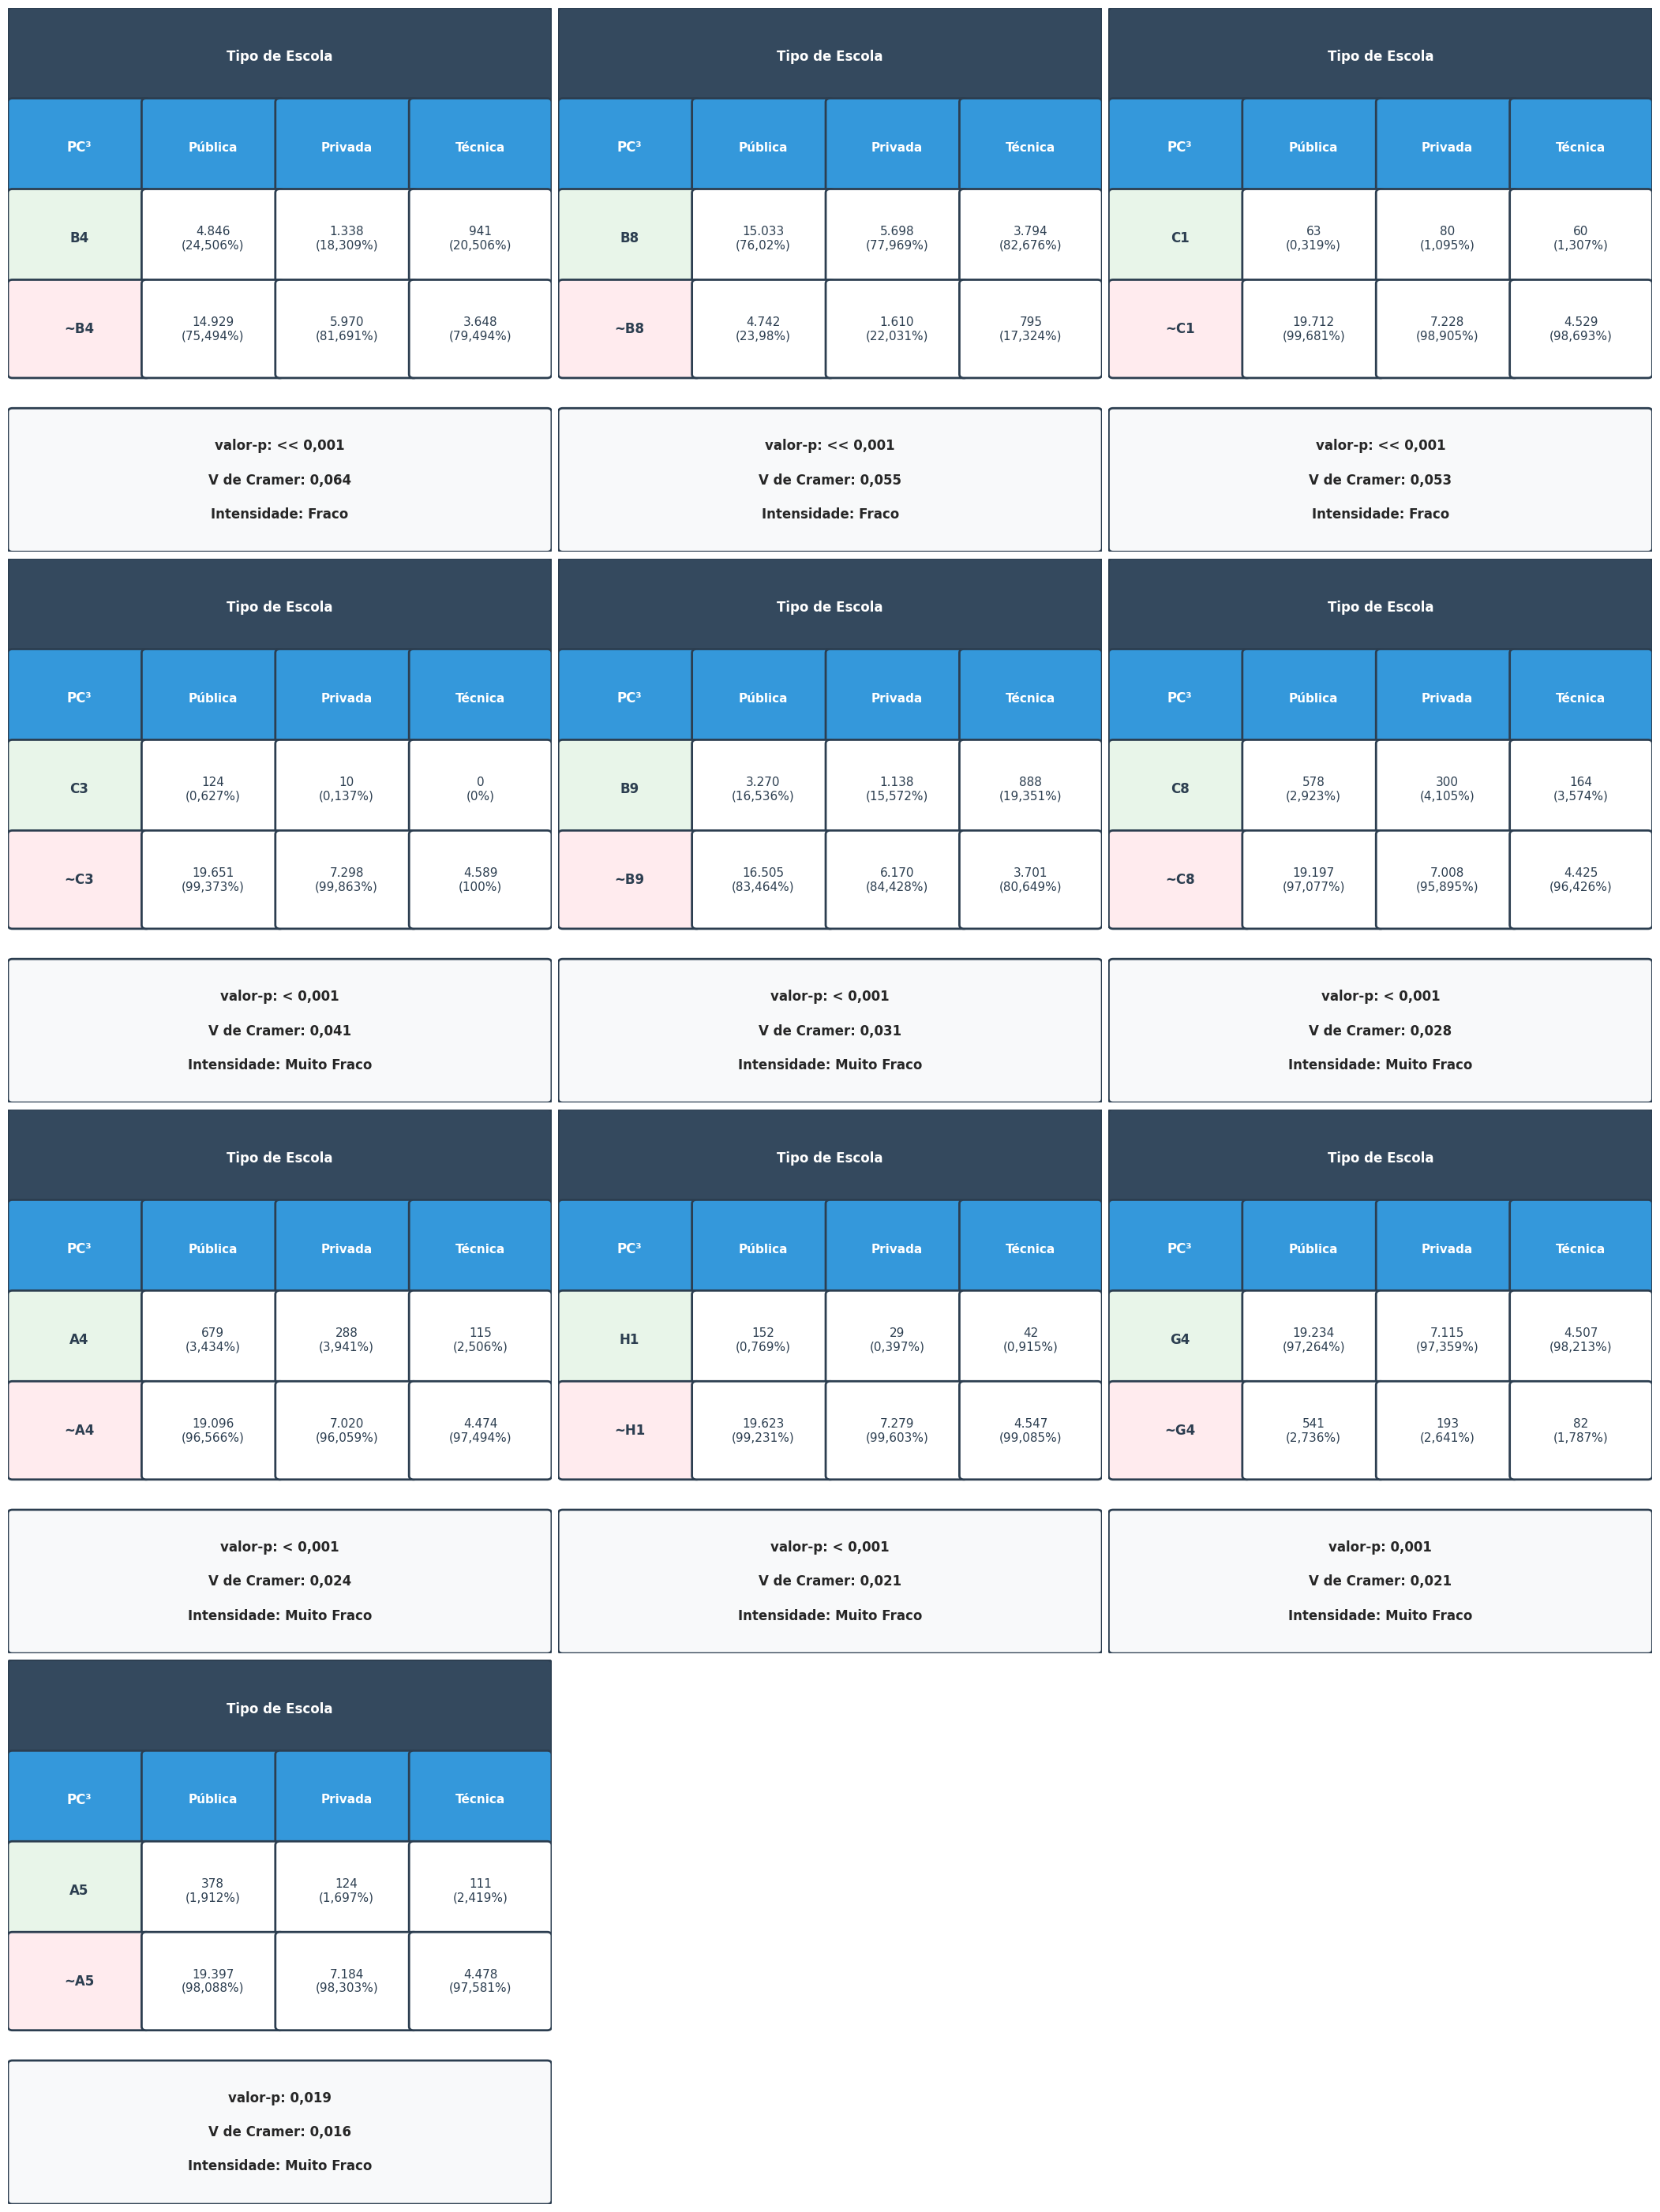

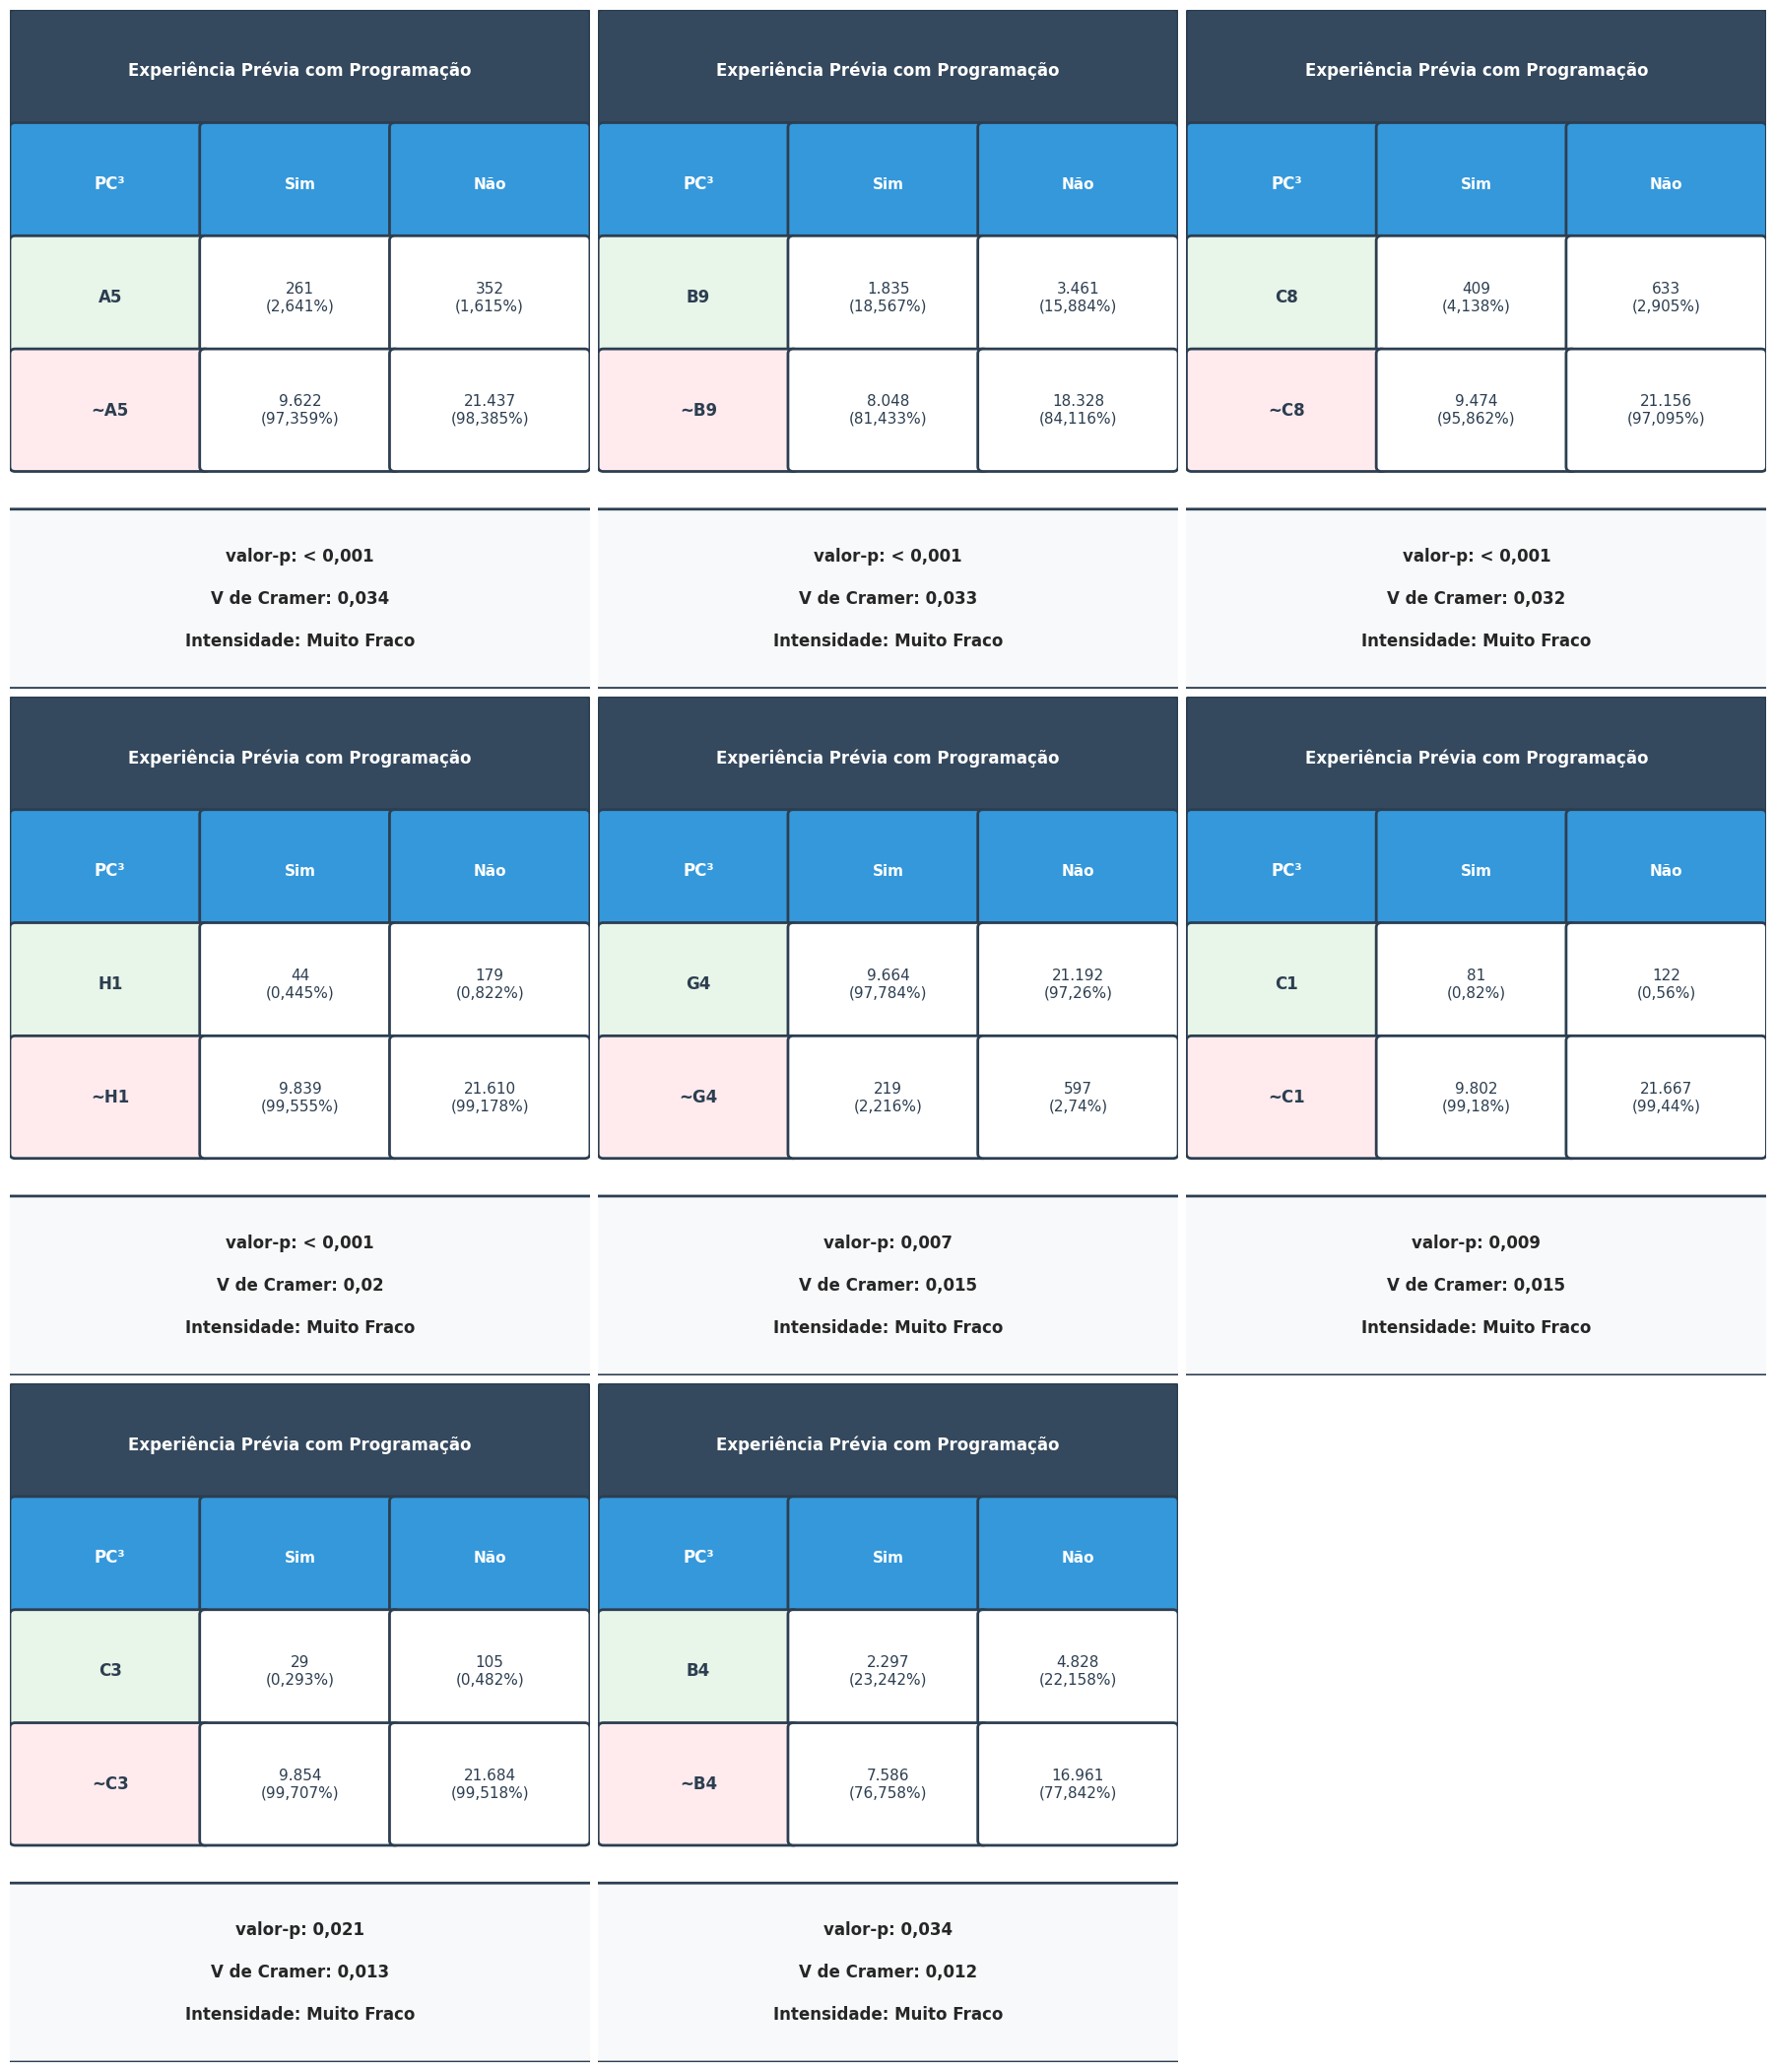

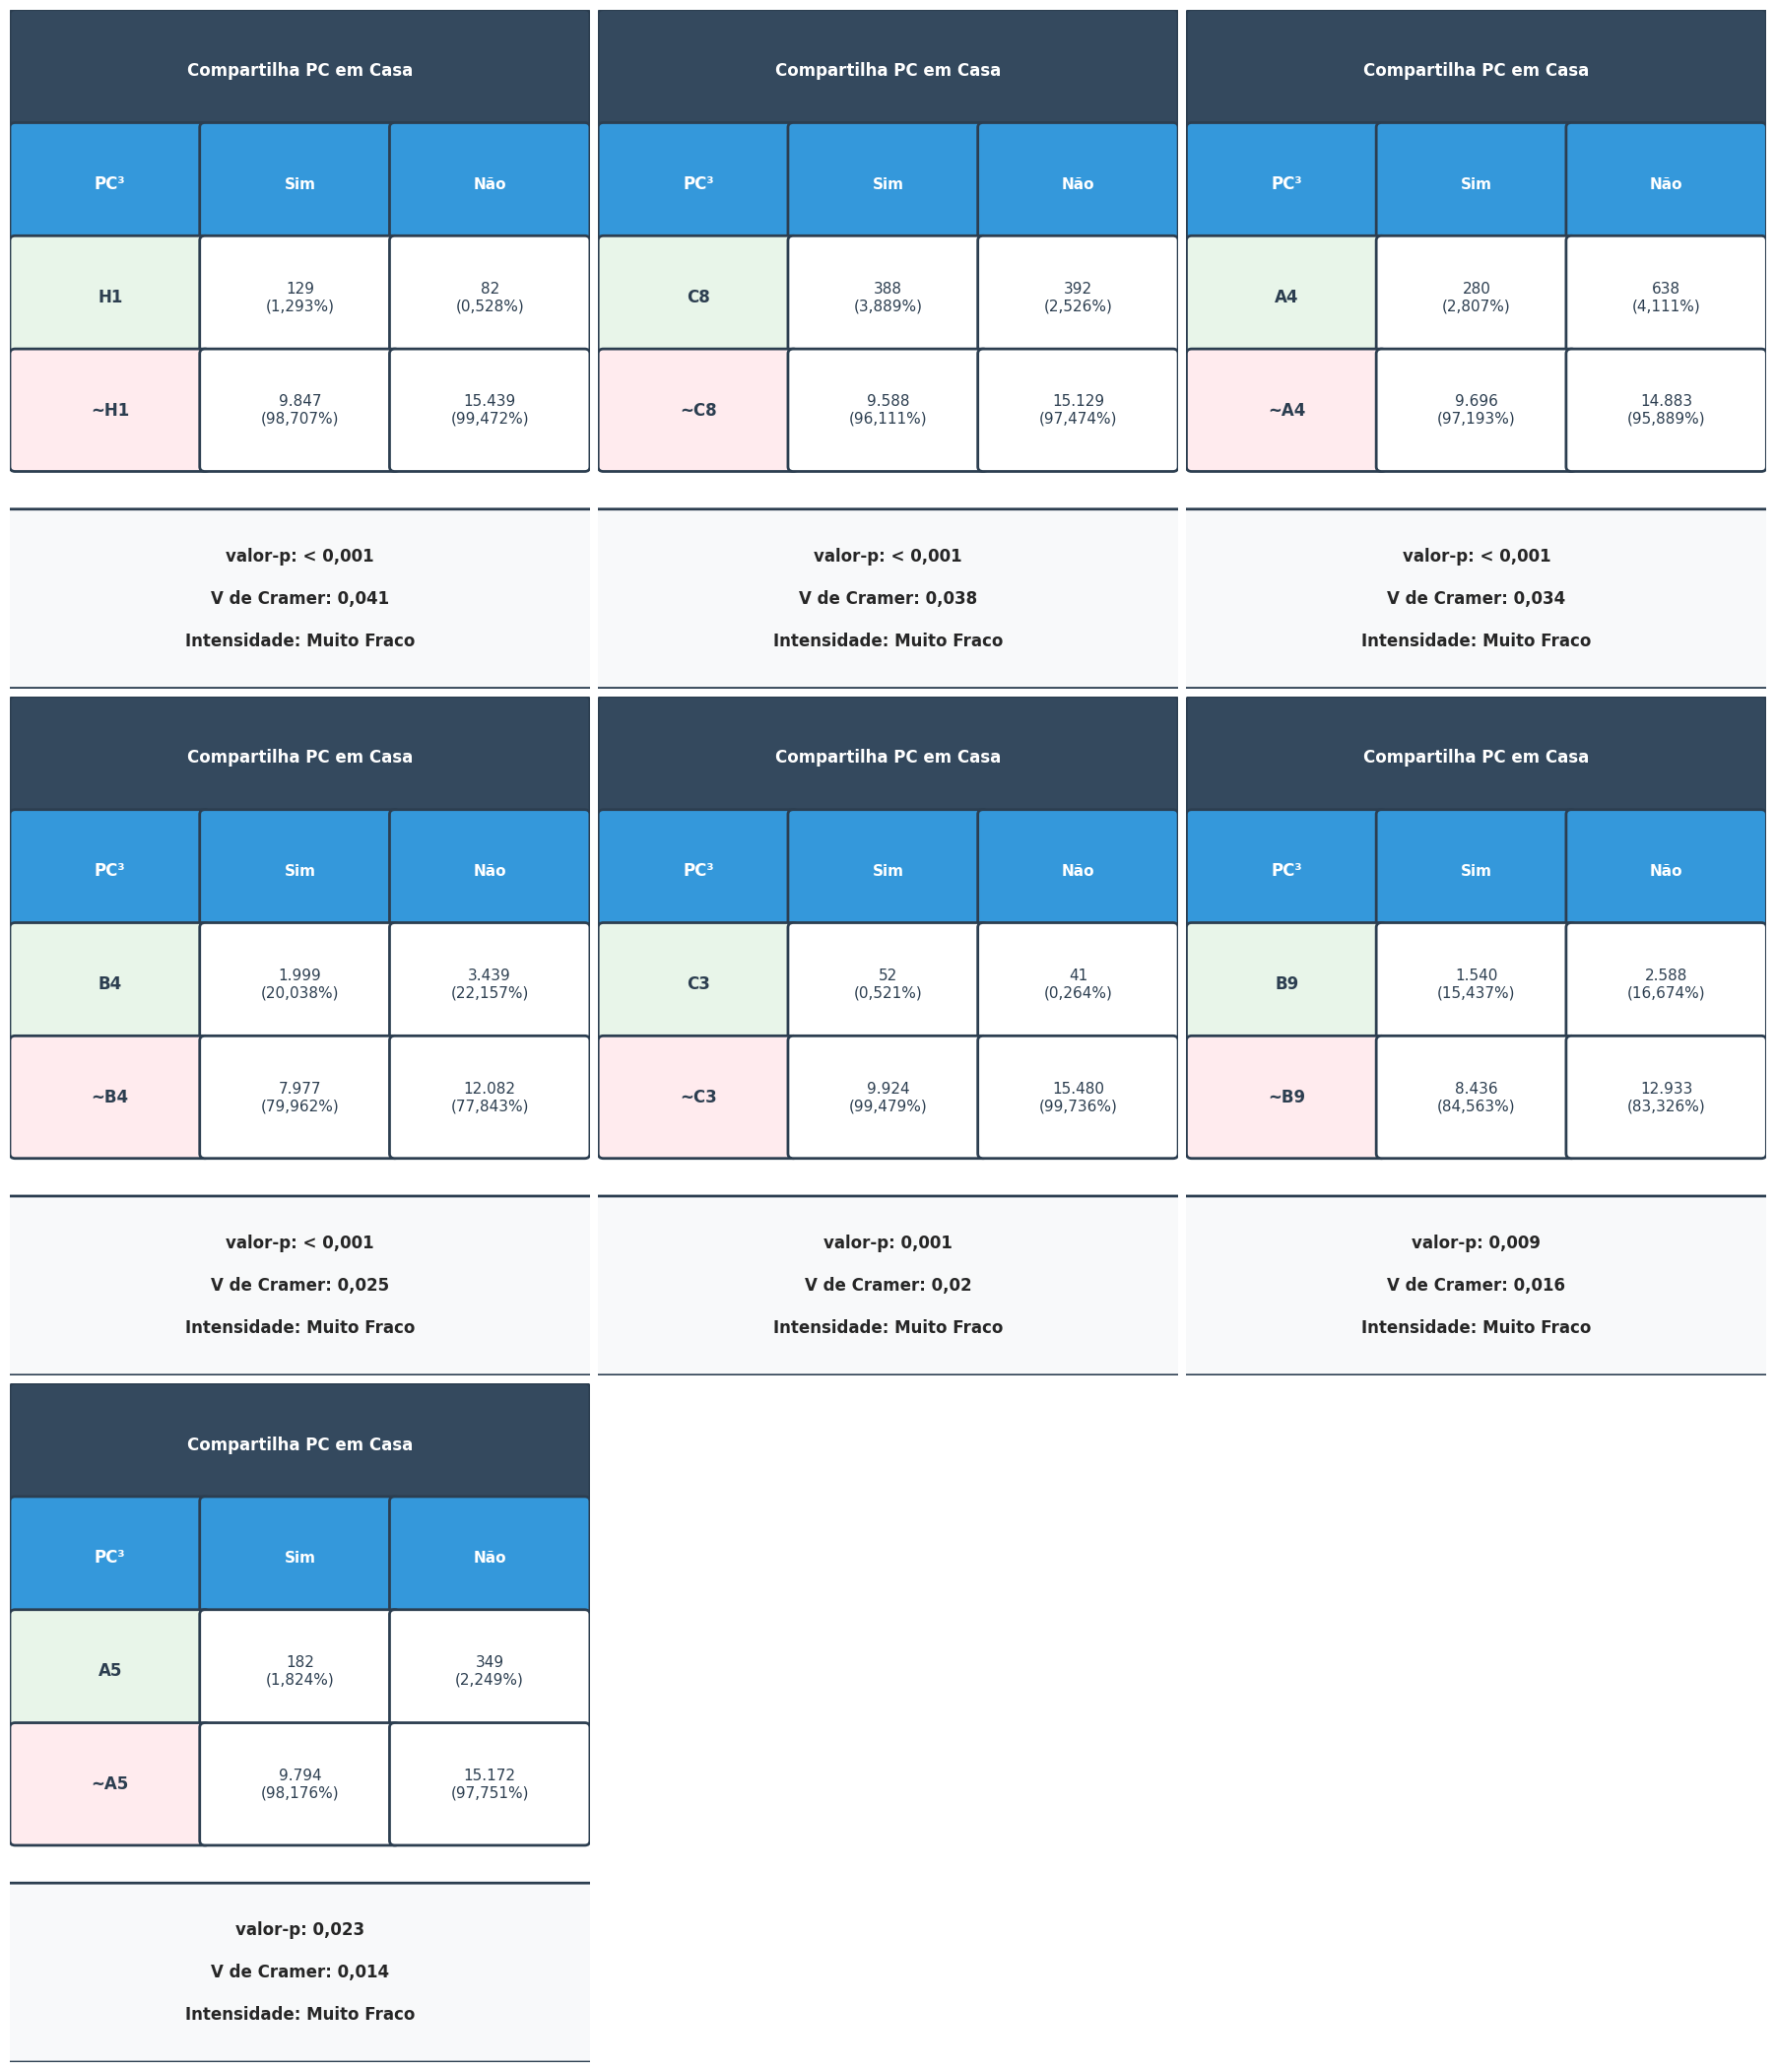

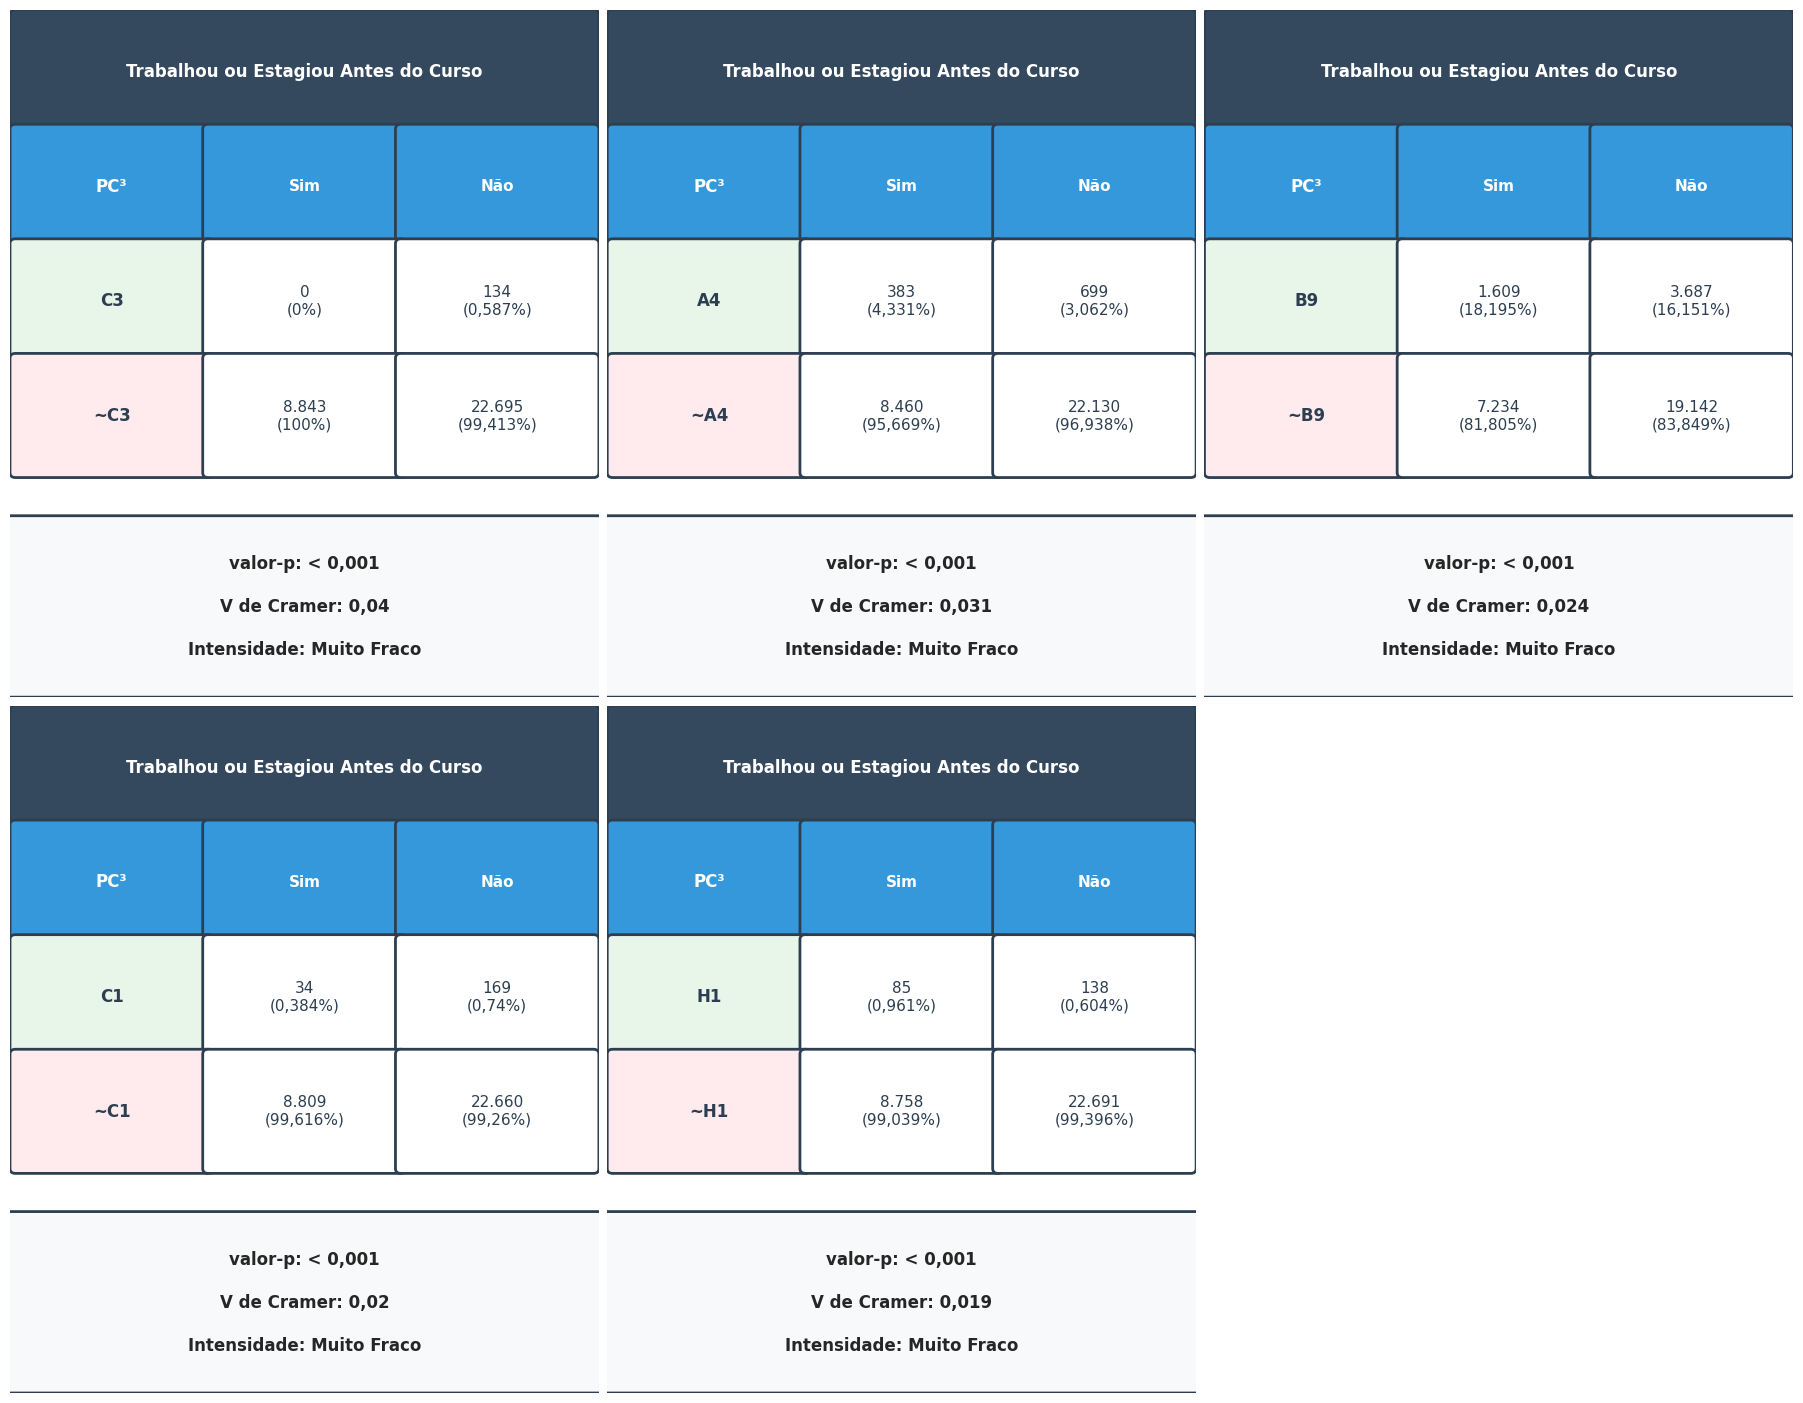

💾 Salvo: contingencia_experiência_prévia_com_programação.png
💾 Salvo: contingencia_compartilha_pc_em_casa.png
💾 Salvo: contingencia_trabalhou_ou_estagiou_antes_do_curso.png

ANÁLISE CONCLUÍDA


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import csv
from pathlib import Path
from collections import defaultdict
from scipy.stats import chi2_contingency

MISCONCEPTIONS_PATH = "misconceptions_detailed_por_usuario.csv"
USER_DATA_PATH = Path('../Etapa_3/Processamento/UsuariosProcessamento')

PC3_MAP = {
    'A4': 'A4', 'A5': 'A5', 'B4': 'B4', 'B6': 'B6', 'B8': 'B8', 'B9': 'B9',
    'B12': 'B12', 'C1': 'C1', 'C2': 'C2', 'C3': 'C3', 'C4': 'C4', 'C8': 'C8',
    'D4': 'D4', 'E2': 'E2', 'G4': 'G4', 'G5': 'G5', 'H1': 'H1'
}

def formatar_pvalor(p_val):
    if p_val < 1e-16: return '<< 0,001'
    elif p_val < 1e-3: return '< 0,001'
    else: return f"{p_val:.3f}".replace('.', ',')

def formatar_numero(num):
    if isinstance(num, (int, np.integer)):
        return f"{num:,}".replace(',', '.')
    else:
        num_str = f"{num:.3f}"
        partes = num_str.split('.')
        parte_inteira = f"{int(partes[0]):,}".replace(',', '.')
        parte_decimal = partes[1].rstrip('0') if len(partes) > 1 else ''
        return f"{parte_inteira},{parte_decimal}" if parte_decimal else parte_inteira

def extrair_campo_user_data(conteudo, campo_busca):
    """Extrai um campo específico do arquivo user.data"""
    linhas = conteudo.split('\n')
    for linha in linhas:
        linha = linha.strip()
        if linha.startswith('----'):
            linha_limpa = linha.replace('----', '').strip()
            if linha_limpa.lower().startswith(campo_busca.lower() + ':'):
                if ':' in linha_limpa:
                    _, valor = linha_limpa.split(':', 1)
                    valor = valor.strip()
                    return valor if valor else None
    return None

def carregar_dados_usuarios():
    """Carrega dados dos usuários a partir dos arquivos user.data"""
    usuarios_catalogados = set()
    colunas_padrao = ['usuario', 'school_type', 'previous_experience', 'share_pc', 'worked_interned']
    
    try:
        with open(MISCONCEPTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for linha in reader:
                if 'usuario' in linha and linha['usuario']:
                    usuarios_catalogados.add(linha['usuario'])
    except FileNotFoundError:
        print(f"⚠️  Arquivo {MISCONCEPTIONS_PATH} não encontrado!")
        return pd.DataFrame(columns=colunas_padrao)
    
    if not USER_DATA_PATH.exists():
        print(f"⚠️  Diretório {USER_DATA_PATH} não existe!")
        return pd.DataFrame(columns=colunas_padrao)
    
    dados_usuarios = []
    for usuario in usuarios_catalogados:
        pasta_usuario = USER_DATA_PATH / usuario
        arquivo_user_data = pasta_usuario / 'user.data'
        
        if arquivo_user_data.exists():
            try:
                with open(arquivo_user_data, 'r', encoding='utf-8') as f:
                    conteudo = f.read()
                    
                school_type = extrair_campo_user_data(conteudo, "school type")
                previous_exp = extrair_campo_user_data(conteudo, "previous experience of any computer language")
                share_pc = extrair_campo_user_data(conteudo, "share this PC with other people at home")
                worked_interned = extrair_campo_user_data(conteudo, "worked or interned before the degree")
                
                if previous_exp and previous_exp.lower().startswith('yes'): 
                    previous_exp = 'yes'
                    
                dados_usuarios.append({
                    'usuario': usuario, 
                    'school_type': school_type, 
                    'previous_experience': previous_exp, 
                    'share_pc': share_pc, 
                    'worked_interned': worked_interned
                })
            except Exception as e:
                pass
    
    if not dados_usuarios:
        print(f"⚠️  Nenhum dado de usuário foi coletado!")
        return pd.DataFrame(columns=colunas_padrao)
    
    return pd.DataFrame(dados_usuarios)

def load_and_process_data():
    """Carrega e processa os dados de misconceptions e usuários"""
    df_misc = pd.read_csv(MISCONCEPTIONS_PATH)
    df_misc['usuario'] = df_misc['usuario'].astype(str)
    
    # Criar colunas para cada misconception
    for mi in PC3_MAP.values(): 
        df_misc[f'tem_{mi}'] = False
    
    # Contar misconceptions por usuário
    counts = defaultdict(lambda: defaultdict(int))
    for _, row in df_misc.iterrows():
        misc_str = str(row['misconceptions_detectados'])
        if misc_str != 'nan':
            for mi in [m.strip() for m in misc_str.split(',')]:
                if mi in PC3_MAP.values(): 
                    counts[mi][str(row['usuario'])] += 1
    
    # Marcar presença de misconceptions
    for mi in PC3_MAP.values():
        col = f'tem_{mi}'
        for u, count in counts[mi].items():
            df_misc.loc[df_misc['usuario'] == u, col] = count > 0
    
    # Carregar dados dos usuários e fazer merge
    df_usuarios = carregar_dados_usuarios()
    
    return df_misc.merge(df_usuarios, on='usuario', how='left')

def calcular_estatisticas_contingencia(crosstab):
    """Calcula qui-quadrado, p-valor e V de Cramér"""
    try:
        chi2, p_val, dof, exp = chi2_contingency(crosstab)
        n = crosstab.sum().sum()
        min_dim = min(crosstab.shape) - 1
        v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        return chi2, p_val, v
    except: 
        return None, None, None

def get_top_misconceptions(df, n=10):
    """Retorna os top N misconceptions mais frequentes"""
    freqs = {mi: df[f'tem_{mi}'].sum() for mi in PC3_MAP.values() if f'tem_{mi}' in df.columns}
    return [mi for mi, f in sorted(freqs.items(), key=lambda x: x[1], reverse=True)[:n]]

def desenhar_tabela_no_eixo(ax, mi_name, fator_nome, categorias, crosstab, p_value, cramers_v):
    """Desenha uma tabela de contingência em um eixo matplotlib"""
    TRADUCAO_CATEGORIAS = {
        'yes': 'Sim', 'no': 'Não', 'public school': 'Pública',
        'private school': 'Privada', 'technical school': 'Técnica'
    }
    
    categorias_pt = [TRADUCAO_CATEGORIAS.get(cat, cat) for cat in categorias]
    n_categorias = len(categorias_pt)
    
    cor_header, cor_border, cor_texto, cor_destaque = '#34495e', '#2c3e50', '#2c3e50', '#3498db'
    
    # Coordenadas base
    table_top = 8.0
    cell_width = 1.8 if n_categorias == 2 else 1.5
    cell_height = 1.2
    start_x = 5 - (cell_width * (n_categorias + 1)) / 2
    
    # Header Fator
    largura_total = cell_width * (n_categorias + 1)
    ax.add_patch(FancyBboxPatch((start_x, table_top), largura_total, cell_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor=cor_header, linewidth=2))
    ax.text(start_x + largura_total/2, table_top + cell_height/2, fator_nome,
           ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    # Headers Colunas
    table_top2 = table_top - cell_height
    ax.add_patch(FancyBboxPatch((start_x, table_top2), cell_width, cell_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor=cor_destaque, linewidth=2))
    ax.text(start_x + cell_width/2, table_top2 + cell_height/2, 'PC³',
           ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    for i, cat_nome in enumerate(categorias_pt):
        x_cat = start_x + cell_width + i * cell_width
        ax.add_patch(FancyBboxPatch((x_cat, table_top2), cell_width, cell_height,
                                    boxstyle="round,pad=0.05", edgecolor=cor_border,
                                    facecolor=cor_destaque, linewidth=2))
        ax.text(x_cat + cell_width/2, table_top2 + cell_height/2, cat_nome,
               ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    # Linha Mi
    table_top3 = table_top2 - cell_height
    ax.add_patch(FancyBboxPatch((start_x, table_top3), cell_width, cell_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor='#e8f5e9', linewidth=2))
    ax.text(start_x + cell_width/2, table_top3 + cell_height/2, f'{mi_name}',
           ha='center', va='center', fontsize=12, fontweight='bold', color=cor_texto)
    
    for i, cat in enumerate(categorias):
        x_val = start_x + cell_width + i * cell_width
        val = crosstab.loc[cat, True] if cat in crosstab.index and True in crosstab.columns else 0
        pct = (val / crosstab.loc[cat].sum() * 100) if crosstab.loc[cat].sum() > 0 else 0
        ax.add_patch(FancyBboxPatch((x_val, table_top3), cell_width, cell_height,
                                    boxstyle="round,pad=0.05", edgecolor=cor_border,
                                    facecolor='white', linewidth=2))
        ax.text(x_val + cell_width/2, table_top3 + cell_height/2, f'{formatar_numero(val)}\n({formatar_numero(pct)}%)',
               ha='center', va='center', fontsize=11, color=cor_texto)
    
    # Linha ~Mi
    table_top4 = table_top3 - cell_height
    ax.add_patch(FancyBboxPatch((start_x, table_top4), cell_width, cell_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor='#ffebee', linewidth=2))
    ax.text(start_x + cell_width/2, table_top4 + cell_height/2, f'~{mi_name}',
           ha='center', va='center', fontsize=12, fontweight='bold', color=cor_texto)
    
    for i, cat in enumerate(categorias):
        x_val = start_x + cell_width + i * cell_width
        val = crosstab.loc[cat, False] if cat in crosstab.index and False in crosstab.columns else 0
        pct = (val / crosstab.loc[cat].sum() * 100) if crosstab.loc[cat].sum() > 0 else 0
        ax.add_patch(FancyBboxPatch((x_val, table_top4), cell_width, cell_height,
                                    boxstyle="round,pad=0.05", edgecolor=cor_border,
                                    facecolor='white', linewidth=2))
        ax.text(x_val + cell_width/2, table_top4 + cell_height/2, f'{formatar_numero(val)}\n({formatar_numero(pct)}%)',
               ha='center', va='center', fontsize=11, color=cor_texto)
    
    # Estatísticas
    stats_width, stats_height = 6.0, 1.8
    stats_x = 5 - stats_width/2
    stats_y = table_top4 - 0.5 - stats_height
    
    ax.add_patch(FancyBboxPatch((stats_x, stats_y), stats_width, stats_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor='#f8f9fa', linewidth=2))
    
    p_str = formatar_pvalor(p_value)
    v_str = formatar_numero(cramers_v)
    int_str = "Muito Forte" if cramers_v > 0.25 else "Forte" if cramers_v > 0.15 else "Moderado" if cramers_v > 0.10 else "Fraco" if cramers_v > 0.05 else "Muito Fraco"
    
    ax.text(5, stats_y + stats_height * 0.75, f'valor-p: {p_str}', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(5, stats_y + stats_height * 0.5, f'V de Cramer: {v_str}', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(5, stats_y + stats_height * 0.25, f'Intensidade: {int_str}', ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Ajuste dos limites para este subplot
    padding = 0.05
    ax.set_xlim(start_x - padding, start_x + largura_total + padding)
    ax.set_ylim(stats_y - padding, table_top + cell_height + padding)
    ax.axis('off')

def gerar_figuras_agrupadas(df, top_misconceptions, grupos_analise):
    """Gera figuras agrupadas por fator demográfico com múltiplos subplots"""
    TRADUCAO_FATORES = {
        'school_type': 'Tipo de Escola',
        'previous_experience': 'Experiência Prévia com Programação',
        'share_pc': 'Compartilha PC em Casa',
        'worked_interned': 'Trabalhou ou Estagiou Antes do Curso'
    }
    
    figuras_por_fator = {}
    
    for grupo in grupos_analise:
        fator_nome = TRADUCAO_FATORES.get(grupo['column'], grupo['title'])
        resultados_fator = []
        
        for mi_name in top_misconceptions:
            mi_column = f'tem_{mi_name}'
            df_valid = df[df[grupo['column']].notna()].copy()
            if len(df_valid) > 0 and mi_column in df_valid.columns:
                crosstab = pd.crosstab(df_valid[grupo['column']], df_valid[mi_column])
                if True in crosstab.columns and False in crosstab.columns:
                    labels_presentes = [label for label in grupo['labels'] if label in crosstab.index]
                    if len(labels_presentes) >= 2:
                        crosstab_filtrado = crosstab.loc[labels_presentes]
                        chi2, p_value, cramers_v = calcular_estatisticas_contingencia(crosstab_filtrado)
                        if cramers_v is not None and p_value is not None and p_value < 0.05:
                            resultados_fator.append({
                                'mi': mi_name, 'categorias': labels_presentes, 
                                'crosstab': crosstab_filtrado, 'p_value': p_value, 'cramers_v': cramers_v
                            })
        
        if resultados_fator:
            # Ordenar por V de Cramer
            resultados_fator = sorted(resultados_fator, key=lambda x: x['cramers_v'], reverse=True)
            
            # Criar figura com subplots lado a lado
            n_tabelas = len(resultados_fator)
            # Definir layout (máximo de 3 por linha)
            cols = min(n_tabelas, 3)
            rows = (n_tabelas + cols - 1) // cols
            
            # Ajustar tamanho da figura baseado no número de categorias e subplots
            n_cat = len(grupo['labels'])
            base_w = 6 if n_cat == 2 else 7
            base_h = 7
            
            fig, axes = plt.subplots(rows, cols, figsize=(base_w * cols, base_h * rows))
            if n_tabelas == 1: 
                axes = np.array([axes])
            axes_flat = axes.flatten()
            
            for i, res in enumerate(resultados_fator):
                desenhar_tabela_no_eixo(axes_flat[i], res['mi'], fator_nome, res['categorias'], 
                                       res['crosstab'], res['p_value'], res['cramers_v'])
            
            # Esconder eixos vazios
            for j in range(i + 1, len(axes_flat)):
                axes_flat[j].axis('off')
            
            plt.tight_layout(pad=0.5)
            figuras_por_fator[fator_nome] = fig
            
    return figuras_por_fator

if __name__ == "__main__":
    print("\n" + "="*80)
    print("ANÁLISE DE CONTINGÊNCIA - FIGURAS AGRUPADAS")
    print("="*80 + "\n")
    
    df_final = load_and_process_data()
    top_misconceptions = get_top_misconceptions(df_final, n=10)
    
    print(f"📊 Total de registros carregados: {len(df_final)}")
    print(f"👥 Usuários únicos: {df_final['usuario'].nunique()}")
    print(f"\n🔝 Top {len(top_misconceptions)} Misconceptions:")
    for mi in top_misconceptions:
        freq = df_final[f'tem_{mi}'].sum()
        print(f"   {mi}: {freq} ocorrências")
    
    grupos_analise = [
        {'column': 'school_type', 'labels': ('public school', 'private school', 'technical school'), 'title': 'Tipo de Escola'},
        {'column': 'previous_experience', 'labels': ('yes', 'no'), 'title': 'Experiência Prévia'},
        {'column': 'share_pc', 'labels': ('yes', 'no'), 'title': 'Compartilha PC'},
        {'column': 'worked_interned', 'labels': ('yes', 'no'), 'title': 'Trabalhou/Estagiou'}
    ]
    
    print("\n🔄 Gerando figuras agrupadas...")
    figuras_agrupadas = gerar_figuras_agrupadas(df_final, top_misconceptions, grupos_analise)
    
    if figuras_agrupadas:
        print(f"\n{'='*80}")
        print(f"✅ TOTAL DE FIGURAS GERADAS: {len(figuras_agrupadas)}")
        print(f"{'='*80}\n")
        
        for fator, fig in figuras_agrupadas.items():
            # Salvar com corte perfeito
            nome_arquivo = f"contingencia_{fator.replace(' ', '_').lower()}.png"
            fig.savefig(nome_arquivo, bbox_inches='tight', pad_inches=0.05, dpi=300)
            print(f"💾 Salvo: {nome_arquivo}")
            plt.show()
    else:
        print("\n⚠️  Nenhuma figura foi gerada. Verifique se os dados dos usuários estão disponíveis.")
    
    print("\n" + "="*80)
    print("ANÁLISE CONCLUÍDA")
    print("="*80)

# Etapa 7

In [9]:
"""
COMBINADOR DE MÉTRICAS - BASEADO EM MISCONCEPTIONS
Usa misconceptions_detailed_por_usuario.csv como fonte principal

MODIFICAÇÕES:
1. nota_aluno é calculada mas NÃO incluída na saída
2. dificuldade é calculada da MESMA forma (do arquivo .log individual)
3. OTIMIZADO: Acesso a disco reduzido, Regex pré-compilado e GroupBy utilizado.
"""

import pandas as pd
import numpy as np
import os
import re
import glob

# ============================================================================
# CONFIGURAÇÕES
# ============================================================================

MISCONCEPTIONS_PATH = 'misconceptions_detailed_por_usuario.csv'
EXECUTIONS_PATH = '../Etapa_4/codebench-analytics-full/output/metrics/executions_by_student.csv'
ACTIONS_PATH = '../Etapa_4/codebench-analytics-full/output/metrics/actions_by_student.csv'
USUARIOS_PATH = '../Etapa_3/Processamento/UsuariosProcessamento'

OUTPUT_PATH = 'metricas_individuais_por_estudante.csv'

# OTIMIZAÇÃO: Pré-compilar o Regex UMA ÚNICA VEZ fora da função
PADRAO_NOTA = re.compile(r'--\s*GRADE:\s*(\d+)\s*%', re.MULTILINE)

# ============================================================================
# FUNÇÃO: EXTRAIR DIFICULDADE (OTIMIZADA)
# ============================================================================

def obter_nota_arquivo(arquivo_path: str) -> int:
    """Extrai a nota do arquivo .log (retorna percentual 0-100)"""
    try:
        with open(arquivo_path, 'r', encoding='utf-8') as file:
            conteudo = file.read()
            # Usar o Regex pré-compilado (muito mais rápido)
            notas = PADRAO_NOTA.findall(conteudo)
            if notas:
                # Retornar a ÚLTIMA nota encontrada (submissão final)
                return int(notas[-1])
    except Exception:
        pass
    return 0


def extrair_dificuldades_para_alunos_questoes(caminho_usuarios, df_misconceptions):
    """
    Extrai dificuldade (nota do .log) APENAS para os pares (aluno, questão) que existem em misconceptions
    Versão Otimizada: Usa operações em lote e busca em memória para reduzir uso do disco (I/O).
    """
    
    print("\n📝 Extraindo dificuldades para pares (aluno, questão) em misconceptions...")
    
    if not os.path.exists(caminho_usuarios):
        print(f"❌ Diretório não encontrado: {caminho_usuarios}")
        return None, None
    
    # Extrair pares únicos (aluno, questão) de misconceptions
    pares_aluno_questao = df_misconceptions[['usuario', 'question']].drop_duplicates()
    print(f"   • Pares únicos (aluno, questão): {len(pares_aluno_questao)}")
    
    dificuldades_individuais = []
    arquivos_lidos = {}  # {(usuario, questao): caminho}
    
    arquivos_encontrados = 0
    arquivos_nao_encontrados = 0
    dificuldades_extraidas = 0
    
    # OTIMIZAÇÃO: Agrupar por aluno para varrer o diretório apenas uma vez por pessoa
    questoes_por_aluno = pares_aluno_questao.groupby('usuario')['question'].apply(list).to_dict()

    for aluno, questoes in questoes_por_aluno.items():
        aluno_str = str(aluno)
        caminho_pasta_usuario = os.path.join(caminho_usuarios, aluno_str)
        
        if not os.path.isdir(caminho_pasta_usuario):
            arquivos_nao_encontrados += len(questoes)
            continue
            
        # Procurar pasta 'executions' ou 'grades'
        caminho_alvo = os.path.join(caminho_pasta_usuario, 'executions')
        if not os.path.isdir(caminho_alvo):
            caminho_alvo = os.path.join(caminho_pasta_usuario, 'grades')
            if not os.path.isdir(caminho_alvo):
                arquivos_nao_encontrados += len(questoes)
                continue

        # OTIMIZAÇÃO: Ler o diretório APENAS UMA VEZ por aluno e guardar na memória
        try:
            arquivos_na_pasta = set(os.listdir(caminho_alvo))
        except Exception:
            arquivos_nao_encontrados += len(questoes)
            continue

        # Iterar apenas nas questões deste aluno
        for questao in questoes:
            questao_str = str(questao)
            caminho_arquivo_log = None
            
            # OTIMIZAÇÃO: Busca na memória (set intersection) é instantânea
            possiveis_exatos = {f'{questao_str}.log', f'execution_{questao_str}.log', f'{aluno_str}_{questao_str}.log'}
            match_exato = arquivos_na_pasta.intersection(possiveis_exatos)
            
            if match_exato:
                caminho_arquivo_log = os.path.join(caminho_alvo, list(match_exato)[0])
            else:
                # Busca pelo sufixo *_QUESTAO.log na memória
                sufixo_1 = f'_{questao_str}.log'
                for arq in arquivos_na_pasta:
                    if arq.endswith(sufixo_1):
                        caminho_arquivo_log = os.path.join(caminho_alvo, arq)
                        break
            
            if caminho_arquivo_log:
                nota_percentual = obter_nota_arquivo(caminho_arquivo_log)
                arquivos_lidos[(aluno_str, questao)] = caminho_arquivo_log
                
                dificuldades_individuais.append({
                    'usuario': aluno_str,
                    'question': questao,
                    'dificuldade': nota_percentual
                })
                
                arquivos_encontrados += 1
                if nota_percentual > 0:
                    dificuldades_extraidas += 1
            else:
                arquivos_nao_encontrados += 1
    
    print(f"\n✅ Resultado da extração:")
    print(f"   • Arquivos .log encontrados: {arquivos_encontrados}")
    print(f"   • Arquivos .log NÃO encontrados: {arquivos_nao_encontrados}")
    print(f"   • Dificuldades extraídas (>0): {dificuldades_extraidas}")
    print(f"   • Total de registros processados: {len(dificuldades_individuais)}")
    
    if (arquivos_encontrados + arquivos_nao_encontrados) > 0:
        taxa = arquivos_encontrados / (arquivos_encontrados + arquivos_nao_encontrados) * 100
        print(f"   • Taxa de sucesso: {taxa:.1f}%")
    
    df_dificuldades_individuais = pd.DataFrame(dificuldades_individuais)
    
    return df_dificuldades_individuais, arquivos_lidos


def normalizar_id_usuario(df, coluna='usuario'):
    """Normaliza IDs de usuário"""
    df = df.copy()
    df[coluna] = df[coluna].astype(str)
    df[coluna] = df[coluna].str.replace(r'^(user_|student_|aluno_)', '', regex=True)
    df[coluna] = df[coluna].str.strip().str.lower()
    return df


# ============================================================================
# FUNÇÃO PRINCIPAL
# ============================================================================

def combinar_metricas():
    """Combina métricas baseado em misconceptions"""
    
    print("\n" + "="*80)
    print("COMBINADOR DE MÉTRICAS - BASEADO EM MISCONCEPTIONS")
    print("="*80)
    print("\n⚠️  MODIFICAÇÕES:")
    print("   1. nota_aluno NÃO será incluída na saída")
    print("   2. dificuldade = valor do arquivo .log (individual)")
    print("="*80)
    
    # ========================================================================
    # PASSO 1: Carregar MISCONCEPTIONS (fonte principal)
    # ========================================================================
    
    print("\n📂 Carregando misconceptions (fonte principal)...")
    
    try:
        df_misconceptions = pd.read_csv(MISCONCEPTIONS_PATH)
        print(f"✅ Misconceptions: {len(df_misconceptions)} registros")
        
        # Normalizar IDs
        df_misconceptions = normalizar_id_usuario(df_misconceptions, 'usuario')
        
        # Extrair listas de alunos e questões elegíveis
        alunos_elegiveis = sorted(df_misconceptions['usuario'].unique())
        questoes_elegiveis = sorted(df_misconceptions['question'].unique())
        
        print(f"\n📊 ALUNOS E QUESTÕES ELEGÍVEIS:")
        print(f"   • Total de alunos únicos: {len(alunos_elegiveis)}")
        print(f"   • Total de questões únicas: {len(questoes_elegiveis)}")
        
        print(f"\n📝 Primeiros 20 alunos elegíveis:")
        print(f"   {', '.join(map(str, alunos_elegiveis[:20]))}")
        
        print(f"\n📝 Primeiras 20 questões elegíveis:")
        print(f"   {', '.join(map(str, questoes_elegiveis[:20]))}")
        
    except Exception as e:
        print(f"❌ Erro ao carregar misconceptions: {e}")
        return None
    
    # ========================================================================
    # PASSO 2: FILTRAR Executions pelos pares (student, question) de misconceptions
    # ========================================================================
    
    print("\n📂 PASSO 2: Filtrando Executions...")
    
    try:
        df_executions = pd.read_csv(EXECUTIONS_PATH)
        df_executions = df_executions.rename(columns={'student': 'usuario'})
        df_executions = normalizar_id_usuario(df_executions)
        print(f"✅ Executions lido: {len(df_executions)} registros")
        
        # Criar lista de pares válidos (usuario, question) de misconceptions
        pares_validos = df_misconceptions[['usuario', 'question']].drop_duplicates()
        print(f"   • Pares válidos em misconceptions: {len(pares_validos)}")
        
        # FILTRAR: manter APENAS registros cujo par (usuario, question) existe em misconceptions
        df_executions_filtrado = pares_validos.merge(
            df_executions,
            on=['usuario', 'question'],
            how='inner'
        )
        
        registros_removidos = len(df_executions) - len(df_executions_filtrado)
        print(f"   • Registros MANTIDOS: {len(df_executions_filtrado)}")
        print(f"   • Registros REMOVIDOS: {registros_removidos}")
        
        df_executions = df_executions_filtrado
        
    except Exception as e:
        print(f"❌ Erro ao carregar executions: {e}")
        return None
    
    # ========================================================================
    # PASSO 3: FILTRAR Actions pelos pares (student, question) de misconceptions
    # ========================================================================
    
    print("\n📂 PASSO 3: Filtrando Actions...")
    
    try:
        df_actions = pd.read_csv(ACTIONS_PATH)
        df_actions = df_actions.rename(columns={'student': 'usuario'})
        df_actions = normalizar_id_usuario(df_actions)
        print(f"✅ Actions lido: {len(df_actions)} registros")
        
        # FILTRAR: manter APENAS registros cujo par (usuario, question) existe em misconceptions
        df_actions_filtrado = pares_validos.merge(
            df_actions,
            on=['usuario', 'question'],
            how='inner'
        )
        
        registros_removidos = len(df_actions) - len(df_actions_filtrado)
        print(f"   • Registros MANTIDOS: {len(df_actions_filtrado)}")
        print(f"   • Registros REMOVIDOS: {registros_removidos}")
        
        df_actions = df_actions_filtrado
        
    except Exception as e:
        print(f"❌ Erro ao carregar actions: {e}")
        return None
    
    # ========================================================================
    # PASSO 4: Extrair dificuldades para os pares (aluno, questão) válidos
    # ========================================================================
    
    print("\n📂 PASSO 4: Extraindo dificuldades (do .log)...")
    
    df_dificuldades, arquivos_lidos = extrair_dificuldades_para_alunos_questoes(
        USUARIOS_PATH, 
        df_misconceptions
    )
    
    if df_dificuldades is None:
        print("\n❌ ERRO: Não foi possível extrair dificuldades!")
        return None
    
    # ========================================================================
    # PASSO 5: Combinar tudo - Usar misconceptions como BASE
    # ========================================================================
    
    print("\n🔗 PASSO 5: Combinando métricas...")
    
    # Começar com os pares de misconceptions
    df_combined = df_misconceptions.copy()
    print(f"   • Base (misconceptions): {len(df_combined)} registros")
    
    # Adicionar executions (left join)
    df_combined = df_combined.merge(
        df_executions,
        on=['usuario', 'question'],
        how='left'
    )
    print(f"   • Após adicionar executions: {len(df_combined)} registros")
    
    # Adicionar actions (left join)
    df_combined = df_combined.merge(
        df_actions,
        on=['usuario', 'question'],
        how='left',
        suffixes=('_exec', '_action')
    )
    print(f"   • Após adicionar actions: {len(df_combined)} registros")
    
    # Resolver is_correct duplicado
    if 'is_correct_exec' in df_combined.columns and 'is_correct_action' in df_combined.columns:
        df_combined['is_correct'] = df_combined['is_correct_exec'].fillna(df_combined['is_correct_action'])
        df_combined = df_combined.drop(columns=['is_correct_exec', 'is_correct_action'])
    
    # ========================================================================
    # PASSO 6: Adicionar dificuldades individuais
    # ========================================================================
    
    print("\n🔗 PASSO 6: Adicionando dificuldades individuais...")
    
    # Adicionar dificuldades
    df_combined = df_combined.merge(
        df_dificuldades,
        on=['usuario', 'question'],
        how='left'
    )
    
    dificuldades_validas = df_combined['dificuldade'].notna().sum()
    pct = (dificuldades_validas / len(df_combined)) * 100 if len(df_combined) > 0 else 0
    print(f"✅ Dificuldades individuais: {dificuldades_validas} ({pct:.1f}%)")
    
    # ========================================================================
    # PASSO 7: Criar DataFrame Final (SEM nota_aluno)
    # ========================================================================
    
    print("\n📊 Criando DataFrame final...")
    print(f"   • Total de registros: {len(df_combined)} (mesmo que misconceptions!)")
    
    df_final = pd.DataFrame()
    
    # Colunas de identificação
    df_final['usuario'] = df_combined['usuario'].astype(str)
    df_final['question'] = df_combined['question'].astype(int)
    
    # Métricas
    df_final['tempo_implementacao'] = df_combined['code_time']
    df_final['num_eventos'] = df_combined['num_events']
    df_final['num_eventos_del'] = df_combined['num_deletes']
    df_final['num_consultas'] = np.nan
    df_final['num_submissoes'] = df_combined['num_submissions']
    df_final['num_tests'] = df_combined['num_tests']
    df_final['num_correct'] = df_combined['is_correct'].astype(float)
    df_final['num_errors'] = df_combined['num_errors']
    df_final['num_logic_errors'] = df_combined['num_logic_errors']
    df_final['num_syntax_errors'] = df_combined['num_syntax_errors']
    df_final['qtd_alteracoes_codigo'] = df_combined['amount_of_change']
    
    # Misconceptions
    df_final['misconceptions_detectados'] = df_combined['misconceptions_detectados']
    df_final['total_misconceptions'] = df_combined['total_misconceptions']
    df_final['categorias_afetadas'] = df_combined['categorias_afetadas']
    
    # ⚠️ MUDANÇA: Apenas dificuldade (sem nota_aluno)
    df_final['dificuldade'] = df_combined['dificuldade']
    
    print(f"✅ DataFrame final criado: {len(df_final.columns)} colunas")
    print(f"   ⚠️  nota_aluno NÃO foi incluída!")
    
    # ========================================================================
    # PASSO 8: Validação
    # ========================================================================
    
    print("\n" + "="*80)
    print("VALIDAÇÃO")
    print("="*80)
    
    print(f"\n📋 Colunas do arquivo final ({len(df_final.columns)}):")
    for i, col in enumerate(df_final.columns):
        print(f"   {i+1:2d}. {col}")
    
    print(f"\n📊 Estatísticas:")
    print(f"   • Total de registros: {len(df_final)}")
    print(f"   • Alunos únicos: {df_final['usuario'].nunique()}")
    print(f"   • Questões únicas: {df_final['question'].nunique()}")
    
    print(f"\n📊 Dificuldade:")
    print(f"   • Válidos: {df_final['dificuldade'].notna().sum()}")
    print(f"   • NaN: {df_final['dificuldade'].isna().sum()}")
    if df_final['dificuldade'].notna().sum() > 0:
        print(f"   • Média: {df_final['dificuldade'].mean():.2f}")
        print(f"   • Mínimo: {df_final['dificuldade'].min():.2f}")
        print(f"   • Máximo: {df_final['dificuldade'].max():.2f}")
    
    # ========================================================================
    # PASSO 9: Relatório de NaN
    # ========================================================================
    
    print("\n" + "="*80)
    print("ANÁLISE DE DIFICULDADES FALTANTES")
    print("="*80)
    
    total_registros = len(df_final)
    registros_com_dificuldade = df_final['dificuldade'].notna().sum()
    registros_sem_dificuldade = df_final['dificuldade'].isna().sum()
    
    print(f"\n📊 RESUMO GERAL:")
    print(f"   • Total de registros válidos (de misconceptions): {total_registros}")
    print(f"   • Registros COM dificuldade encontrada: {registros_com_dificuldade}")
    print(f"   • Registros SEM dificuldade: {registros_sem_dificuldade}")
    print(f"   • Porcentagem de SUCESSO: {(registros_com_dificuldade/total_registros*100):.1f}%")
    print(f"   • Porcentagem de FALHA: {(registros_sem_dificuldade/total_registros*100):.1f}%")
    
    if registros_sem_dificuldade > 0:
        print(f"\n⚠️  ATENÇÃO: {registros_sem_dificuldade} registros sem dificuldade!")
        print(f"   Estes registros podem ter misconceptions detectados mas sem arquivo .log")
    else:
        print("\n✅ PERFEITO! Todos os registros têm dificuldade!")
    
    # ========================================================================
    # PASSO 10: Amostra e Salvar
    # ========================================================================
    
    print("\n" + "="*80)
    print("AMOSTRA DOS DADOS (15 primeiras linhas)")
    print("="*80)
    
    colunas_amostra = ['usuario', 'question', 'num_correct', 'dificuldade', 'total_misconceptions']
    print(df_final[colunas_amostra].head(15).to_string(index=False))
    
    print("\n" + "="*80)
    print("SALVANDO ARQUIVO")
    print("="*80)
    
    df_final.to_csv(OUTPUT_PATH, index=False)
    print(f"\n✅ Arquivo salvo: {OUTPUT_PATH}")
    print(f"📊 Dimensões: {len(df_final)} registros × {len(df_final.columns)} colunas")
    print(f"   ⚠️  nota_aluno removida, apenas dificuldade (individual do .log)")
    
    return df_final


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    df = combinar_metricas()
    
    if df is not None:
        print("\n" + "="*80)
        print("✅ PROCESSAMENTO CONCLUÍDO COM SUCESSO!")
        print("="*80)


COMBINADOR DE MÉTRICAS - BASEADO EM MISCONCEPTIONS

⚠️  MODIFICAÇÕES:
   1. nota_aluno NÃO será incluída na saída
   2. dificuldade = valor do arquivo .log (individual)

📂 Carregando misconceptions (fonte principal)...
✅ Misconceptions: 32615 registros

📊 ALUNOS E QUESTÕES ELEGÍVEIS:
   • Total de alunos únicos: 2836
   • Total de questões únicas: 829

📝 Primeiros 20 alunos elegíveis:
   1082, 1090, 1091, 1094, 1095, 1096, 1097, 1098, 1101, 1102, 1103, 1104, 1105, 1108, 1109, 1110, 1111, 1112, 1113, 1114

📝 Primeiras 20 questões elegíveis:
   1002, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036

📂 PASSO 2: Filtrando Executions...
✅ Executions lido: 39232 registros
   • Pares válidos em misconceptions: 32512
   • Registros MANTIDOS: 27983
   • Registros REMOVIDOS: 11249

📂 PASSO 3: Filtrando Actions...
✅ Actions lido: 27041 registros
   • Registros MANTIDOS: 18840
   • Registros REMOVIDOS: 8201

📂 PASSO 4: Extraindo difi